# Tony Abi Haidar - VIP 301A

# Plot Cauchy Reliability Curve

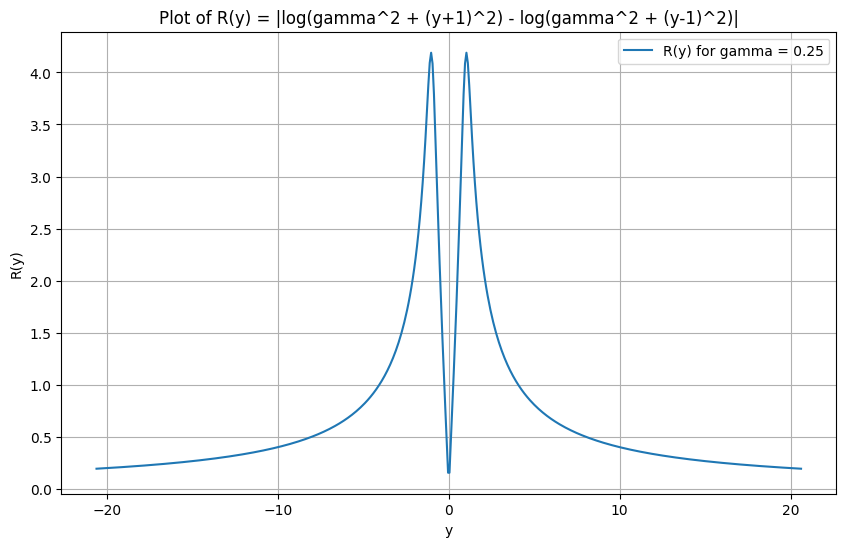

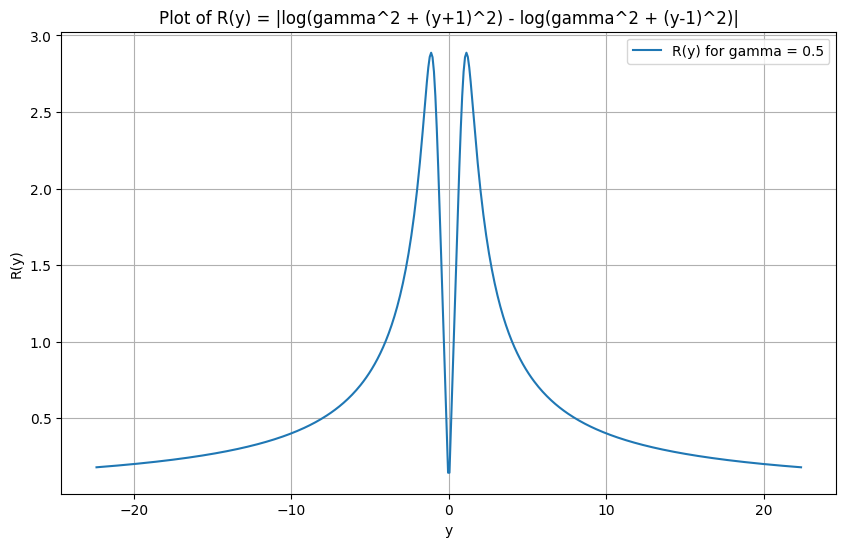

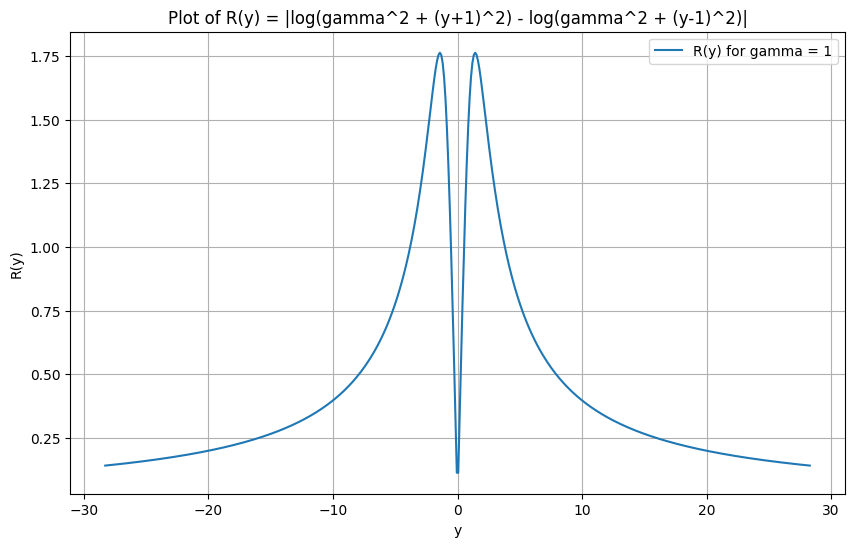

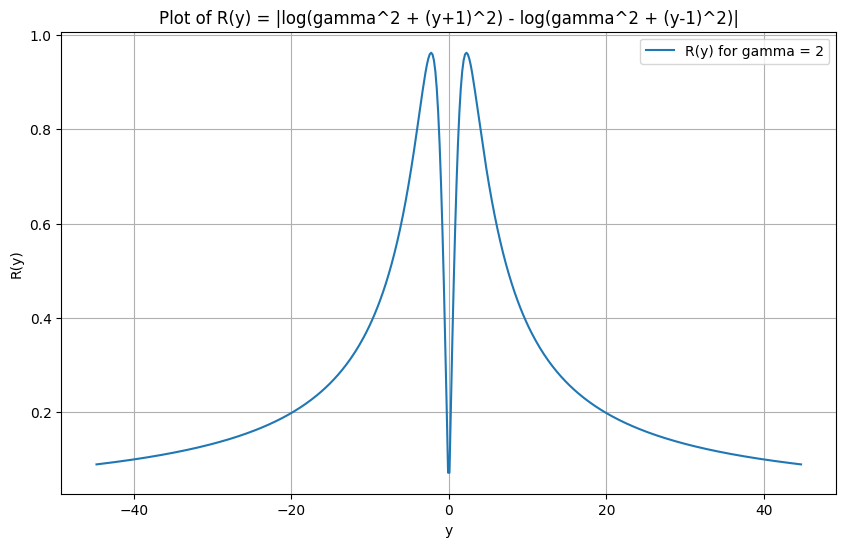

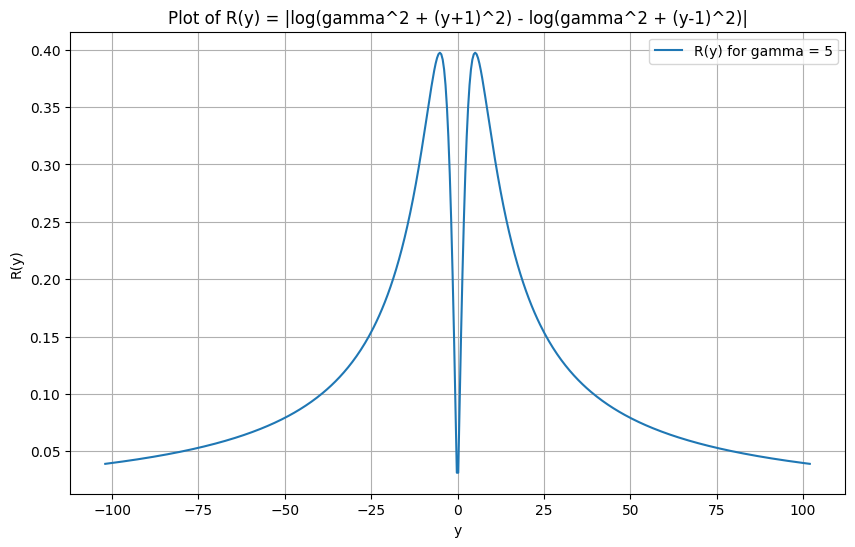

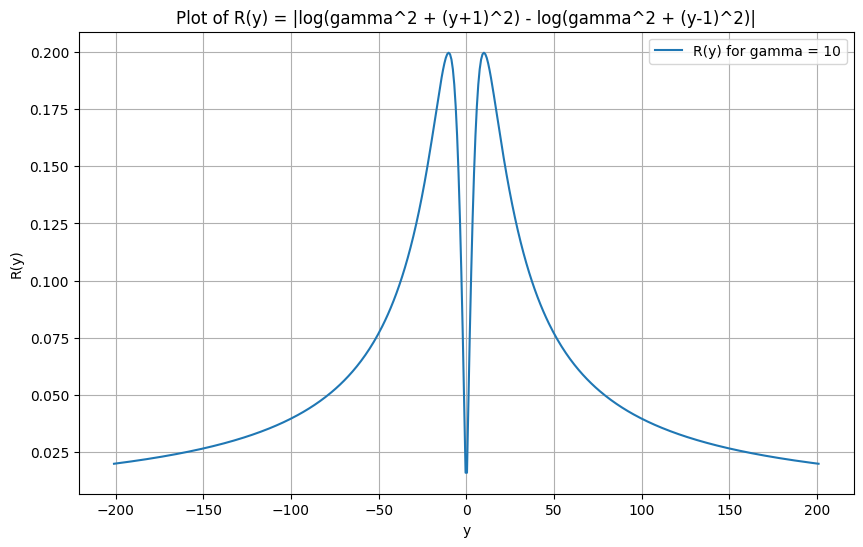

In [ ]:
# =========================================================================
# Plot of R(y) = |log(gamma^2 + (y+1)^2) - log(gamma^2 + (y-1)^2)|
#
# PURPOSE:
#   Visualises the exact Cauchy LLR reliability function R(y) = |L(y)| for
#   several gamma values.  R(y) is an even function of y that:
#     - equals 0 at y = 0 (the decision boundary: no information)
#     - rises to a peak at y = sqrt(1 + gamma^2)  (the reliability peak)
#     - decays back to 0 as |y| -> infinity  (Cauchy outliers become uninformative)
#
# PHYSICAL INTERPRETATION:
#   Under heavy-tailed Cauchy noise, a very large received value |r| could
#   equally well be explained by a huge noise outlier on either transmitted
#   symbol, so the LLR magnitude decreases in the tail.  This is unique to
#   the Cauchy distribution and motivates the non-trivial shape of R(y).
#
# PLOT RANGE:
#   y_values spans [-20*sqrt(1+gamma^2), +20*sqrt(1+gamma^2)] to show the
#   full decay on both sides of the peak, even for large gamma.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma^2 + (y+1)^2) - log(gamma^2 + (y-1)^2)|."""
    return np.abs(np.log(gamma**2 + (y + 1)**2) - np.log(gamma**2 + (y - 1)**2))



for gamma_val in [0.25, 0.5, 1, 2, 5, 10]:
    # Define parameters
    y_values = np.linspace(-20*np.sqrt(1+gamma_val*gamma_val), 20*np.sqrt(1+gamma_val*gamma_val), 500) # Range for y
    # Calculate R(y) values
    r_values = R_function(y_values, gamma_val)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(y_values, r_values, label=f'R(y) for gamma = {gamma_val}')
    plt.xlabel('y')
    plt.ylabel('R(y)')
    plt.title('Plot of R(y) = |log(gamma^2 + (y+1)^2) - log(gamma^2 + (y-1)^2)|')
    plt.grid(True)
    plt.legend()
    plt.show()

#Finding L''(y)=0

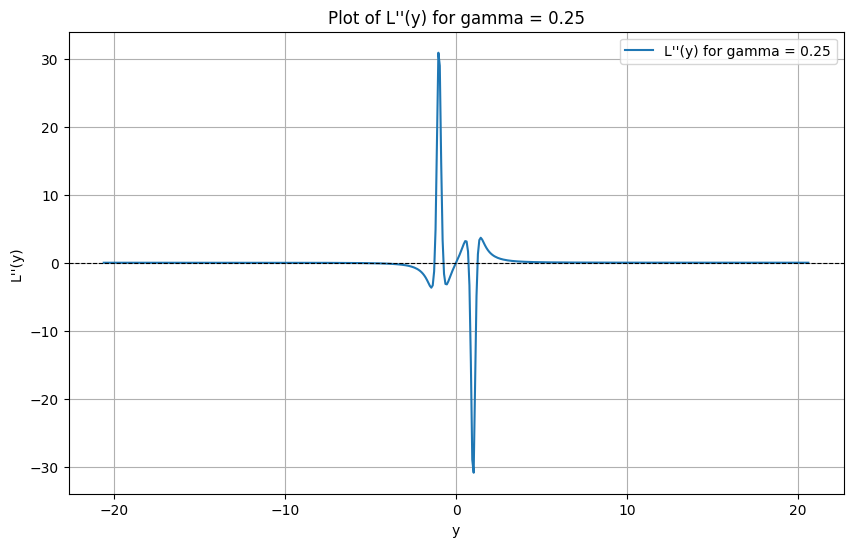

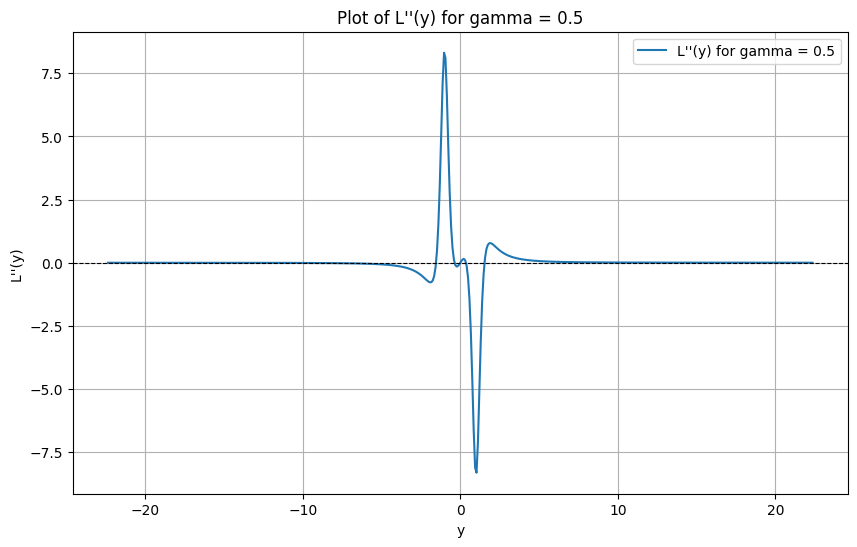

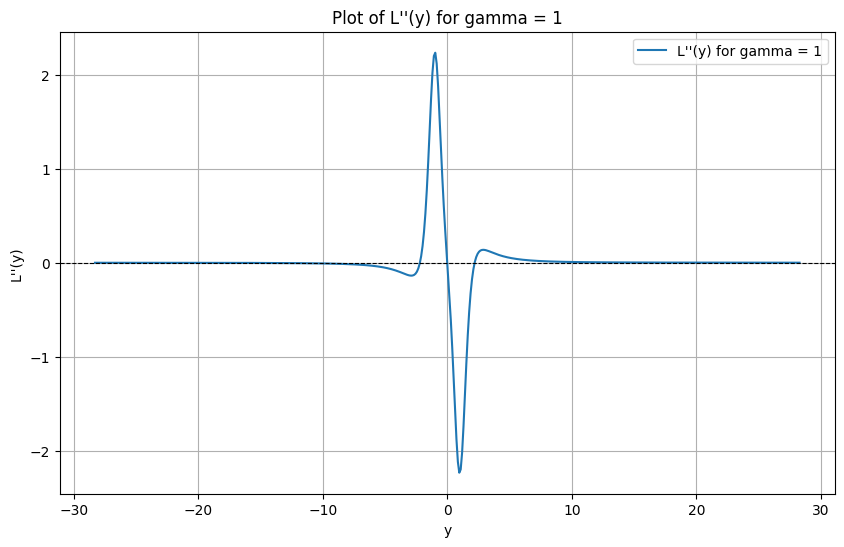

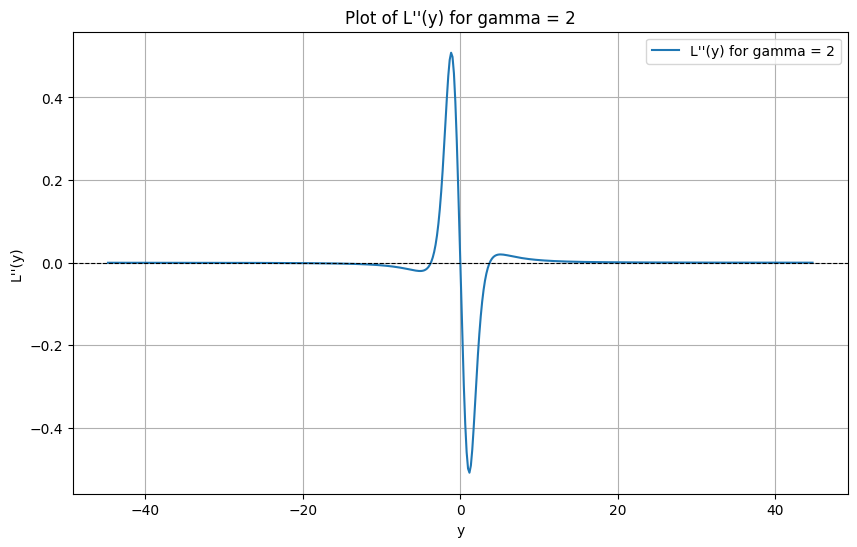

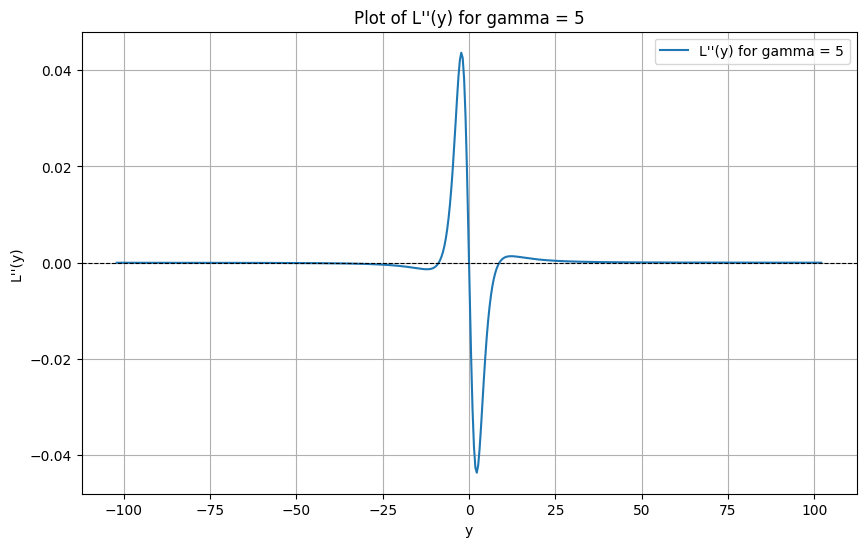

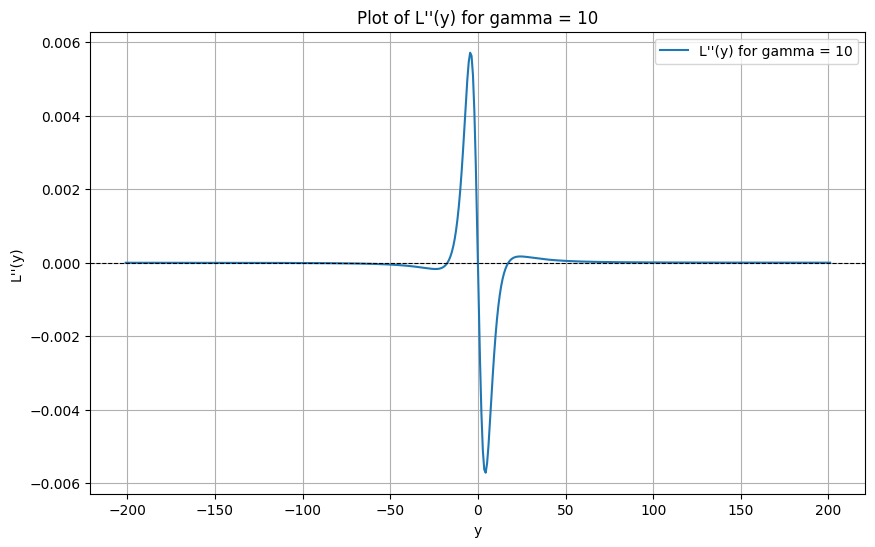

In [ ]:
# =========================================================================
# Plot of L''(y) — the Second Derivative of the Cauchy LLR
#
# PURPOSE:
#   L''(y) determines the CONCAVITY of L(y) and hence the inflection
#   points of the reliability curve R(y) = |L(y)|.  Understanding where
#   L''(y) = 0 helps analytically identify natural breakpoints for the
#   piecewise linear approximation.
#
# FORMULA:
#   L''(y) = [2*gamma^2 - 2*(y+1)^2] / (gamma^2+(y+1)^2)^2
#           -[2*gamma^2 - 2*(y-1)^2] / (gamma^2+(y-1)^2)^2
#
# INTERPRETATION:
#   L''(y) = 0 marks the inflection points of L(y), i.e. where the slope
#   of L(y) changes from increasing to decreasing or vice versa.
#   These are candidates for natural breakpoints of a piecewise linear fit.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def L_double_prime(y, gamma):
    """Calculates L''(y) based on the given formula."""
    term1_numerator = 2 * gamma**2 - 2 * (y + 1)**2
    term1_denominator = (gamma**2 + (y + 1)**2)**2
    term1 = term1_numerator / term1_denominator

    term2_numerator = 2 * gamma**2 - 2 * (y - 1)**2
    term2_denominator = (gamma**2 + (y - 1)**2)**2
    term2 = term2_numerator / term2_denominator

    return term1 - term2

# Define gamma values to plot, consistent with previous cells
for gamma_val in [0.25, 0.5, 1, 2, 5, 10]:
    # Define a range for y values
    y_values = np.linspace(-20 * np.sqrt(1 + gamma_val**2), 20 * np.sqrt(1 + gamma_val**2), 500)

    # Calculate L''(y) values
    l_double_prime_values = L_double_prime(y_values, gamma_val)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(y_values, l_double_prime_values, label=f"L''(y) for gamma = {gamma_val}")
    plt.xlabel('y')
    plt.ylabel("L''(y)")
    plt.title(f"Plot of L''(y) for gamma = {gamma_val}")
    plt.grid(True)
    plt.legend()
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.ylim(min(0, l_double_prime_values.min() * 1.1), max(0, l_double_prime_values.max() * 1.1)) # Adjust y-axis to always show 0 and some padding
    plt.show()

For gamma = 0.25:
  Root found at y = -1.256140
  Root found at y = -0.739670
  Root found at y = -0.000000
  Root found at y = 0.739670
  Root found at y = 1.256140


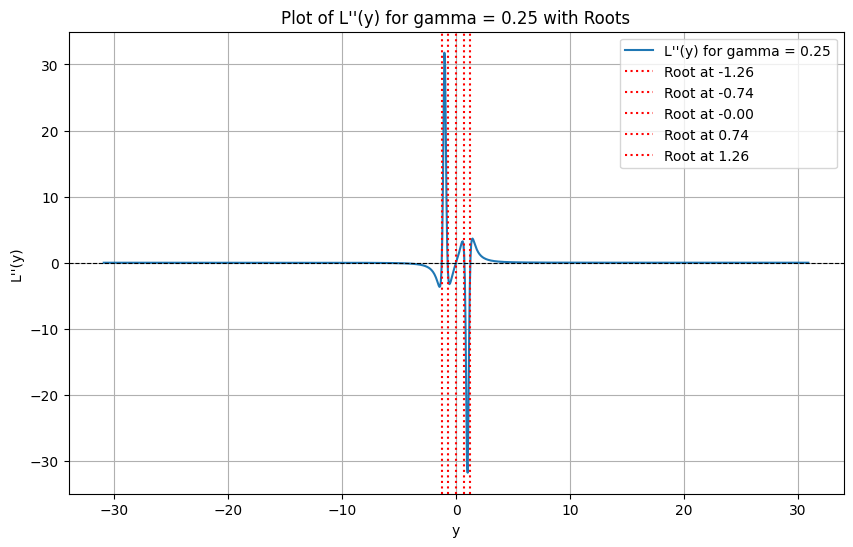

For gamma = 0.5:
  Root found at y = -1.538840
  Root found at y = -0.363270
  Root found at y = 0.000000
  Root found at y = 0.363270
  Root found at y = 1.538840


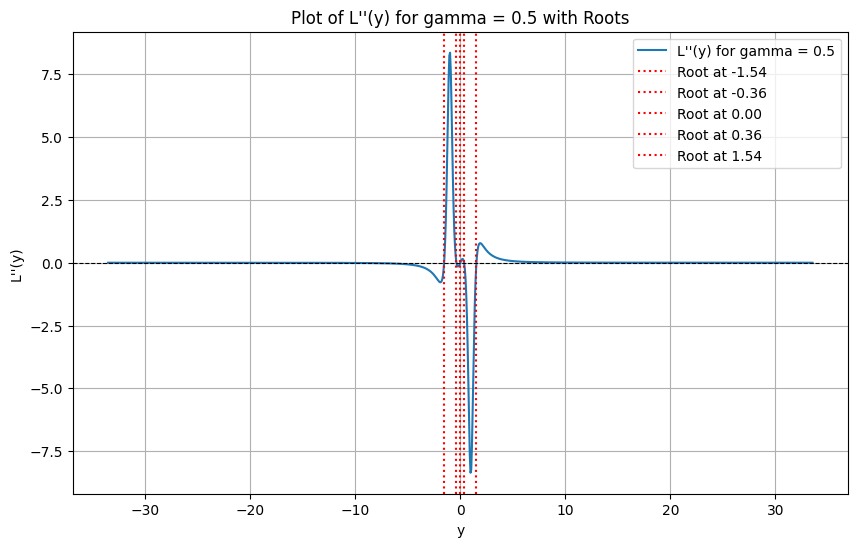

For gamma = 1:
  Root found at y = -2.197370
  Root found at y = 0.000000
  Root found at y = 2.197370


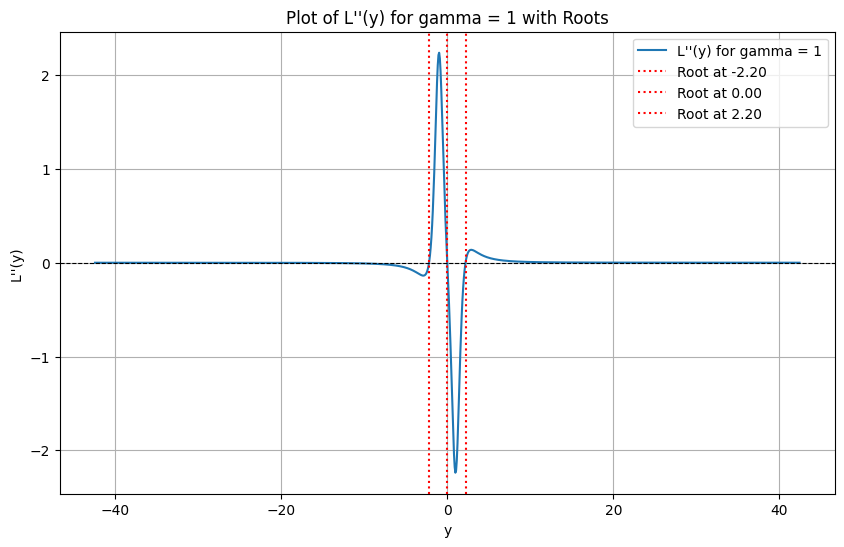

For gamma = 2:
  Root found at y = -3.734200
  Root found at y = 0.000000
  Root found at y = 3.734200


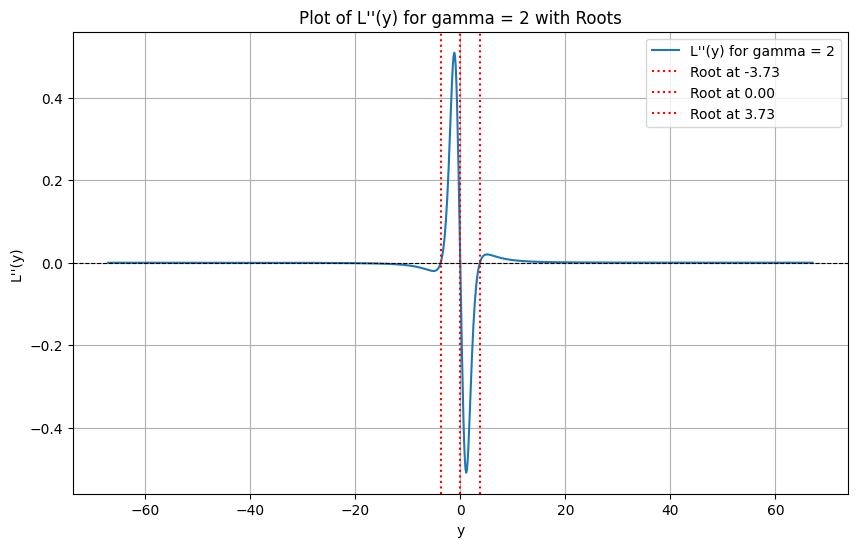

For gamma = 5:
  Root found at y = -8.774410
  Root found at y = -0.000000
  Root found at y = 8.774410


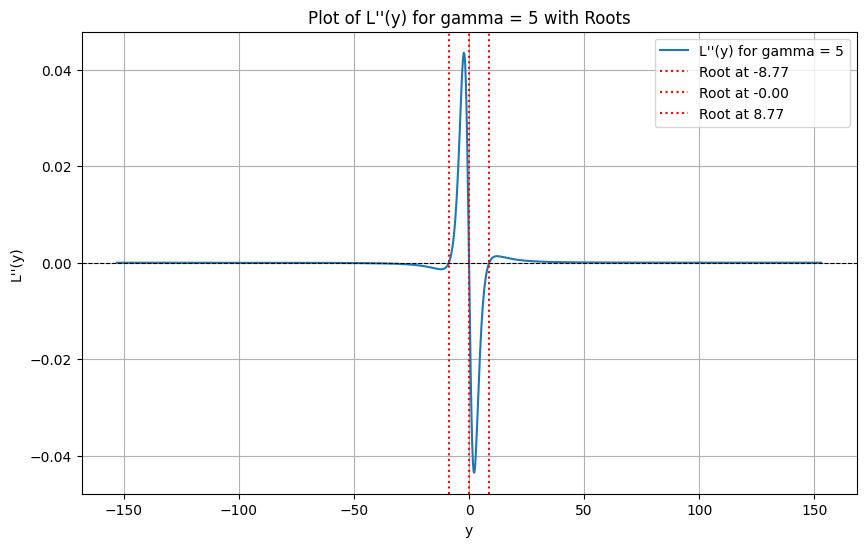

For gamma = 10:
  Root found at y = -17.378080
  Root found at y = 0.000000
  Root found at y = 17.378080


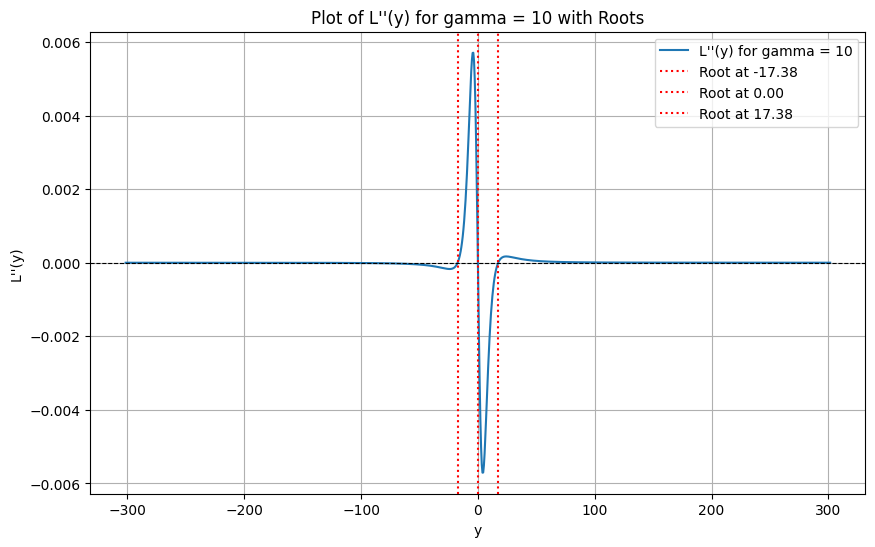

In [ ]:
# =========================================================================
# Numerical Root Finding for L''(y) = 0
#
# PURPOSE:
#   Finds the exact y values where L''(y) = 0 for each gamma.  These are
#   the inflection points of the Cauchy LLR and represent locations where
#   the curvature of R(y) changes sign — natural candidates for piecewise
#   linear breakpoints.
#
# METHOD:
#   1. Scan a dense grid of y values and detect sign changes of L''(y).
#   2. Refine each crossing with scipy.fsolve.
#   3. Deduplicate roots (rounded to 5 decimal places) and print them.
#
# NOTE: The results confirm that for all tested gamma values, L''(y) has
#   exactly two positive roots (symmetric negative counterparts exist).
# =========================================================================

import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

def L_double_prime(y, gamma):
    """Calculates L''(y) based on the given formula."""
    term1_numerator = 2 * gamma**2 - 2 * (y + 1)**2
    term1_denominator = (gamma**2 + (y + 1)**2)**2
    term1 = term1_numerator / term1_denominator

    term2_numerator = 2 * gamma**2 - 2 * (y - 1)**2
    term2_denominator = (gamma**2 + (y - 1)**2)**2
    term2 = term2_numerator / term2_denominator

    return term1 - term2

# Define gamma values
gamma_values = [0.25, 0.5, 1, 2, 5, 10]

for gamma_val in gamma_values:
    # Define a wider range for y values to ensure roots are captured
    y_values = np.linspace(-30 * np.sqrt(1 + gamma_val**2), 30 * np.sqrt(1 + gamma_val**2), 1000)
    l_double_prime_values = L_double_prime(y_values, gamma_val)

    # Find where the sign changes (approximate roots)
    zero_crossings = np.where(np.diff(np.sign(l_double_prime_values)))[0]

    # Store unique roots found for the current gamma_val
    found_roots = set()
    for idx in zero_crossings:
        # Use the point before the sign change as an initial guess
        initial_guess = y_values[idx]
        try:
            # Use fsolve to find the root more precisely
            root = fsolve(L_double_prime, initial_guess, args=(gamma_val,))
            # Add root to set, rounding to avoid floating point duplicates
            found_roots.add(round(root[0], 5))
        except Exception as e:
            # fsolve might fail for some initial guesses or ranges
            pass

    # Sort the roots for cleaner output
    sorted_roots = sorted(list(found_roots))

    print(f"For gamma = {gamma_val}:")
    if sorted_roots:
        for root in sorted_roots:
            print(f"  Root found at y = {root:.6f}")
    else:
        print("  No roots found in the considered range.")

    # Optional: Plot to verify the roots visually
    '''plt.figure(figsize=(10, 6))
    plt.plot(y_values, l_double_prime_values, label=f"L''(y) for gamma = {gamma_val}")
    plt.xlabel('y')
    plt.ylabel("L''(y)")
    plt.title(f"Plot of L''(y) for gamma = {gamma_val} with Roots")
    plt.grid(True)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    for root in sorted_roots:
        plt.axvline(root, color='red', linestyle=':', label=f'Root at {root:.2f}')
    plt.legend()
    plt.ylim(min(0, l_double_prime_values.min() * 1.1), max(0, l_double_prime_values.max() * 1.1))
    plt.show()'''

For gamma = 0.25, L''(y) root found at y = -1.256140
For gamma = 0.25, L''(y) root found at y = -0.739670
For gamma = 0.25, L''(y) root found at y = -0.000000
For gamma = 0.25, L''(y) root found at y = 0.739670
For gamma = 0.25, L''(y) root found at y = 1.256140


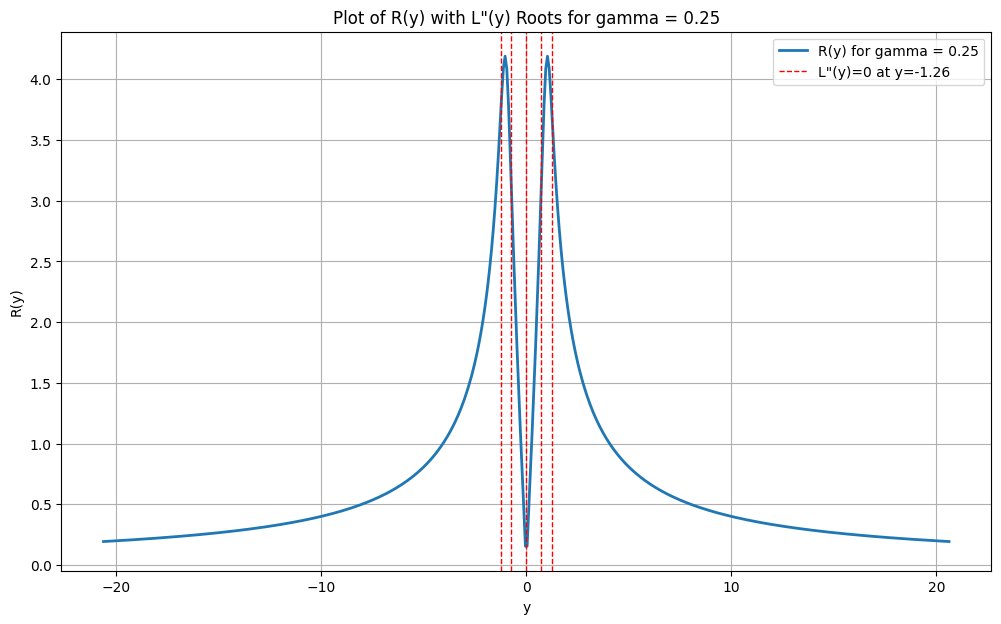

For gamma = 0.5, L''(y) root found at y = -1.538840
For gamma = 0.5, L''(y) root found at y = -0.363270
For gamma = 0.5, L''(y) root found at y = 0.000000
For gamma = 0.5, L''(y) root found at y = 0.363270
For gamma = 0.5, L''(y) root found at y = 1.538840


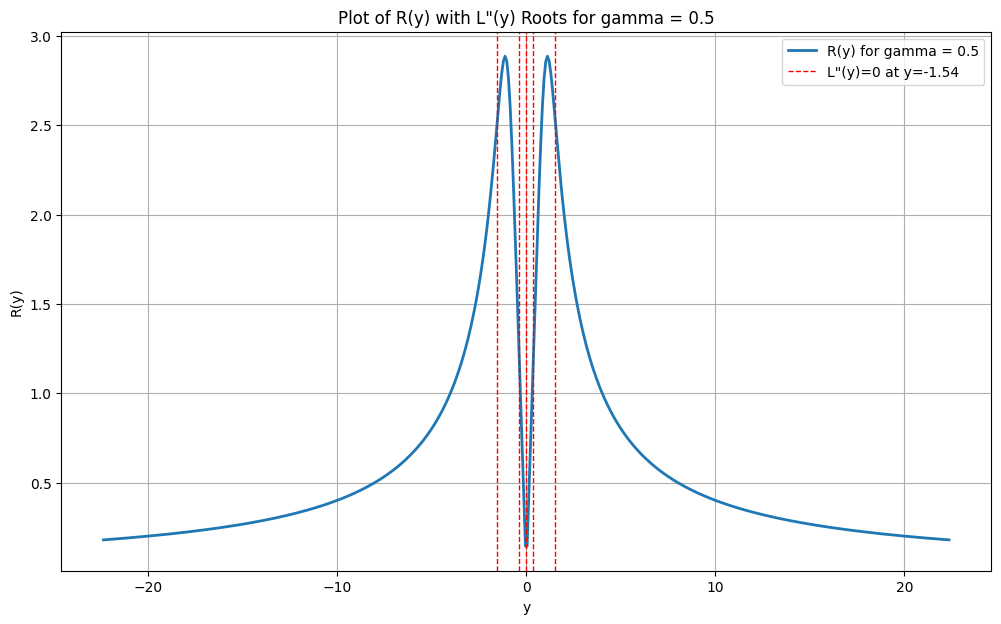

For gamma = 1, L''(y) root found at y = -2.197370
For gamma = 1, L''(y) root found at y = 0.000000
For gamma = 1, L''(y) root found at y = 2.197370


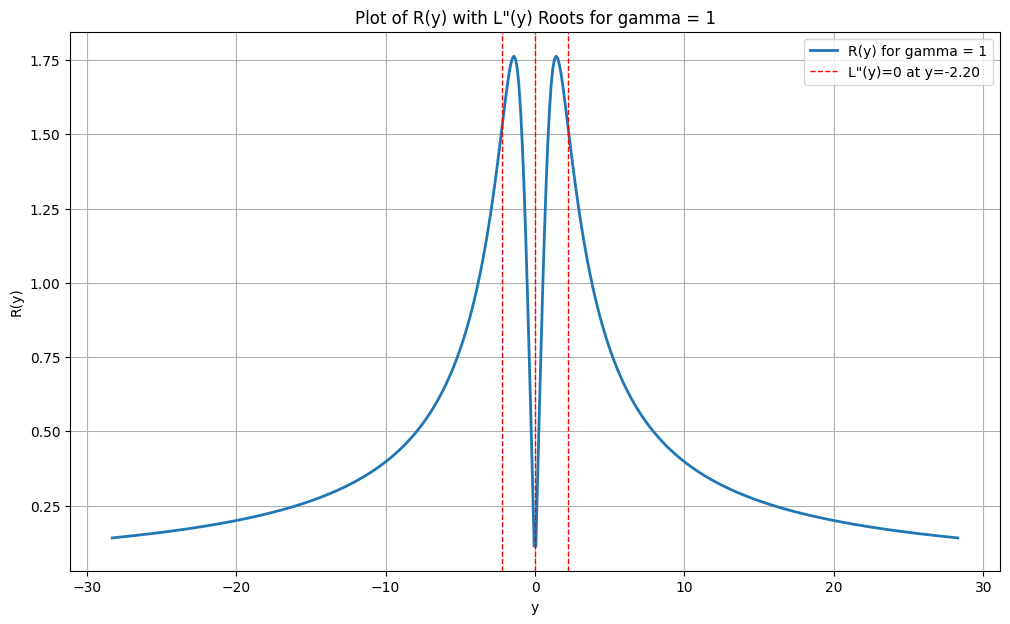

For gamma = 2, L''(y) root found at y = -3.734200
For gamma = 2, L''(y) root found at y = 0.000000
For gamma = 2, L''(y) root found at y = 3.734200


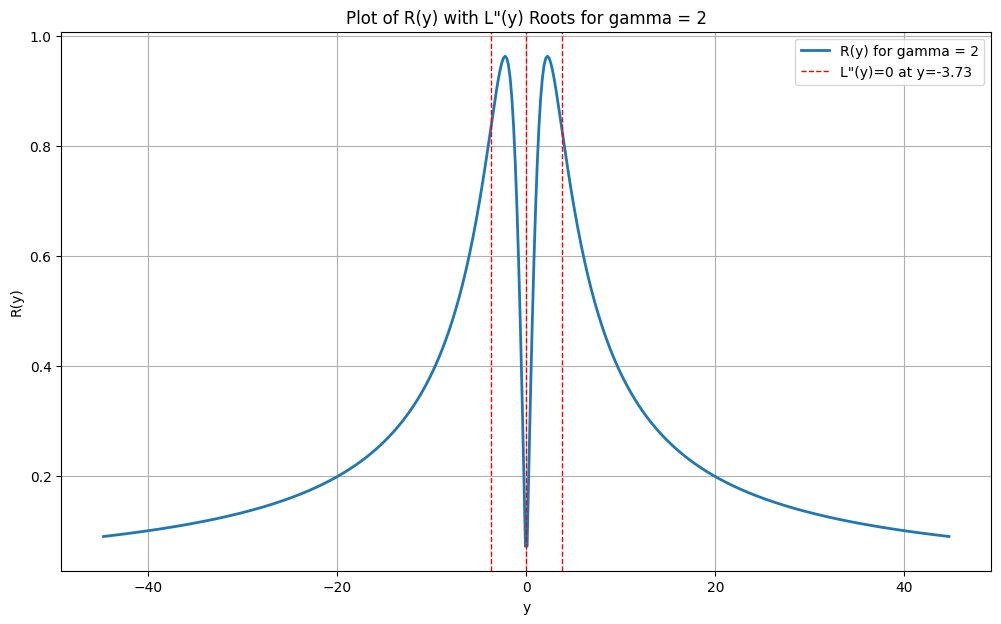

For gamma = 5, L''(y) root found at y = -8.774410
For gamma = 5, L''(y) root found at y = -0.000000
For gamma = 5, L''(y) root found at y = 8.774410


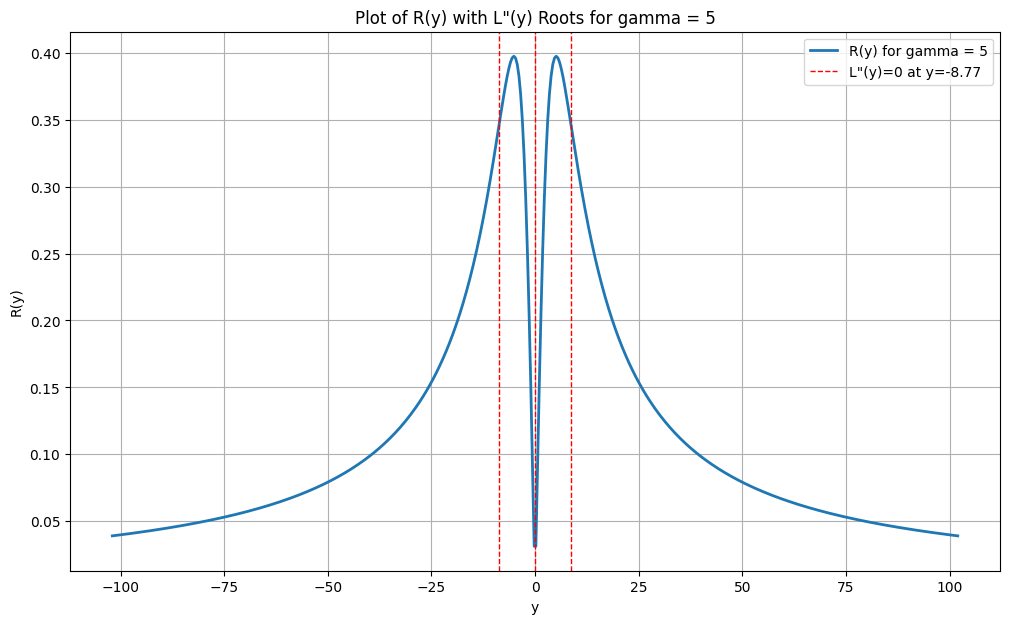

For gamma = 10, L''(y) root found at y = -17.378080
For gamma = 10, L''(y) root found at y = 0.000000
For gamma = 10, L''(y) root found at y = 17.378080


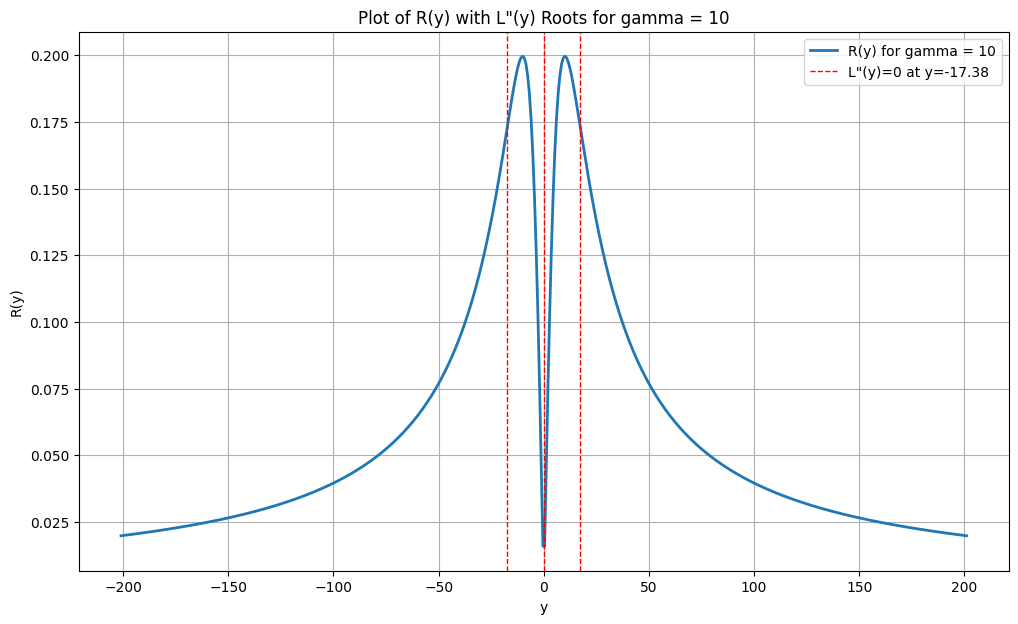

In [ ]:
# =========================================================================
# R(y) Plotted with L''(y) = 0 Roots Marked
#
# PURPOSE:
#   Overlays the roots of L''(y) (inflection points of L) on the reliability
#   curve R(y) as vertical dashed red lines.  This visually confirms that
#   these analytical inflection points coincide with natural shape changes
#   in R(y) — the locations where a piecewise linear approximation would
#   most benefit from a new segment breakpoint.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma^2 + (y+1)^2) - log(gamma^2 + (y-1)^2)|."""
    return np.abs(np.log(gamma**2 + (y + 1)**2) - np.log(gamma**2 + (y - 1)**2))

def L_double_prime(y, gamma):
    """Calculates L''(y) based on the given formula."""
    term1_numerator = 2 * gamma**2 - 2 * (y + 1)**2
    term1_denominator = (gamma**2 + (y + 1)**2)**2
    term1 = term1_numerator / term1_denominator

    term2_numerator = 2 * gamma**2 - 2 * (y - 1)**2
    term2_denominator = (gamma**2 + (y - 1)**2)**2
    term2 = term2_numerator / term2_denominator

    return term1 - term2

# Define gamma values, consistent with previous cells
gamma_values = [0.25, 0.5, 1, 2, 5, 10]

for gamma_val in gamma_values:
    # Define a range for y values for plotting
    y_plot_range = np.linspace(-20 * np.sqrt(1 + gamma_val**2), 20 * np.sqrt(1 + gamma_val**2), 500)

    # Calculate R(y) values for plotting
    r_values = R_function(y_plot_range, gamma_val)

    # --- Re-find roots of L''(y) for the current gamma_val ---
    # Define a wider range for y values to ensure roots are captured for fsolve
    y_fsolve_range = np.linspace(-30 * np.sqrt(1 + gamma_val**2), 30 * np.sqrt(1 + gamma_val**2), 1000)
    l_double_prime_values_fsolve = L_double_prime(y_fsolve_range, gamma_val)

    # Find where the sign changes (approximate roots)
    zero_crossings = np.where(np.diff(np.sign(l_double_prime_values_fsolve)))[0]

    found_roots = set()
    for idx in zero_crossings:
        initial_guess = y_fsolve_range[idx]
        try:
            root = fsolve(L_double_prime, initial_guess, args=(gamma_val,))
            found_roots.add(round(root[0], 5))
        except Exception as e:
            pass
    sorted_roots = sorted(list(found_roots))
    # --------------------------------------------------------

    # Plotting
    plt.figure(figsize=(12, 7))
    plt.plot(y_plot_range, r_values, label=f'R(y) for gamma = {gamma_val}', linewidth=2)
    plt.xlabel('y')
    plt.ylabel('R(y)')
    plt.title(f'Plot of R(y) with L"(y) Roots for gamma = {gamma_val}')
    plt.grid(True)

    if sorted_roots:
        for root in sorted_roots:
            # Plot vertical line at each root, ensuring it's within the plot range
            if y_plot_range.min() <= root <= y_plot_range.max():
                plt.axvline(root, color='red', linestyle='--', linewidth=1, label=f'L"(y)=0 at y={root:.2f}' if root == sorted_roots[0] else "") # Label only once
            print(f"For gamma = {gamma_val}, L''(y) root found at y = {root:.6f}")
    else:
        print(f"For gamma = {gamma_val}, no L''(y) roots found in the considered range.")

    plt.legend()
    plt.show()


#Trying points

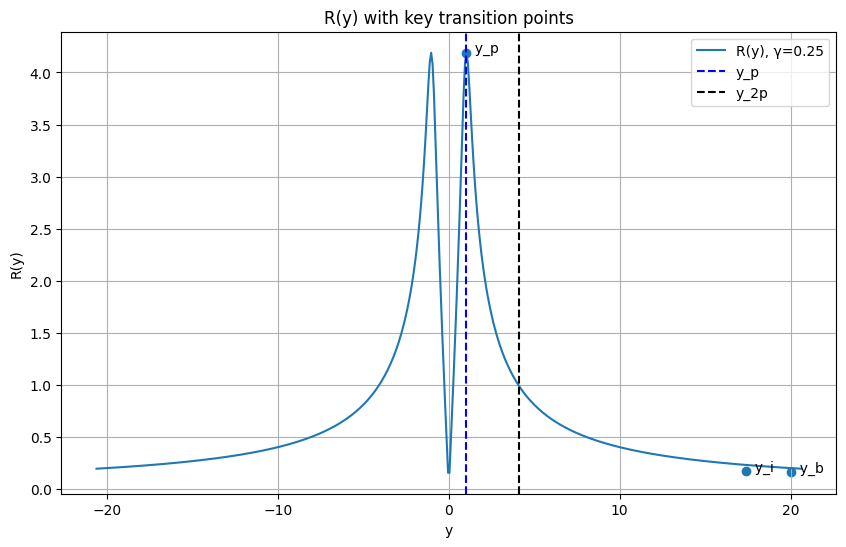

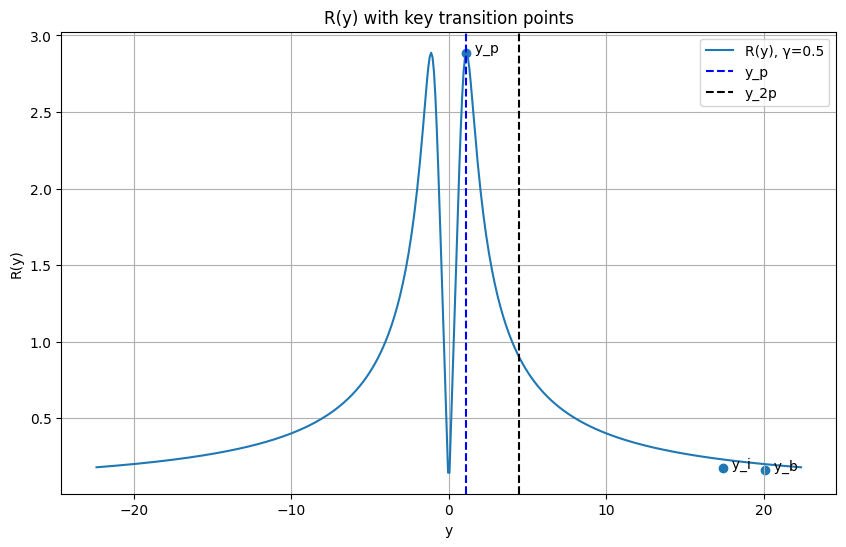

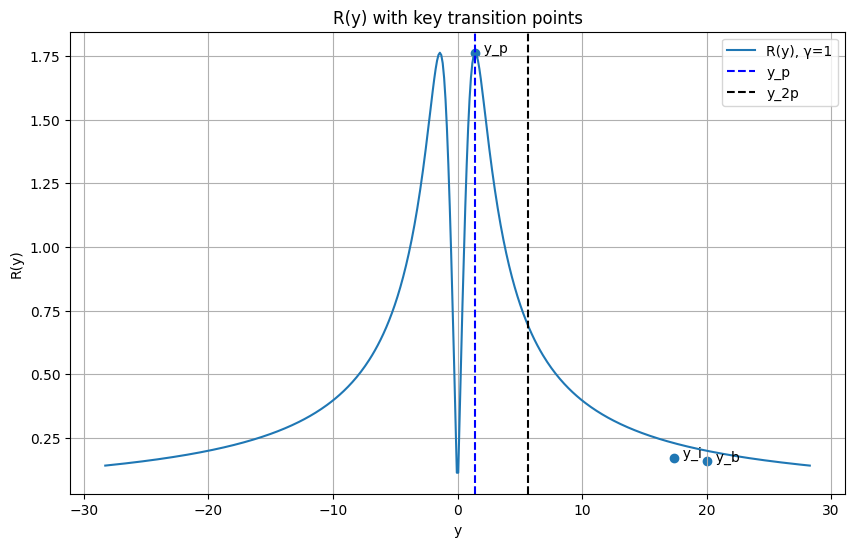

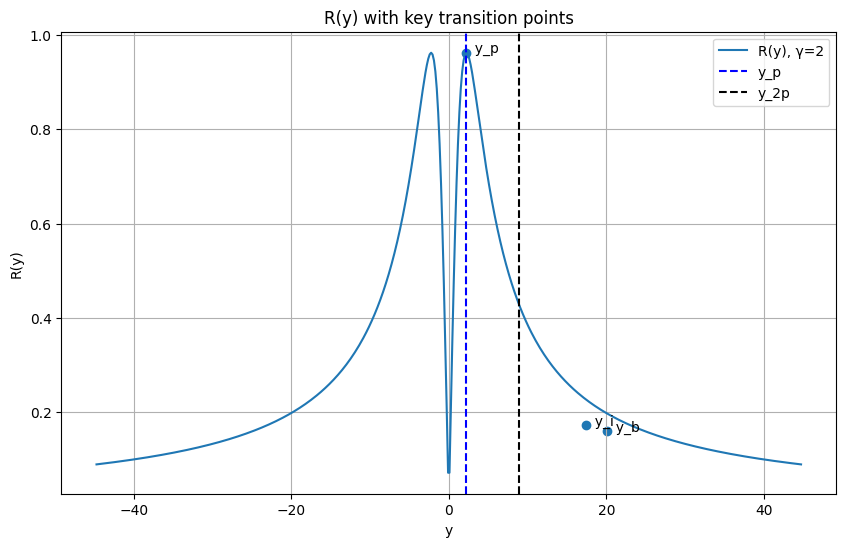

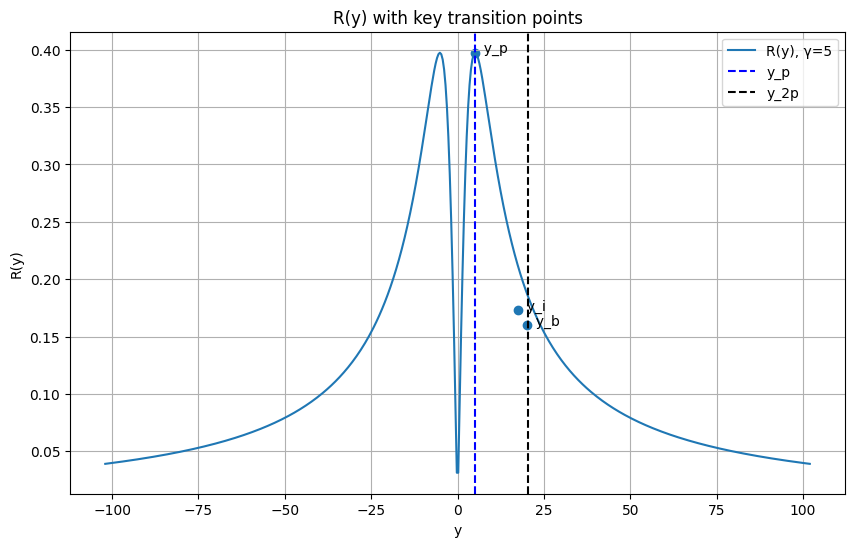

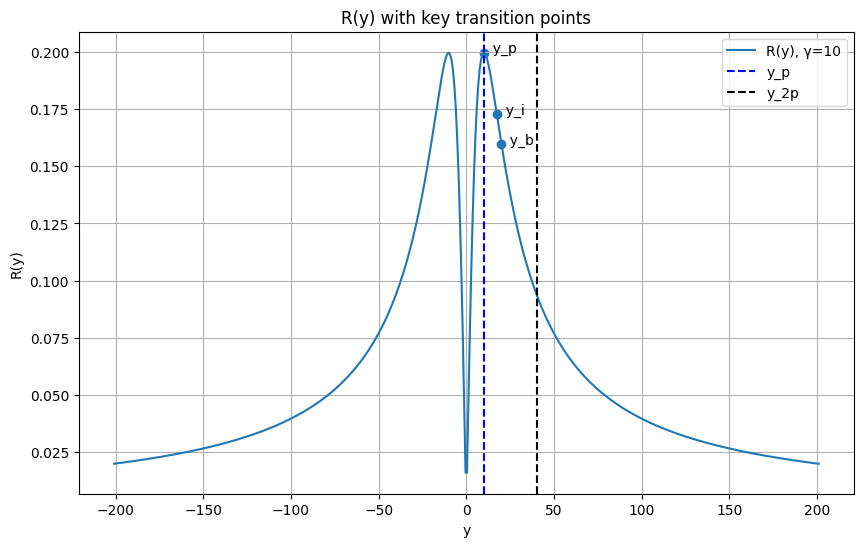

In [ ]:
# =========================================================================
# Candidate Analytical Breakpoints for the Piecewise Linear Fit
#
# PURPOSE:
#   Explores several analytically derived candidate breakpoints for the
#   piecewise linear approximation, plotted on R(y) to assess their
#   geometric relevance.
#
# CANDIDATE POINTS (all expressed as functions of gamma):
#   y_p = sqrt(1 + gamma^2)
#       Peak of R(y): analytically exact, used as the first breakpoint t1.
#
#   y_b = sqrt(1+gamma^2) + gamma
#       A heuristic point one 'gamma-step' past the peak.
#
#   y_i = sqrt(1 + gamma^2 + 2*gamma*sqrt(1+gamma^2))
#       Another analytically motivated candidate.
#
#   y_b_sq = (1 + gamma^2) + gamma
#       Variant of y_b with the square root absorbed.
#
#   y_i_sq = 1 + gamma^2 + 2*gamma*sqrt(1+gamma^2)
#       Variant of y_i without outer square root.
#
#   y_g = 4/(1+gamma^2)
#       A slope-based candidate: where the initial slope of R equals a
#       fixed fraction of the peak value.
#
# Each point is marked on the plot to visually assess whether it coincides
# with a natural change in the shape of R(y).
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def R_function(y, gamma):
    return np.abs(np.log(gamma**2 + (y + 1)**2) - np.log(gamma**2 + (y - 1)**2))

for gamma_val in [0.25, 0.5, 1, 2, 5, 10]:

    # Define y range
    y_values = np.linspace(-20*np.sqrt(1+gamma_val**2),
                           20*np.sqrt(1+gamma_val**2), 500)

    # Compute R(y)
    r_values = R_function(y_values, gamma_val)

    # ---- Key points ----
    yp = np.sqrt(1 + gamma_val**2)
    y2p = 2*np.sqrt(1 + gamma_val**2)
    yb = np.sqrt(1 + gamma_val**2) + gamma_val
    yi = np.sqrt(1 + gamma_val**2 + 2*gamma_val*np.sqrt(1 + gamma_val**2))
    yb_sq = (1 + gamma_val**2) + gamma_val
    yi_sq = (1 + gamma_val**2 + 2*gamma_val*np.sqrt(1 + gamma_val**2))
    yg= (4)/((1+gamma_val**2))

    # Compute R at those points
    Rp = R_function(yp, gamma_val)
    R2p = R_function(y2p, gamma_val)
    Rb = R_function(yb, gamma_val)
    Ri = R_function(yi, gamma_val)
    Rb_sq = R_function(yb_sq, gamma_val)
    Ri_sq = R_function(yi_sq, gamma_val)
    Rg = R_function(yg, gamma_val)

    # ---- Plot ----
    plt.figure(figsize=(10, 6))
    plt.plot(y_values, r_values, label=f'R(y), γ={gamma_val}')

    # Vertical lines
    plt.axvline(yp, linestyle='--', label='y_p', color="blue")
    plt.axvline(yb, linestyle='--', label='y_b', color="yellow")
    plt.axvline(yi, linestyle='--', label='y_i', color="red")
    plt.axvline(yb_sq, linestyle='--', label='y_b_sq', color="green")
    plt.axvline(yi_sq, linestyle='--', label='y_i_sq', color="orange")
    plt.axvline(yg, linestyle='--', label='y_g', color="purple")

    # Mark points on curve
    plt.scatter([yp, yb, yi], [Rp, Rb, Ri])

    # Labels near points
    plt.text(yp, Rp, '  y_p')
    plt.text(yb, Rb, '  y_b')
    plt.text(yi, Ri, '  y_i')

    plt.xlabel('y')
    plt.ylabel('R(y)')
    plt.title('R(y) with key transition points')
    plt.grid(True)
    plt.legend()
    plt.show()

/tmp/ipykernel_14791/3803091057.py:39: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y_sol = fsolve(objective, y_thresh * 2)[0]


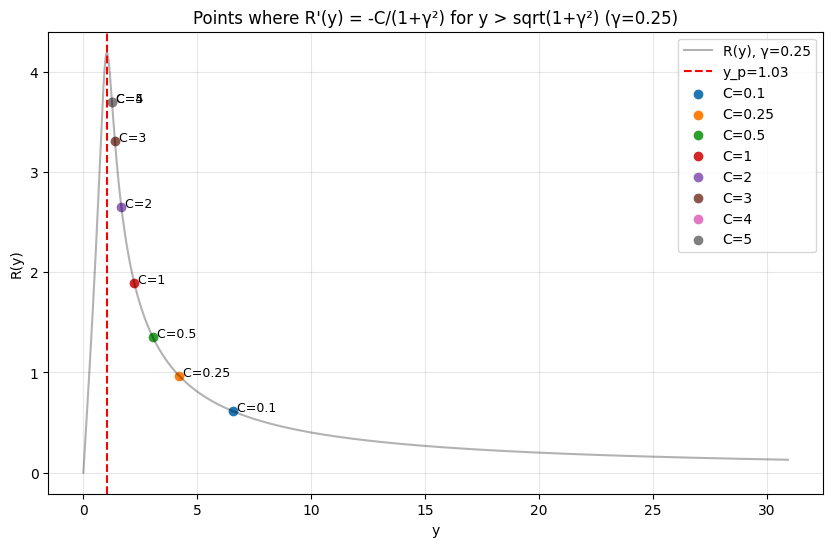

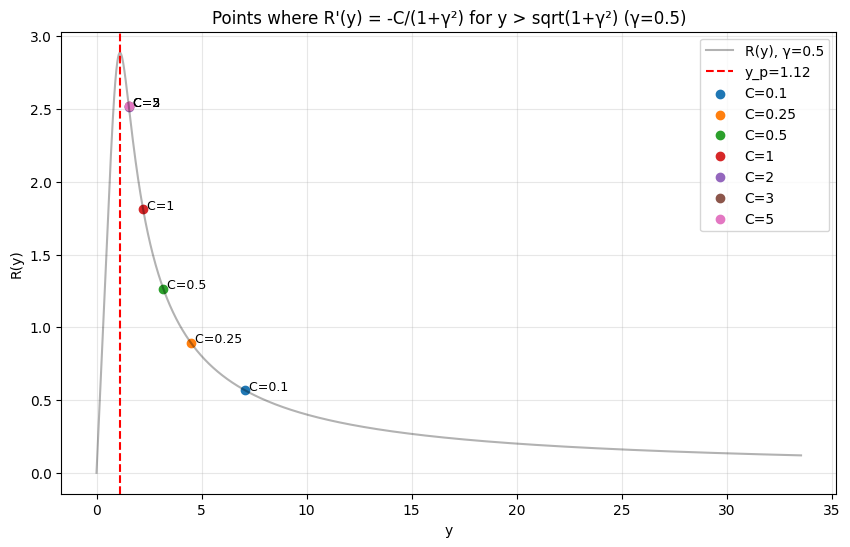

/tmp/ipykernel_14791/3803091057.py:39: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  y_sol = fsolve(objective, y_thresh * 2)[0]


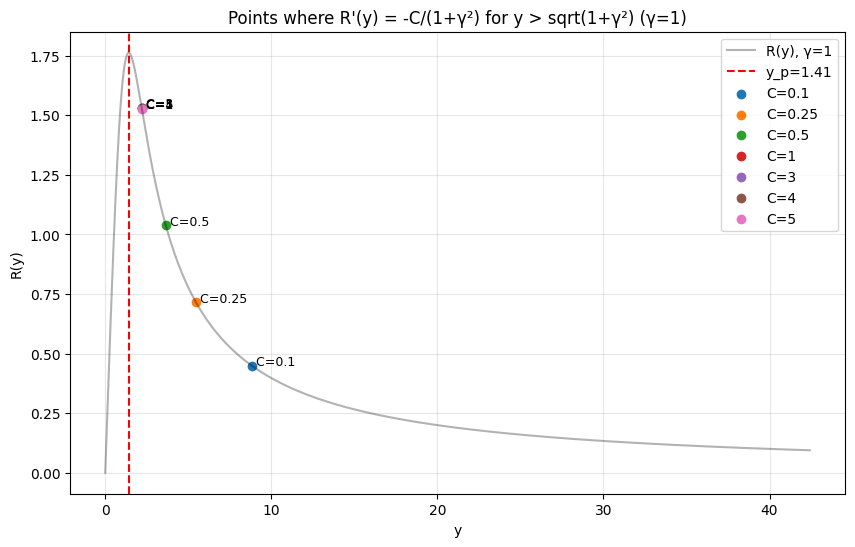

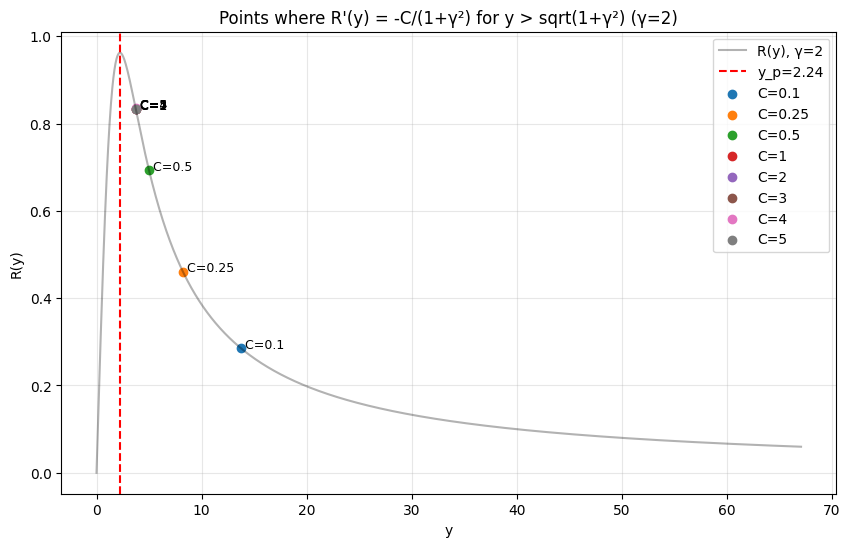

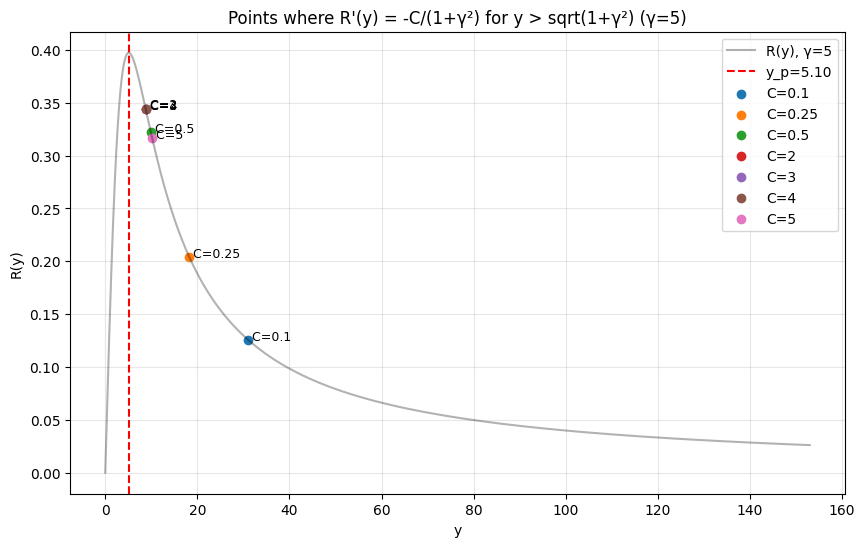

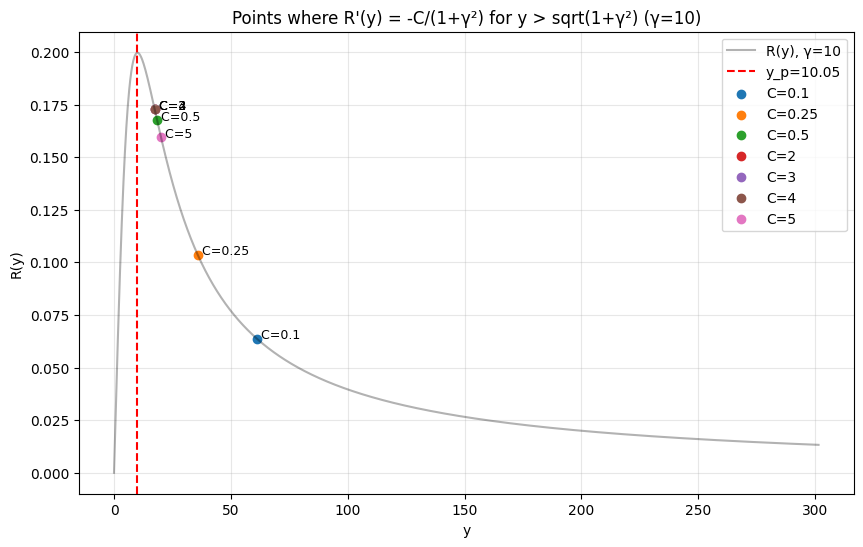

In [ ]:
# =========================================================================
# Points Where R'(y) = -C/(1+gamma^2) for Various C
#
# PURPOSE:
#   The slope of R(y) starts at R'(0+) = 4/(1+gamma^2), peaks negatively
#   after the peak, and decays toward zero as y -> inf.  This cell finds the
#   y values (past the peak) where R'(y) equals a negative threshold
#   -C/(1+gamma^2) for a range of C values.
#
# RELEVANCE TO BREAKPOINT SELECTION:
#   The second breakpoint t2 in the piecewise linear approximation
#   (used in cauchy_llr_approx.m) is defined as the point where
#   R'(y) = -epsilon * R'(0+) = -0.1 * 4/(1+gamma^2).
#   This corresponds to C = 0.4 in the parameterisation here.
#   Plotting several C values reveals how the breakpoint location varies
#   and which C gives the best visual fit to the descending tail.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def R_function(y, gamma):
    return np.abs(np.log(gamma**2 + (y + 1)**2) - np.log(gamma**2 + (y - 1)**2))

def R_prime(y, gamma):
    # For y > 0, R(y) = log(gamma^2 + (y+1)^2) - log(gamma^2 + (y-1)^2)
    term1 = (2 * (y + 1)) / (gamma**2 + (y + 1)**2)
    term2 = (2 * (y - 1)) / (gamma**2 + (y - 1)**2)
    return term1 - term2

gamma_values = [0.25, 0.5, 1, 2, 5, 10]
C_values = [0.1, 0.25, 0.5, 1, 2, 3, 4, 5]

for g in gamma_values:
    y_thresh = np.sqrt(1 + g**2)
    # Broad range for plotting and searching
    y_plot = np.linspace(0, 30 * y_thresh, 2000)
    r_plot = R_function(y_plot, g)

    plt.figure(figsize=(10, 6))
    plt.plot(y_plot, r_plot, label=f'R(y), γ={g}', color='black', alpha=0.3)
    plt.axvline(y_thresh, color='red', linestyle='--', label=f'y_p={y_thresh:.2f}')

    for C in C_values:
        target_slope = -C / (1 + g**2)

        # Search for R'(y) = target_slope for y > y_thresh
        # Since R'(y) goes from 0 at y_p to slightly negative then back to 0,
        # we solve for where the derivative matches the negative target.
        def objective(y):
            return R_prime(y, g) - target_slope

        # Find solution using fsolve with a guess significantly to the right of peak
        # where the slope is negative and approaching zero.
        try:
            y_sol = fsolve(objective, y_thresh * 2)[0]
            if y_sol > y_thresh:
                r_sol = R_function(y_sol, g)
                plt.scatter(y_sol, r_sol, label=f'C={C}')
                plt.text(y_sol, r_sol, f' C={C}', fontsize=9)
        except:
            pass

    plt.title(f'Points where R\'(y) = -C/(1+γ²) for y > sqrt(1+γ²) (γ={g})')
    plt.xlabel('y')
    plt.ylabel('R(y)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

#Three pieces linear fit on Cauchy Reliability Curve

##Gemini Code

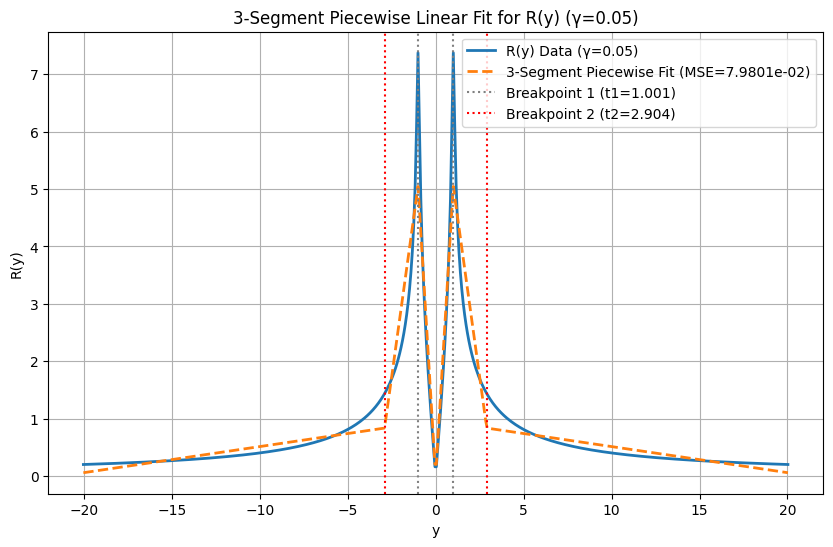


Gamma = 0.05
  First fixed breakpoint t1 = 1.0012
  Optimal second breakpoint t2 = 2.9036
  Segment 1 slope (0 to t1) = 5.0448
  Segment 2 slope (t1 to t2) = -2.2163
  Segment 3 slope (t2 onwards) = -0.0455
  Minimum MSE = 7.9801e-02


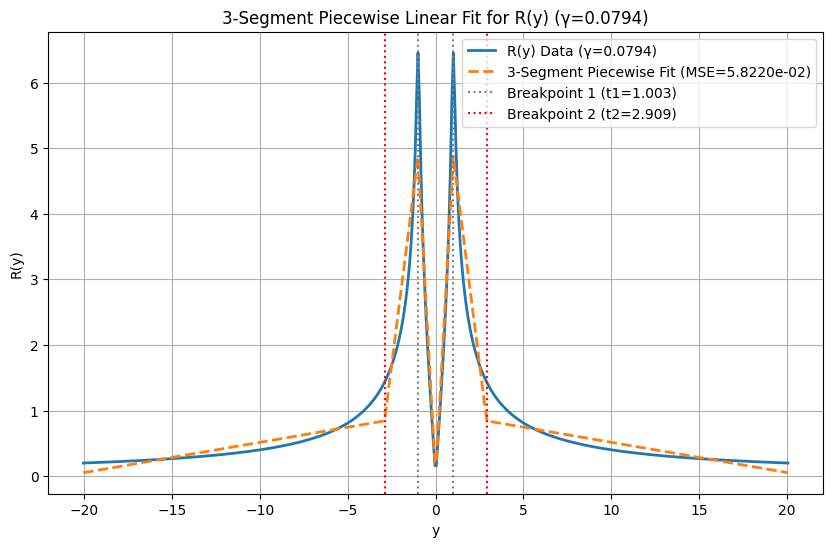


Gamma = 0.0794
  First fixed breakpoint t1 = 1.0031
  Optimal second breakpoint t2 = 2.9091
  Segment 1 slope (0 to t1) = 4.8600
  Segment 2 slope (t1 to t2) = -2.1159
  Segment 3 slope (t2 onwards) = -0.0461
  Minimum MSE = 5.8220e-02


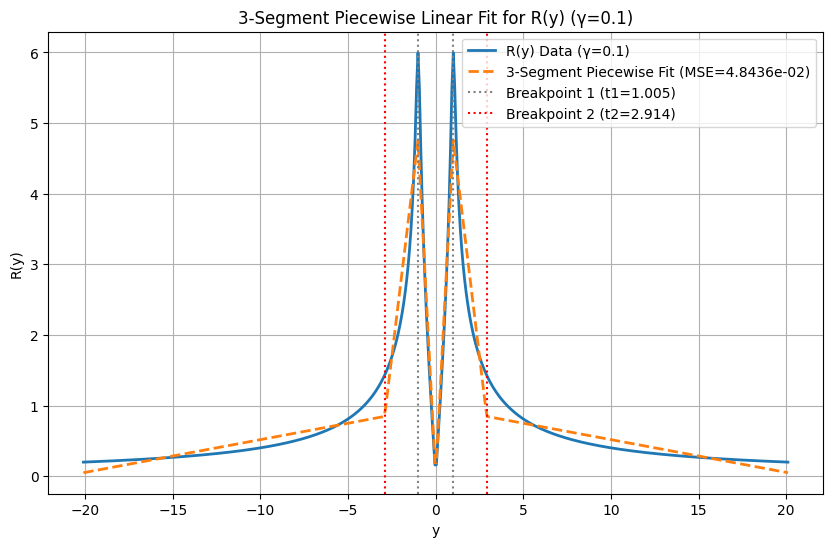


Gamma = 0.1
  First fixed breakpoint t1 = 1.0050
  Optimal second breakpoint t2 = 2.9145
  Segment 1 slope (0 to t1) = 4.7351
  Segment 2 slope (t1 to t2) = -2.0490
  Segment 3 slope (t2 onwards) = -0.0464
  Minimum MSE = 4.8436e-02


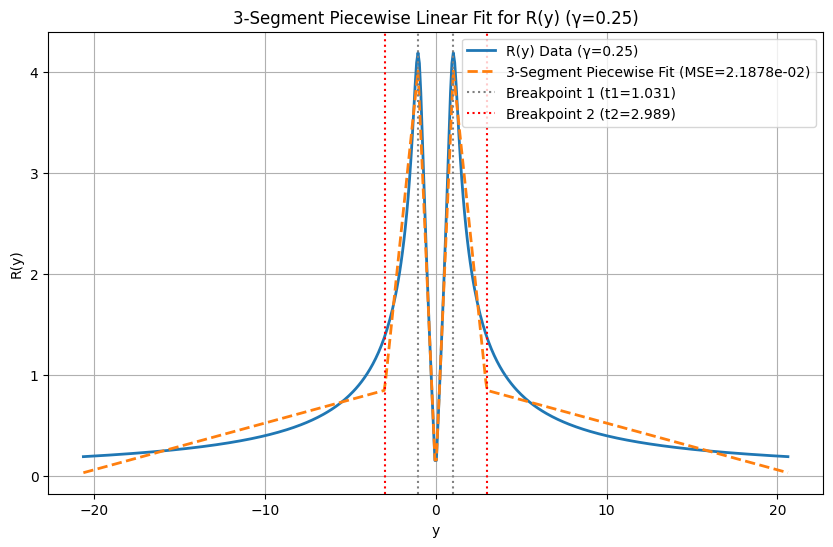


Gamma = 0.25
  First fixed breakpoint t1 = 1.0308
  Optimal second breakpoint t2 = 2.9893
  Segment 1 slope (0 to t1) = 3.8928
  Segment 2 slope (t1 to t2) = -1.6148
  Segment 3 slope (t2 onwards) = -0.0462
  Minimum MSE = 2.1878e-02


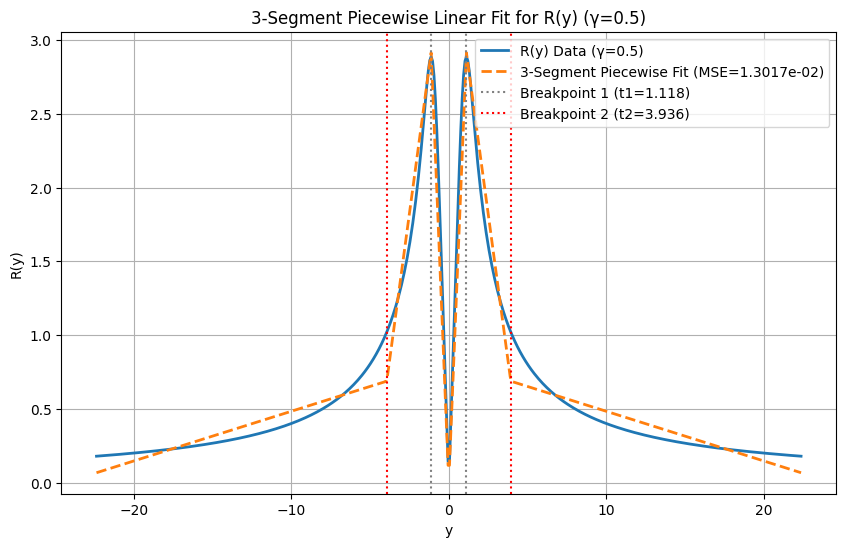


Gamma = 0.5
  First fixed breakpoint t1 = 1.1180
  Optimal second breakpoint t2 = 3.9359
  Segment 1 slope (0 to t1) = 2.6081
  Segment 2 slope (t1 to t2) = -0.7908
  Segment 3 slope (t2 onwards) = -0.0337
  Minimum MSE = 1.3017e-02


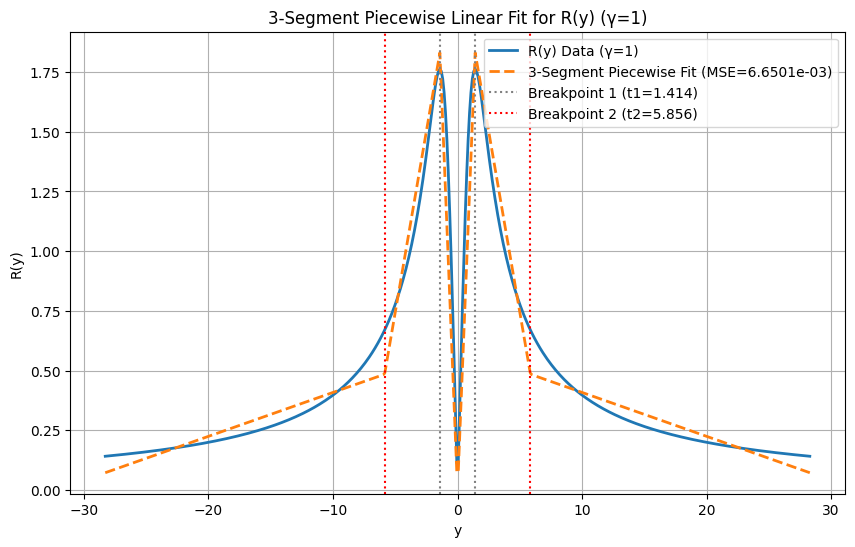


Gamma = 1
  First fixed breakpoint t1 = 1.4142
  Optimal second breakpoint t2 = 5.8560
  Segment 1 slope (0 to t1) = 1.2953
  Segment 2 slope (t1 to t2) = -0.3033
  Segment 3 slope (t2 onwards) = -0.0184
  Minimum MSE = 6.6501e-03


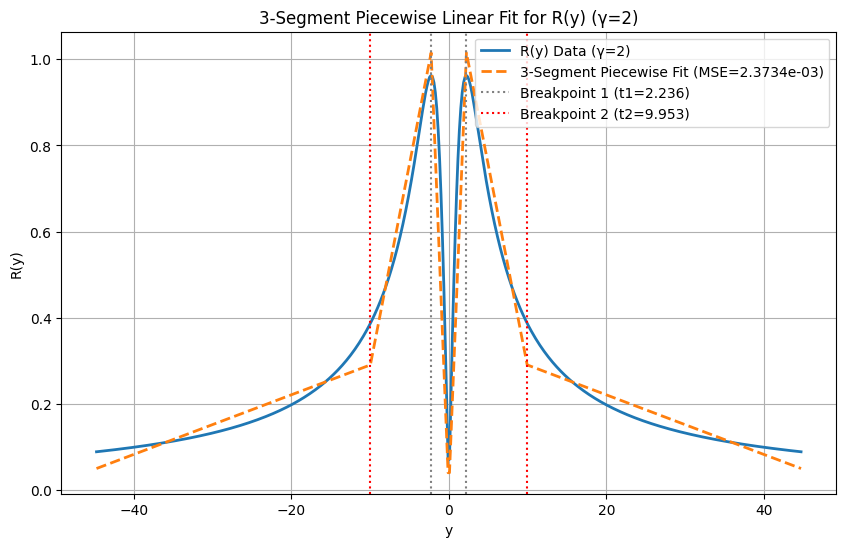


Gamma = 2
  First fixed breakpoint t1 = 2.2361
  Optimal second breakpoint t2 = 9.9528
  Segment 1 slope (0 to t1) = 0.4542
  Segment 2 slope (t1 to t2) = -0.0939
  Segment 3 slope (t2 onwards) = -0.0069
  Minimum MSE = 2.3734e-03


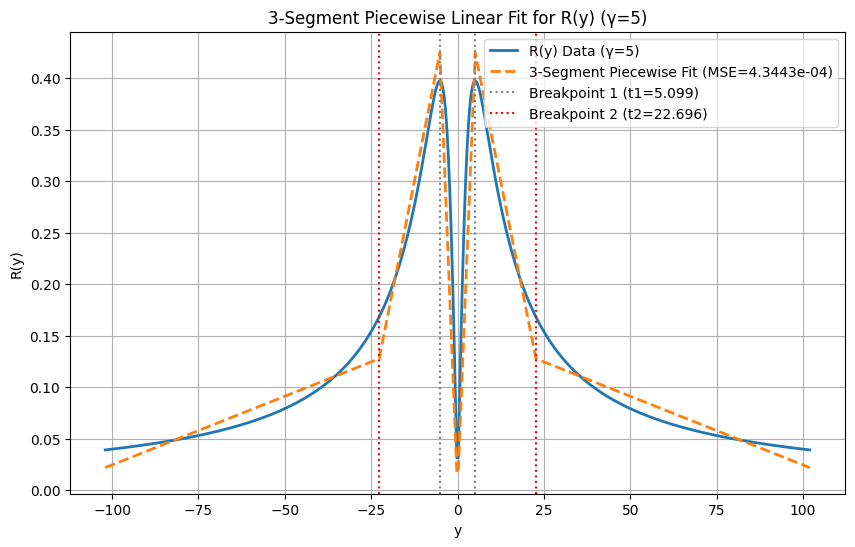


Gamma = 5
  First fixed breakpoint t1 = 5.0990
  Optimal second breakpoint t2 = 22.6958
  Segment 1 slope (0 to t1) = 0.0833
  Segment 2 slope (t1 to t2) = -0.0169
  Segment 3 slope (t2 onwards) = -0.0013
  Minimum MSE = 4.3443e-04


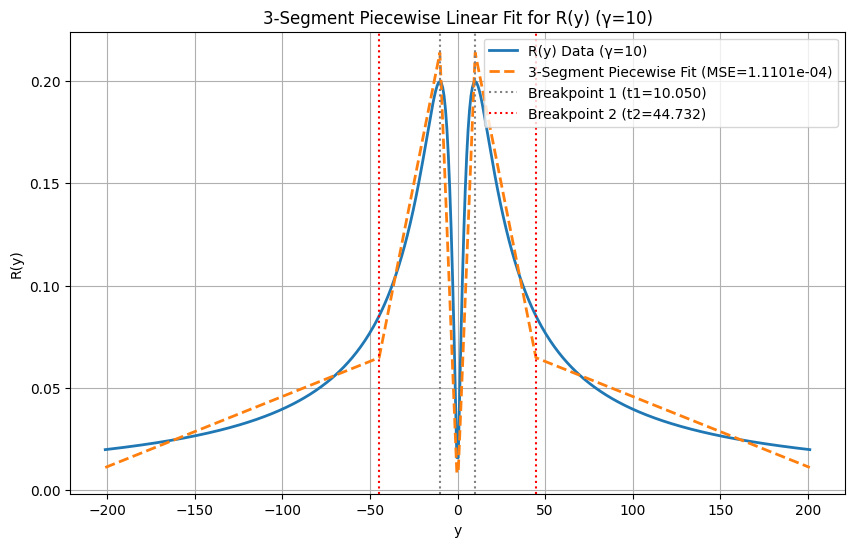


Gamma = 10
  First fixed breakpoint t1 = 10.0499
  Optimal second breakpoint t2 = 44.7322
  Segment 1 slope (0 to t1) = 0.0213
  Segment 2 slope (t1 to t2) = -0.0043
  Segment 3 slope (t2 onwards) = -0.0003
  Minimum MSE = 1.1101e-04


In [ ]:
# =========================================================================
# Three-Segment Piecewise Linear Fit — Working Directly on R(y)
#
# PURPOSE:
#   Fits the 3-piece approximation directly to the exact analytical R(y)
#   curve (not to a Monte Carlo average) using least squares with a fixed
#   first breakpoint t1 = sqrt(1+gamma^2) and an optimised second breakpoint t2.
#
# KEY DIFFERENCE FROM Cauchy_VIP.ipynb:
#   Here the input data is the EXACT R(y) function evaluated on a fine grid
#   (not a Monte Carlo average of sorted reliabilities), and the x-axis is
#   the actual received-value axis y (not the normalised rank j/n).
#
# MODEL (hinge form):
#   R_approx(y) = c1*y + c2*max(0, y-t1) + c3*max(0, y-t2)
#   This is a continuous piecewise linear function with slopes:
#     Segment 1 [0,  t1]: c1
#     Segment 2 [t1, t2]: c1+c2
#     Segment 3 [t2, inf): c1+c2+c3
#
# BREAKPOINT SEARCH FOR t2:
#   t2 is scanned over 50 candidate values in [t1+10%, t1+90%*(y_max-t1)].
#   The candidate minimising MSE is selected.  t1 is fixed analytically.
#
# NOTE: This is the same structural model as in cauchy_llr_approx.m,
#   but the breakpoints are found by grid-search MSE minimisation rather
#   than the slope-threshold criterion used in the MATLAB implementation.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma^2 + (y+1)^2) - log(gamma^2 + (y-1)^2)|."""
    # Ensure the argument to log is positive and handle potential domain issues
    arg1 = gamma**2 + (y + 1)**2
    arg2 = gamma**2 + (y - 1)**2

    # For very small y values or large gamma, args can be very close, log will be small
    # np.log(0) gives -inf, which abs would make inf. Filter out y where args are too close.
    # Using a small epsilon to avoid issues, though log(positive) should be fine.
    return np.abs(np.log(arg1) - np.log(arg2))


def piecewise_linear_fit_3_segments_mse(y_data_pos, r_data_pos, t1_fixed):
    """
    Performs a three-segment continuous piecewise linear fit for y_data_pos >= 0.
    The first segment starts at (0,0) and extends to t1_fixed.
    The second breakpoint (t2) is found by minimizing MSE.
    Model: R(y) = c1*y + c2*max(0, y-t1) + c3*max(0, y-t2)
    Slopes: s1=c1, s2=c1+c2, s3=c1+c2+c3
    """
    best_mse = np.inf
    best_params = None
    best_yhat_pos = None

    # Define search range for t2. t2 must be > t1_fixed and less than max_y
    # Use a fraction of the remaining range after t1_fixed
    y_max_data = y_data_pos.max()
    t2_search_min = t1_fixed + (y_max_data - t1_fixed) * 0.1 # Start search 10% after t1_fixed
    t2_search_max = t1_fixed + (y_max_data - t1_fixed) * 0.9 # End search 90% after t1_fixed

    if t2_search_min >= t2_search_max:
        # Not enough range to search for t2, fall back to two segments from t1
        # Or simplify the model if t1_fixed is very close to y_max_data
        print(f"Warning: Insufficient range for t2 search (t1={t1_fixed:.3f}, y_max={y_max_data:.3f}). Skipping this gamma.")
        return None

    # Generate possible t2 values to iterate through
    # Ensuring t2_candidates are within y_data_pos range and ordered
    t2_candidates_all = np.linspace(t2_search_min, t2_search_max, 50)
    # Filter t2_candidates to be within the actual data range
    t2_candidates = [t for t in t2_candidates_all if t1_fixed < t < y_max_data]

    if not t2_candidates:
        print(f"Warning: No valid t2 candidates found. Skipping this gamma.")
        return None

    for t2_candidate in t2_candidates:
        # Design matrix for y = c1*y + c2*max(0, y-t1) + c3*max(0, y-t2)
        A_matrix = np.column_stack([
            y_data_pos,
            np.maximum(0, y_data_pos - t1_fixed),
            np.maximum(0, y_data_pos - t2_candidate)
        ])

        # Use lstsq to solve for coefficients (c1, c2, c3)
        coeffs, residuals, rank, s = np.linalg.lstsq(A_matrix, r_data_pos, rcond=None)

        yhat_pos = A_matrix @ coeffs
        mse = np.mean((r_data_pos - yhat_pos)**2)

        if mse < best_mse:
            best_mse = mse
            best_params = (coeffs, t2_candidate)
            best_yhat_pos = yhat_pos

    if best_params is None:
        return None # In case no valid t2 was found or fit failed

    c1, c2, c3 = best_params[0]
    best_t2 = best_params[1]

    s1 = c1
    s2 = c1 + c2
    s3 = c1 + c2 + c3

    return {"s1": s1, "s2": s2, "s3": s3, "t1": t1_fixed, "t2": best_t2, "mse": best_mse, "yhat_pos": best_yhat_pos}


# --- Main execution ---

# Define gamma values to plot
for gamma_val in [0.05, 0.0794, 0.1, 0.25, 0.5, 1, 2, 5, 10]:
    # Generate y_values over a broad symmetric range
    # The upper limit should be sufficient to capture all breakpoints and curve behavior
    y_full = np.linspace(-20 * np.sqrt(1 + gamma_val**2), 20 * np.sqrt(1 + gamma_val**2), 500)
    r_full_data = R_function(y_full, gamma_val)

    # Extract positive y_values for fitting
    y_data_pos = y_full[y_full >= 0]
    r_data_pos = r_full_data[y_full >= 0]

    # Define the first fixed breakpoint
    t1_fixed = np.sqrt(1 + gamma_val**2)

    fit_results = piecewise_linear_fit_3_segments_mse(y_data_pos, r_data_pos, t1_fixed)

    if fit_results:
        s1 = fit_results["s1"]
        s2 = fit_results["s2"]
        s3 = fit_results["s3"]
        t1 = fit_results["t1"]
        t2 = fit_results["t2"]
        mse = fit_results["mse"]
        yhat_pos_fit = fit_results["yhat_pos"]

        # Construct the full piecewise linear fit for plotting
        # We need to apply the fit for positive y to the entire y_full range, handling negative side
        y_fit_full = np.zeros_like(y_full)

        for i, y_val in enumerate(y_full):
            abs_y = np.abs(y_val)
            if abs_y <= t1:
                y_fit_full[i] = s1 * abs_y
            elif abs_y <= t2:
                y_fit_full[i] = s1 * t1 + s2 * (abs_y - t1)
            else:
                y_fit_full[i] = s1 * t1 + s2 * (t2 - t1) + s3 * (abs_y - t2)

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.plot(y_full, r_full_data, label=f'R(y) Data (γ={gamma_val})', linewidth=2)
        plt.plot(y_full, y_fit_full, '--', label=f'3-Segment Piecewise Fit (MSE={mse:.4e})', linewidth=2)

        plt.axvline(t1, color='gray', linestyle=':', label=f'Breakpoint 1 (t1={t1:.3f})')
        plt.axvline(t2, color='red', linestyle=':', label=f'Breakpoint 2 (t2={t2:.3f})')
        plt.axvline(-t1, color='gray', linestyle=':') # Symmetric breakpoint
        plt.axvline(-t2, color='red', linestyle=':') # Symmetric breakpoint

        plt.xlabel('y')
        plt.ylabel('R(y)')
        plt.title(f'3-Segment Piecewise Linear Fit for R(y) (γ={gamma_val})')
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"\nGamma = {gamma_val:.3g}")
        print(f"  First fixed breakpoint t1 = {t1:.4f}")
        print(f"  Optimal second breakpoint t2 = {t2:.4f}")
        print(f"  Segment 1 slope (0 to t1) = {s1:.4f}")
        print(f"  Segment 2 slope (t1 to t2) = {s2:.4f}")
        print(f"  Segment 3 slope (t2 onwards) = {s3:.4f}")
        print(f"  Minimum MSE = {mse:.4e}")
    else:
        print(f"\nCould not fit for Gamma = {gamma_val}. See warnings above.")

##ChatGPT Code

In [ ]:
# =========================================================================
# Three-Segment Piecewise Linear Fit — Continuous Constrained Version
#
# PURPOSE:
#   An alternative implementation of the 3-piece fit that enforces
#   CONTINUITY at both breakpoints y0 and y_split.  At each breakpoint,
#   the next segment's intercept is fixed so that its line value exactly
#   matches the previous segment's line value, ensuring a continuous
#   (but not differentiable) approximation.
#
# STRUCTURE:
#   - ThreePieceFit dataclass: stores all fit parameters and provides predict().
#   - cauchy_reliability(): evaluates exact R(y) on an array.
#   - _fit_line(): least-squares line fit, optionally forcing zero intercept.
#   - fit_three_piece_cauchy_reliability(): main fitting function.
#
# CONTINUITY ENFORCEMENT:
#   Segment 1: y = m1 * y  (zero-intercept, fitted on [0, y0])
#   Segment 2: y = m2*y + b2, where b2 = m1*y0 - m2*y0  (continuous at y0)
#   Segment 3: y = m3*y + b3, where b3 = m2*y_split + b2 - m3*y_split
#
# BREAKPOINT OPTIMISATION:
#   y_split is optimised with scipy.minimize_scalar (bounded golden-section
#   search) to minimise MSE, given the fixed y0 = sqrt(1+gamma^2).
#   This is more efficient than a grid scan.
# =========================================================================

import numpy as np
from dataclasses import dataclass
from typing import Tuple, Optional
from scipy.optimize import minimize_scalar


@dataclass
class ThreePieceFit:
    gamma: float
    y0: float
    y_split: float
    m1: float
    m2: float
    m3: float
    b2: float
    b3: float
    mse: float

    def predict(self, y: np.ndarray) -> np.ndarray:
        """
        Predict fitted reliability values for nonnegative y.
        """
        y = np.asarray(y, dtype=float)
        out = np.empty_like(y)

        r1 = y <= self.y0
        r2 = (y > self.y0) & (y <= self.y_split)
        r3 = y > self.y_split

        out[r1] = self.m1 * y[r1]
        out[r2] = self.m2 * y[r2] + self.b2
        out[r3] = self.m3 * y[r3] + self.b3
        return out


def cauchy_reliability(y: np.ndarray, gamma: float) -> np.ndarray:
    """
    Exact Cauchy reliability for BPSK over additive Cauchy noise.

    R(y) = | log(gamma^2 + (y+1)^2) - log(gamma^2 + (y-1)^2) |

    Only y >= 0 is needed here because the function is even.
    """
    y = np.asarray(y, dtype=float)
    return np.abs(
        np.log(gamma**2 + (y + 1.0)**2) - np.log(gamma**2 + (y - 1.0)**2)
    )


def _fit_line(x: np.ndarray, y: np.ndarray, force_intercept_zero: bool = False) -> Tuple[float, float]:
    """
    Least-squares line fit y ~= m*x + b.

    If force_intercept_zero=True, fit y ~= m*x.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.size == 0:
        raise ValueError("Empty region encountered during fitting.")

    if force_intercept_zero:
        denom = np.dot(x, x)
        m = 0.0 if denom == 0 else np.dot(x, y) / denom
        b = 0.0
        return m, b

    A = np.column_stack([x, np.ones_like(x)])
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(m), float(b)


def _piecewise_predict(
    y: np.ndarray,
    y0: float,
    y_split: float,
    m1: float,
    m2: float,
    m3: float,
    b2: float,
    b3: float,
) -> np.ndarray:
    out = np.empty_like(y)

    r1 = y <= y0
    r2 = (y > y0) & (y <= y_split)
    r3 = y > y_split

    out[r1] = m1 * y[r1]
    out[r2] = m2 * y[r2] + b2
    out[r3] = m3 * y[r3] + b3
    return out


def fit_three_piece_cauchy_reliability(
    gamma: float,
    y_max: float = 4.0,
    n_points: int = 4000,
    min_points_per_region: int = 30,
    enforce_continuity: bool = True,
) -> ThreePieceFit:
    """
    Fit a 3-piece linear approximation to the positive-half Cauchy reliability curve.

    Structure:
      Region 1: 0 <= y <= y0, with y0 = sqrt(1 + gamma^2)
                line is forced to have intercept 0
      Region 2: y0 < y <= y_split
      Region 3: y > y_split

    The split y_split is optimized to minimize MSE.

    Parameters
    ----------
    gamma : float
        Cauchy scale parameter.
    y_max : float
        Maximum y value for fitting on [0, y_max].
    n_points : int
        Number of sample points on [0, y_max].
    min_points_per_region : int
        Minimum number of grid points required in regions 2 and 3.
    enforce_continuity : bool
        If True, enforce continuity at y0 and y_split.

    Returns
    -------
    ThreePieceFit
        Fit parameters and MSE.
    """
    if gamma <= 0:
        raise ValueError("gamma must be positive.")
    if y_max <= np.sqrt(1 + gamma**2):
        raise ValueError("y_max must be larger than sqrt(1+gamma^2).")

    y0 = np.sqrt(1.0 + gamma**2)
    y = np.linspace(0.0, y_max, n_points)
    R = cauchy_reliability(y, gamma)

    # Index of first point strictly greater than y0
    idx0 = np.searchsorted(y, y0, side="right")
    if idx0 < min_points_per_region:
        raise ValueError("Not enough points in region 1. Increase n_points or y_max.")

    # Region 1 fit: intercept fixed to 0
    y_r1 = y[:idx0]
    R_r1 = R[:idx0]
    m1, _ = _fit_line(y_r1, R_r1, force_intercept_zero=True)

    # Value of line 1 at y0 for continuity use
    val_y0 = m1 * y0

    # Feasible split interval
    left_idx = idx0 + min_points_per_region
    right_idx = n_points - min_points_per_region - 1
    if left_idx >= right_idx:
        raise ValueError("Not enough points to create regions 2 and 3. Increase n_points or y_max.")

    split_low = y[left_idx]
    split_high = y[right_idx]

    def objective(y_split: float) -> float:
        # Split indices
        idx_split = np.searchsorted(y, y_split, side="right")

        y_r2 = y[idx0:idx_split]
        R_r2 = R[idx0:idx_split]
        y_r3 = y[idx_split:]
        R_r3 = R[idx_split:]

        if y_r2.size < min_points_per_region or y_r3.size < min_points_per_region:
            return np.inf

        if enforce_continuity:
            # Region 2: fit slope only with intercept fixed by continuity at y0
            # line2(y) = m2*y + b2, with b2 = val_y0 - m2*y0
            x2 = y_r2 - y0
            z2 = R_r2 - val_y0
            denom2 = np.dot(x2, x2)
            m2 = 0.0 if denom2 == 0 else np.dot(x2, z2) / denom2
            b2 = val_y0 - m2 * y0

            # Continuity at y_split
            val_split = m2 * y_split + b2

            # Region 3: fit slope only with intercept fixed by continuity at y_split
            x3 = y_r3 - y_split
            z3 = R_r3 - val_split
            denom3 = np.dot(x3, x3)
            m3 = 0.0 if denom3 == 0 else np.dot(x3, z3) / denom3
            b3 = val_split - m3 * y_split
        else:
            m2, b2 = _fit_line(y_r2, R_r2, force_intercept_zero=False)
            m3, b3 = _fit_line(y_r3, R_r3, force_intercept_zero=False)

        pred = _piecewise_predict(y, y0, y_split, m1, m2, m3, b2, b3)
        return float(np.mean((R - pred) ** 2))

    res = minimize_scalar(objective, bounds=(split_low, split_high), method="bounded")
    if not res.success:
        raise RuntimeError("Optimization for the second split failed.")

    y_split = float(res.x)
    idx_split = np.searchsorted(y, y_split, side="right")

    y_r2 = y[idx0:idx_split]
    R_r2 = R[idx0:idx_split]
    y_r3 = y[idx_split:]
    R_r3 = R[idx_split:]

    if enforce_continuity:
        x2 = y_r2 - y0
        z2 = R_r2 - val_y0
        denom2 = np.dot(x2, x2)
        m2 = 0.0 if denom2 == 0 else np.dot(x2, z2) / denom2
        b2 = val_y0 - m2 * y0

        val_split = m2 * y_split + b2

        x3 = y_r3 - y_split
        z3 = R_r3 - val_split
        denom3 = np.dot(x3, x3)
        m3 = 0.0 if denom3 == 0 else np.dot(x3, z3) / denom3
        b3 = val_split - m3 * y_split
    else:
        m2, b2 = _fit_line(y_r2, R_r2, force_intercept_zero=False)
        m3, b3 = _fit_line(y_r3, R_r3, force_intercept_zero=False)

    pred = _piecewise_predict(y, y0, y_split, m1, m2, m3, b2, b3)
    mse = float(np.mean((R - pred) ** 2))

    return ThreePieceFit(
        gamma=gamma,
        y0=float(y0),
        y_split=y_split,
        m1=float(m1),
        m2=float(m2),
        m3=float(m3),
        b2=float(b2),
        b3=float(b3),
        mse=mse,
    )


if __name__ == "__main__":
    import matplotlib.pyplot as plt

    gamma = 0.5
    y_max = 4.0

    fit = fit_three_piece_cauchy_reliability(
        gamma=gamma,
        y_max=y_max,
        n_points=5000,
        min_points_per_region=50,
        enforce_continuity=True,
    )

    print("=== 3-piece fit results ===")
    print(f"gamma   = {fit.gamma}")
    print(f"y0      = {fit.y0:.6f}")
    print(f"y_split = {fit.y_split:.6f}")
    print(f"m1      = {fit.m1:.6f}")
    print(f"m2      = {fit.m2:.6f}")
    print(f"m3      = {fit.m3:.6f}")
    print(f"b2      = {fit.b2:.6f}")
    print(f"b3      = {fit.b3:.6f}")
    print(f"MSE     = {fit.mse:.8e}")

    y = np.linspace(0.0, y_max, 2000)
    R_exact = cauchy_reliability(y, gamma)
    R_fit = fit.predict(y)

    plt.figure(figsize=(9, 5))
    plt.plot(y, R_exact, label="Exact Cauchy reliability")
    plt.plot(y, R_fit, "--", label="3-piece linear fit")
    plt.axvline(fit.y0, linestyle=":", label=r"$y_0=\sqrt{1+\gamma^2}$")
    plt.axvline(fit.y_split, linestyle=":", label="Optimized split")
    plt.xlabel("y (positive half only)")
    plt.ylabel("R(y)")
    plt.title("3-piece linear fit of Cauchy reliability")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Maximum Curvature

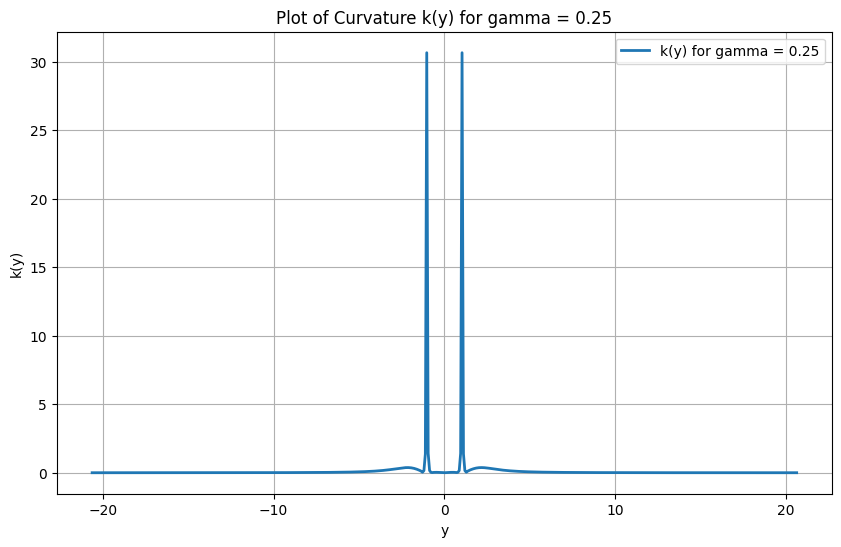

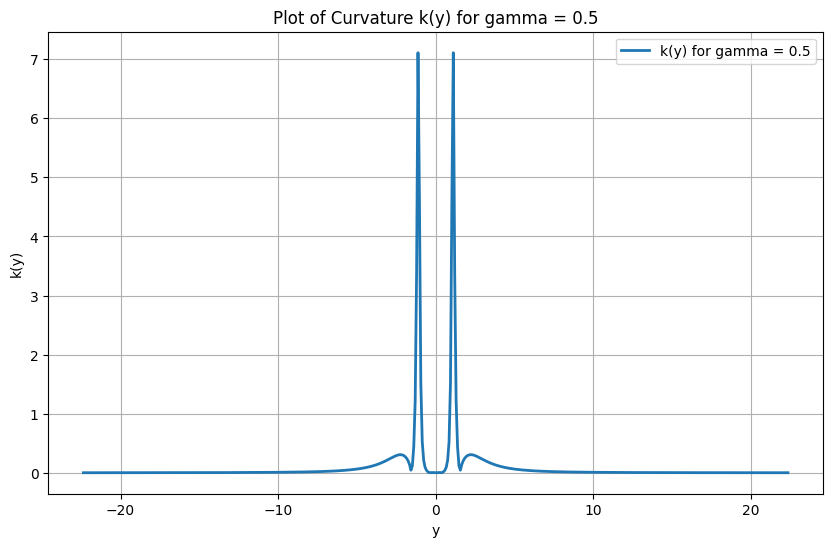

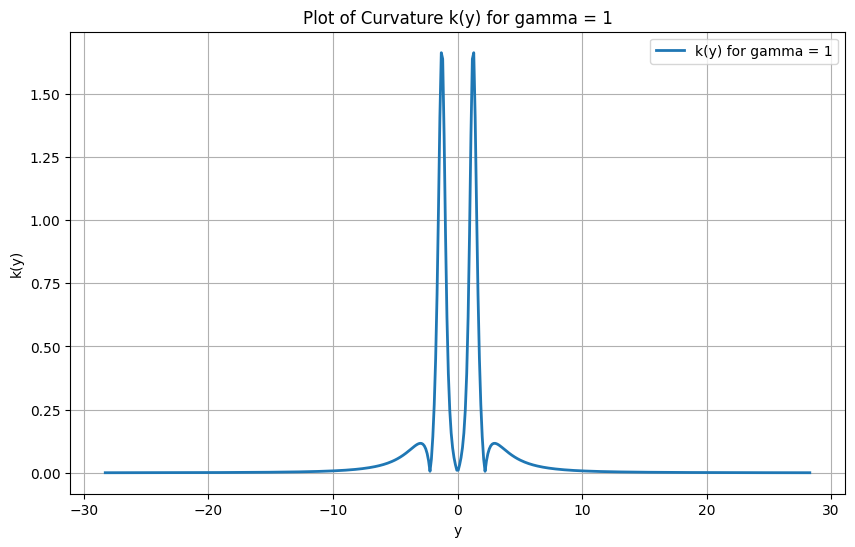

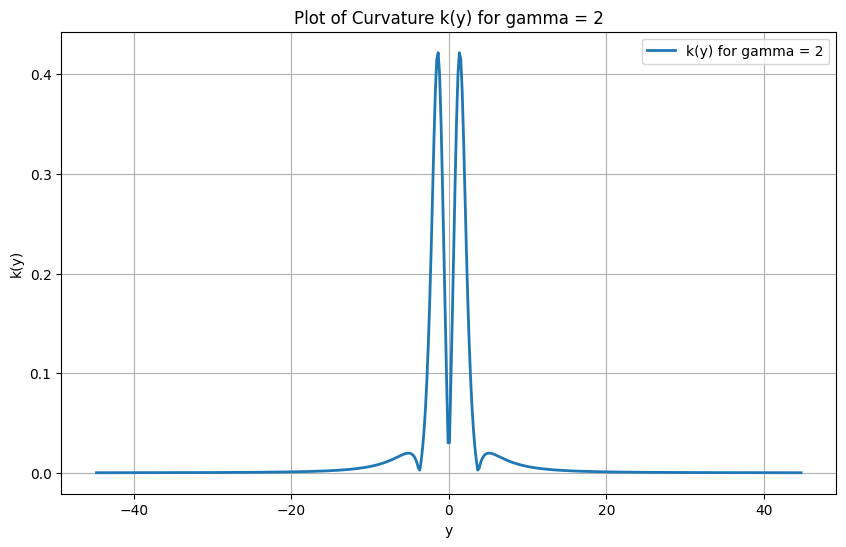

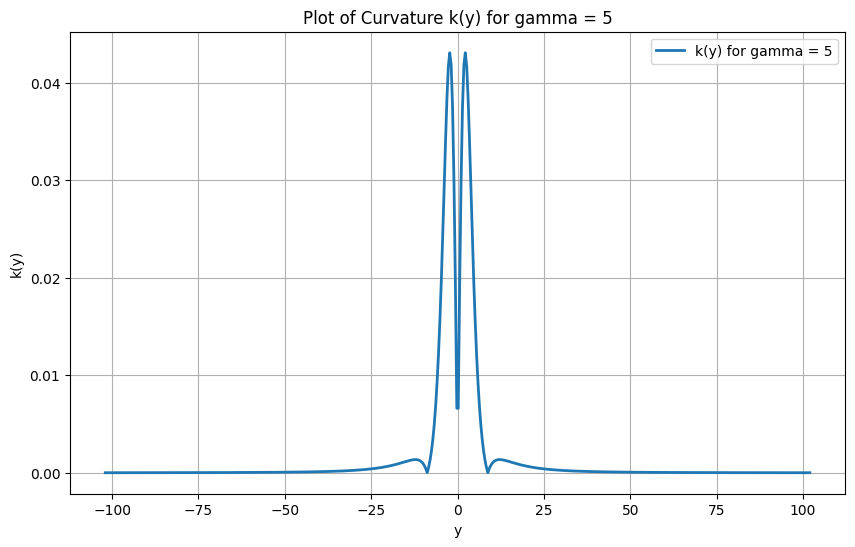

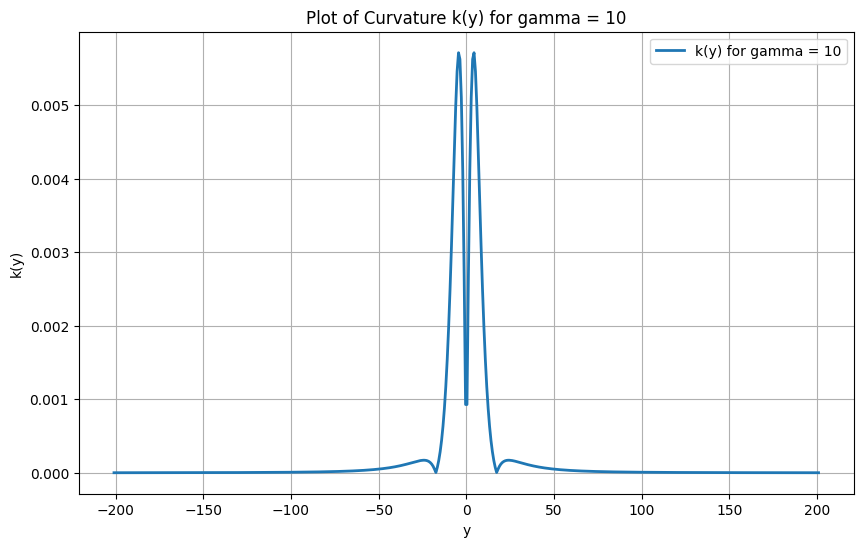

In [ ]:
# =========================================================================
# Geometric Curvature of the Cauchy LLR: k(y) = |L''(y)| / (1 + L'(y)^2)^(3/2)
#
# PURPOSE:
#   The curvature k(y) measures how sharply the LLR curve bends at each
#   point y.  Its local maxima identify the points of greatest geometric
#   bending — alternative candidates for piecewise linear breakpoints.
#
# FORMULA:
#   k(y) = |L''(y)| / (1 + (L'(y))^2)^(3/2)
#   where L'(y) and L''(y) are the first and second derivatives of the
#   Cauchy LLR L(y) = log(gamma^2+(y+1)^2) - log(gamma^2+(y-1)^2).
#
# INTERPRETATION:
#   A piecewise linear fit best approximates a smooth curve when breakpoints
#   are placed at or near its curvature peaks.  Comparing curvature-based
#   breakpoints against the slope-threshold breakpoints from cauchy_llr_approx.m
#   tests whether either approach is geometrically superior.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def L_function(y, gamma):
    """Calculates L(y) = log(gamma^2 + (y+1)^2) - log(gamma^2 + (y-1)^2)."""
    return np.log(gamma**2 + (y + 1)**2) - np.log(gamma**2 + (y - 1)**2)

def L_prime(y, gamma):
    """Calculates L'(y) = d/dy [L(y)]."""
    term1 = (2 * (y + 1)) / (gamma**2 + (y + 1)**2)
    term2 = (2 * (y - 1)) / (gamma**2 + (y - 1)**2)
    return term1 - term2

def L_double_prime(y, gamma):
    """Calculates L''(y) based on the given formula."""
    term1_numerator = 2 * gamma**2 - 2 * (y + 1)**2
    term1_denominator = (gamma**2 + (y + 1)**2)**2
    term1 = term1_numerator / term1_denominator

    term2_numerator = 2 * gamma**2 - 2 * (y - 1)**2
    term2_denominator = (gamma**2 + (y - 1)**2)**2
    term2 = term2_numerator / term2_denominator

    return term1 - term2

def curvature_k(y, gamma):
    """Calculates the curvature k(y) = |L''(y)| / ( (1 + (L'(y)^2))^(3/2) )."""
    L_prime_val = L_prime(y, gamma)
    L_double_prime_val = L_double_prime(y, gamma)
    return np.abs(L_double_prime_val) / ((1 + L_prime_val**2)**(3/2))

# Define gamma values
gamma_values = [0.25, 0.5, 1, 2, 5, 10]

for gamma_val in gamma_values:
    # Define a range for y values for plotting
    y_values = np.linspace(-20 * np.sqrt(1 + gamma_val**2), 20 * np.sqrt(1 + gamma_val**2), 500)

    # Calculate curvature values
    k_values = curvature_k(y_values, gamma_val)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(y_values, k_values, label=f'k(y) for gamma = {gamma_val}', linewidth=2)
    plt.xlabel('y')
    plt.ylabel('k(y)')
    plt.title(f'Plot of Curvature k(y) for gamma = {gamma_val}')
    plt.grid(True)
    plt.legend()
    plt.show()

##Finding k'(x)=0 numerically

In [ ]:
# (Empty cell — reserved for k'(y)=0 root-finding code)


Curvature peak for gamma=0.25 at x =1.0304892434471058
Curvature peak for gamma=0.5 at x =1.1153996947499596
Curvature peak for gamma=1 at x =1.4810123386404503
Curvature peak for gamma=2 at x =2.96371427265737
Curvature peak for gamma=5 at x =1.7721750561974383
Curvature peak for gamma=10 at x =3.407010441144251


For gamma = 0.25, k'(y)=0 root found at y = -2.162240
For gamma = 0.25, k'(y)=0 root found at y = 2.162240


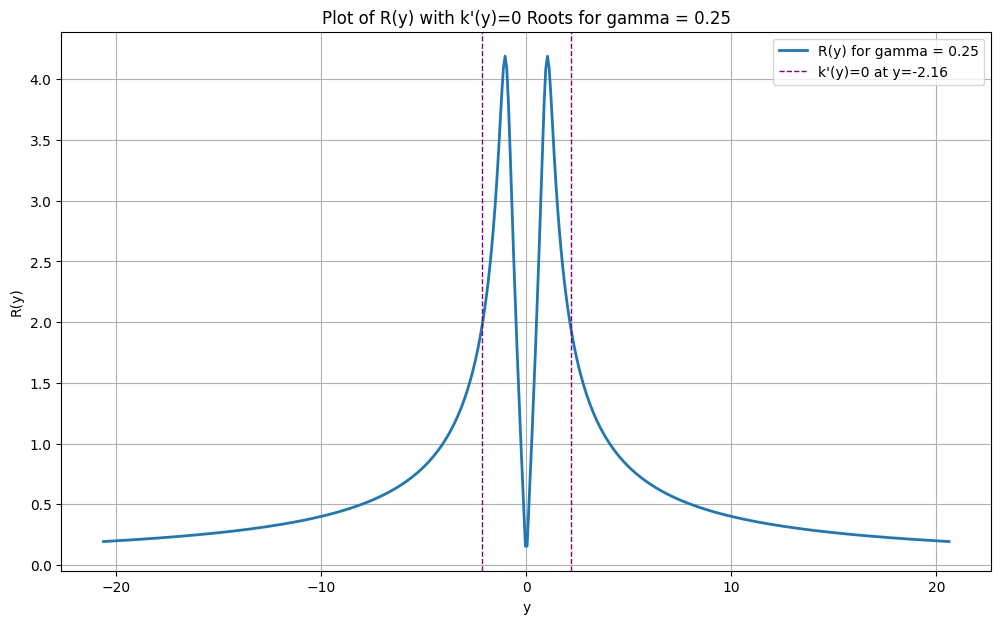

For gamma = 0.5, k'(y)=0 root found at y = -2.234059
For gamma = 0.5, k'(y)=0 root found at y = 2.234059


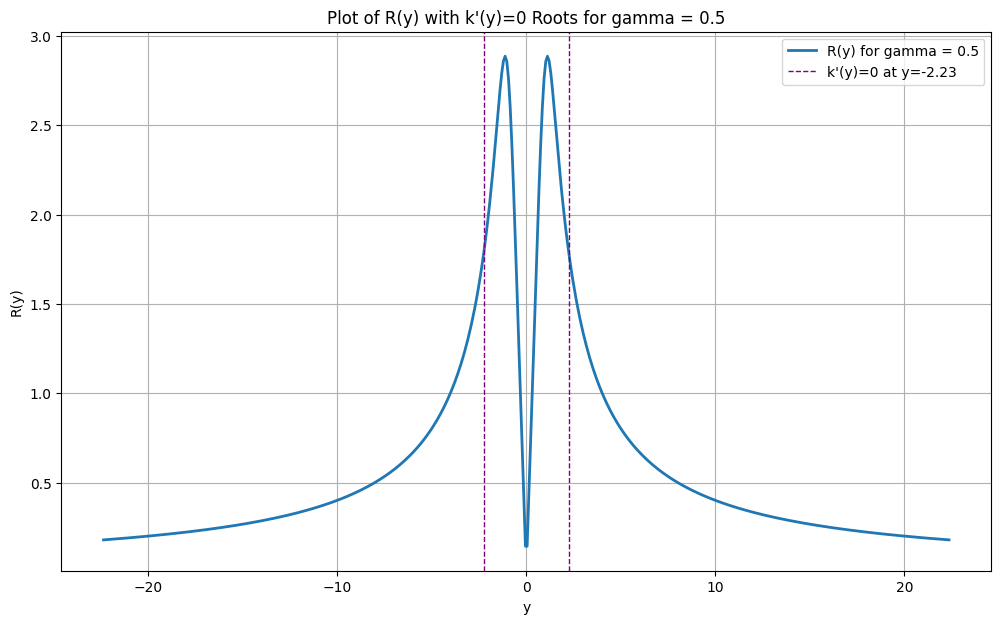

For gamma = 1, k'(y)=0 root found at y = -2.970981
For gamma = 1, k'(y)=0 root found at y = 2.970981


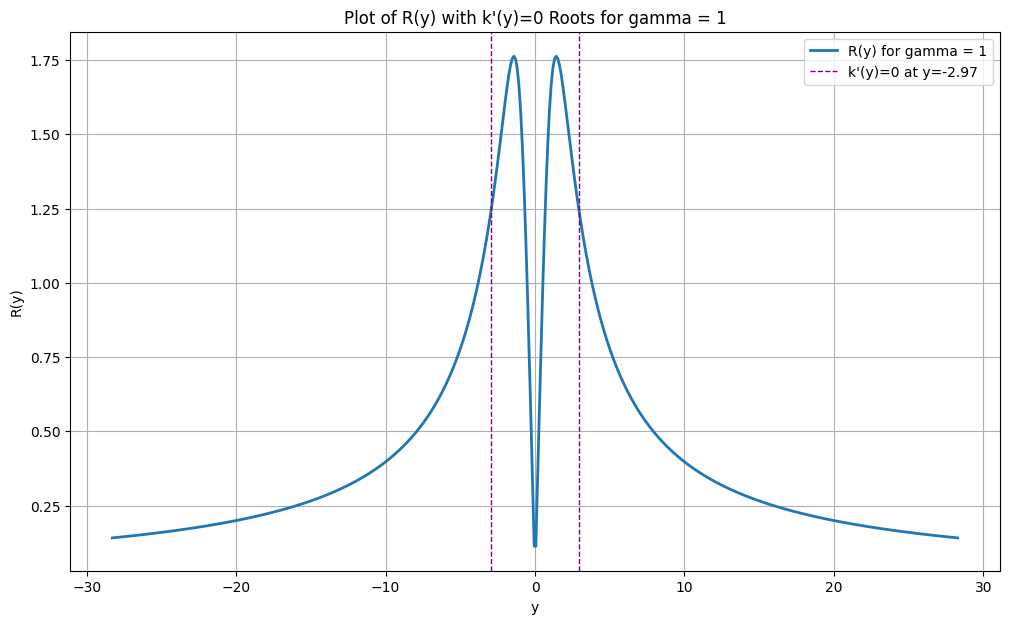

For gamma = 2, k'(y)=0 root found at y = -1.392036
For gamma = 2, k'(y)=0 root found at y = 1.392036


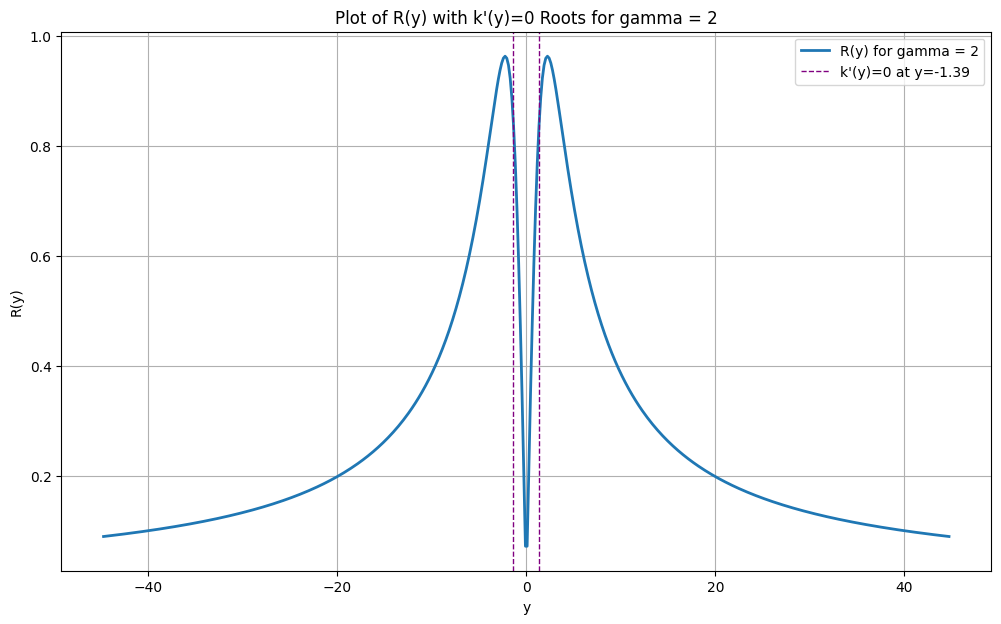

For gamma = 5, k'(y)=0 root found at y = -2.221386
For gamma = 5, k'(y)=0 root found at y = 2.221386


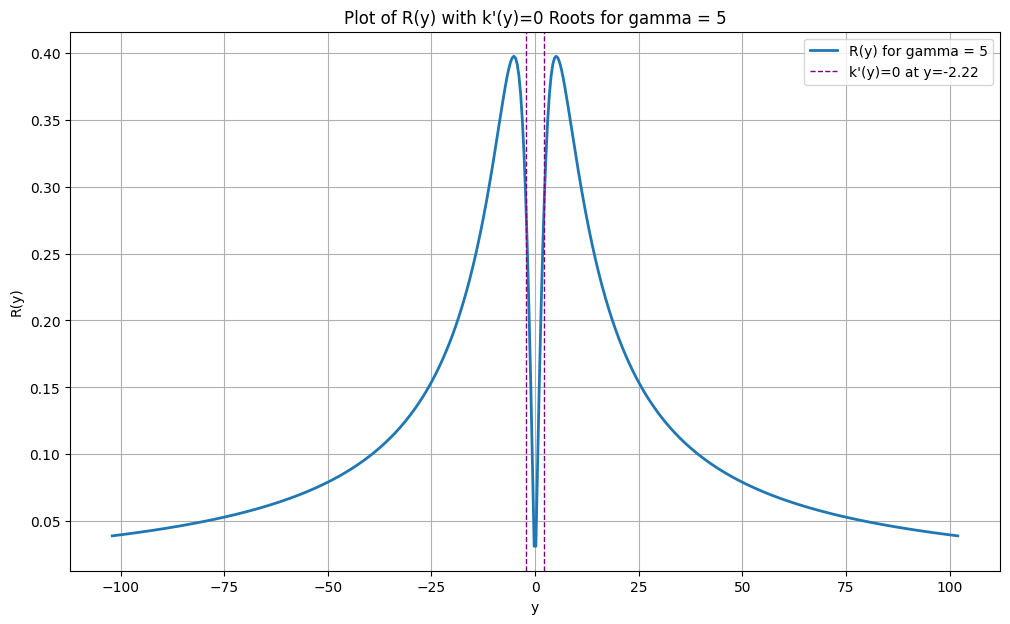

For gamma = 10, k'(y)=0 root found at y = -4.205300
For gamma = 10, k'(y)=0 root found at y = 4.205300


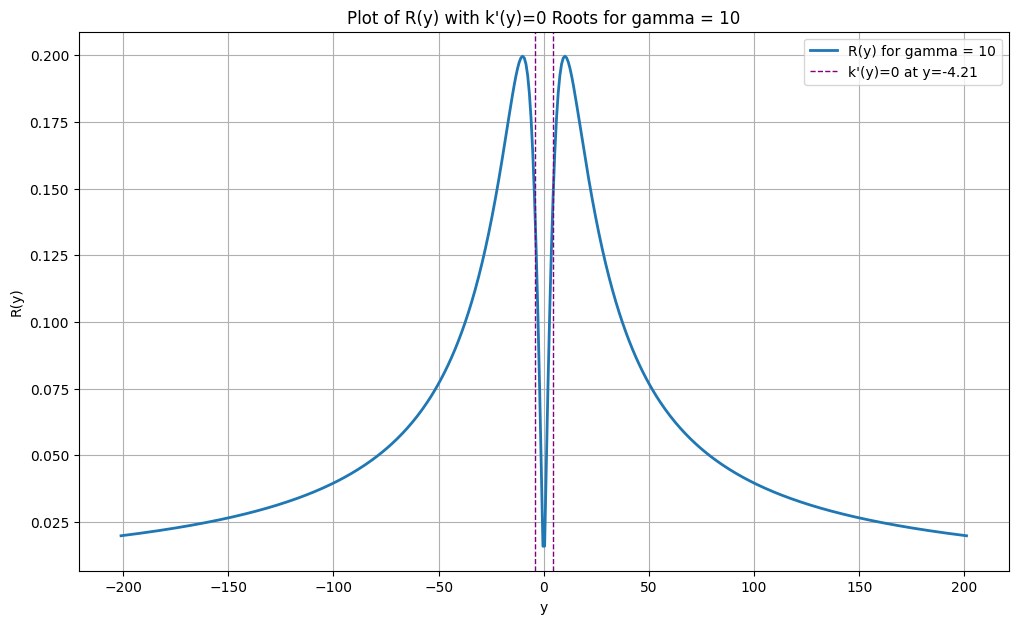

In [ ]:
# (Empty cell — reserved for k'(y)=0 root-finding code)


# Piecewise using thresholds

##t2=x where R'(x)=epsilon*R'(0)

<>:151: SyntaxWarning: invalid escape sequence '\e'
<>:151: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_9805/1008512357.py:151: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'3-Segment Piecewise Linear Fit for R(y) (γ={gamma_val}, $\epsilon$={epsilon})')


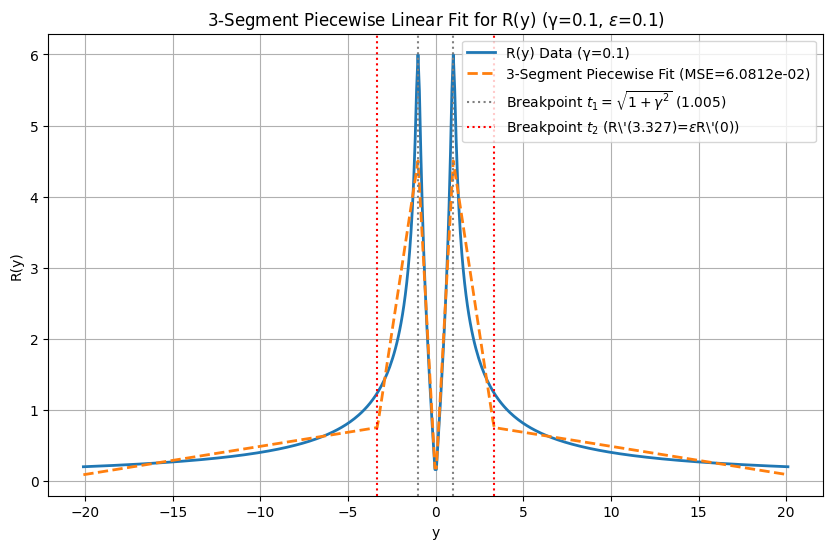


Gamma = 0.1
  Epsilon = 0.1
  First fixed breakpoint t1 = 1.0050
  Second breakpoint t2 (R'(t2)={epsilon}R'(0)) = 3.3266
  Segment 1 slope (0 to t1) = 4.4836
  Segment 2 slope (t1 to t2) = -1.6175
  Segment 3 slope (t2 onwards) = -0.0396
  Minimum MSE = 6.0812e-02


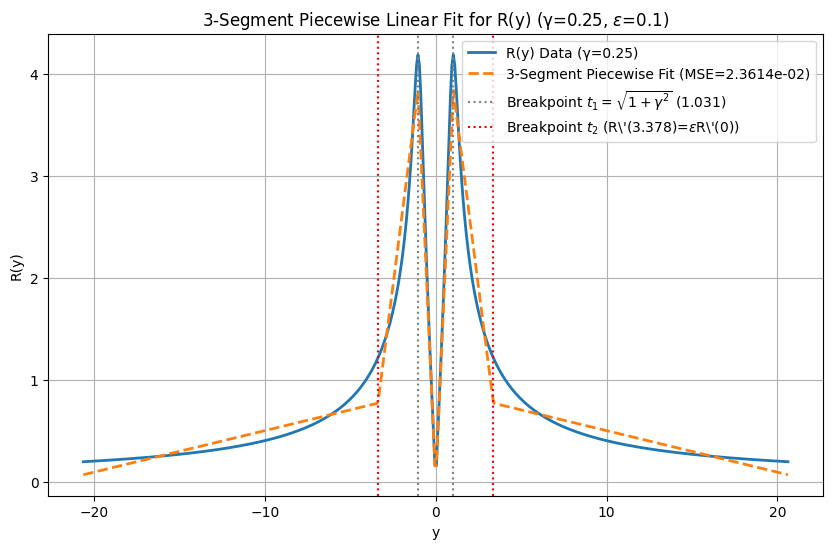


Gamma = 0.25
  Epsilon = 0.1
  First fixed breakpoint t1 = 1.0308
  Second breakpoint t2 (R'(t2)={epsilon}R'(0)) = 3.3781
  Segment 1 slope (0 to t1) = 3.7292
  Segment 2 slope (t1 to t2) = -1.3098
  Segment 3 slope (t2 onwards) = -0.0408
  Minimum MSE = 2.3614e-02


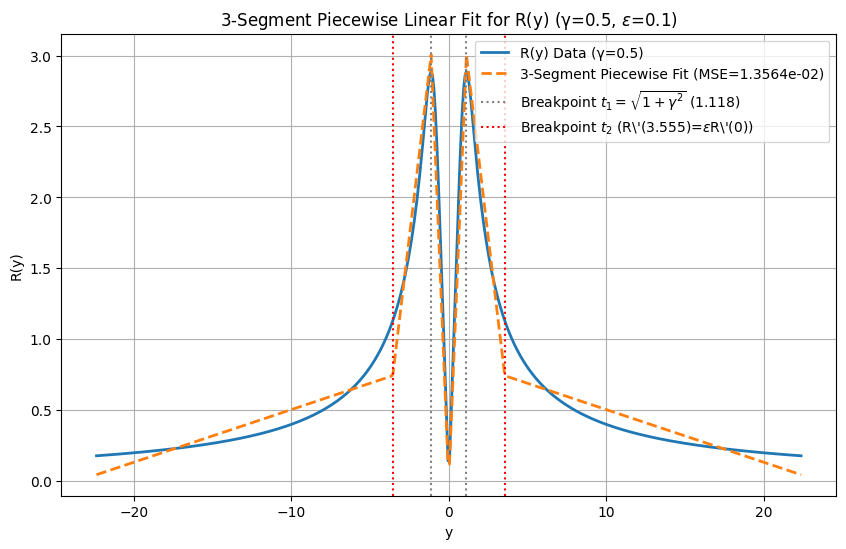


Gamma = 0.5
  Epsilon = 0.1
  First fixed breakpoint t1 = 1.1180
  Second breakpoint t2 (R'(t2)={epsilon}R'(0)) = 3.5553
  Segment 1 slope (0 to t1) = 2.6904
  Segment 2 slope (t1 to t2) = -0.9290
  Segment 3 slope (t2 onwards) = -0.0371
  Minimum MSE = 1.3564e-02


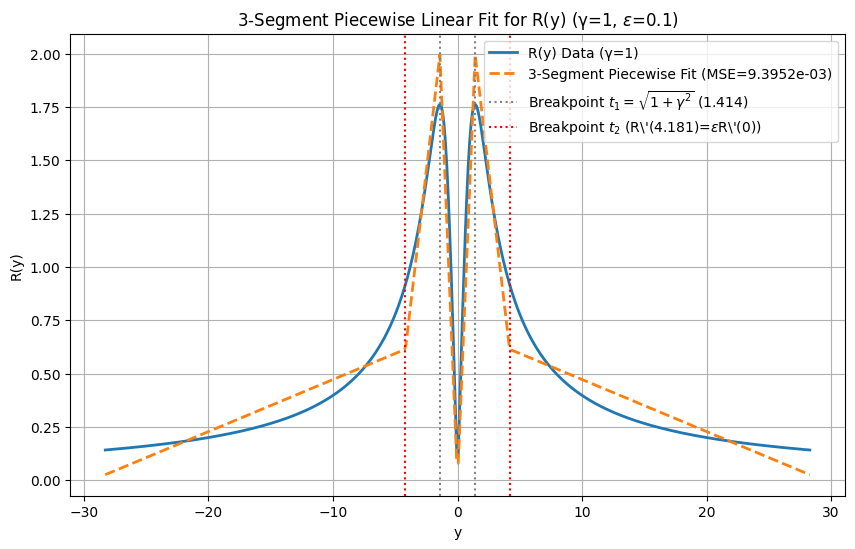


Gamma = 1
  Epsilon = 0.1
  First fixed breakpoint t1 = 1.4142
  Second breakpoint t2 (R'(t2)={epsilon}R'(0)) = 4.1813
  Segment 1 slope (0 to t1) = 1.4116
  Segment 2 slope (t1 to t2) = -0.4996
  Segment 3 slope (t2 onwards) = -0.0244
  Minimum MSE = 9.3952e-03


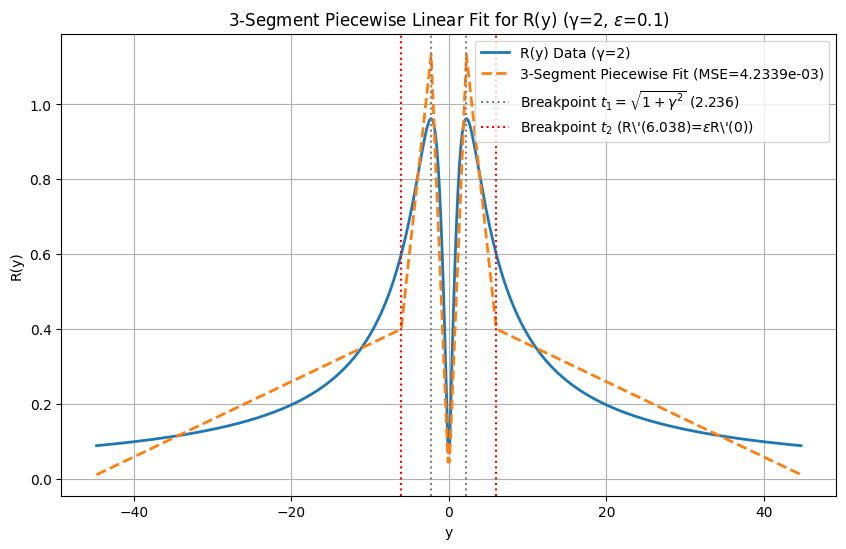


Gamma = 2
  Epsilon = 0.1
  First fixed breakpoint t1 = 2.2361
  Second breakpoint t2 (R'(t2)={epsilon}R'(0)) = 6.0379
  Segment 1 slope (0 to t1) = 0.5069
  Segment 2 slope (t1 to t2) = -0.1928
  Segment 3 slope (t2 onwards) = -0.0100
  Minimum MSE = 4.2339e-03


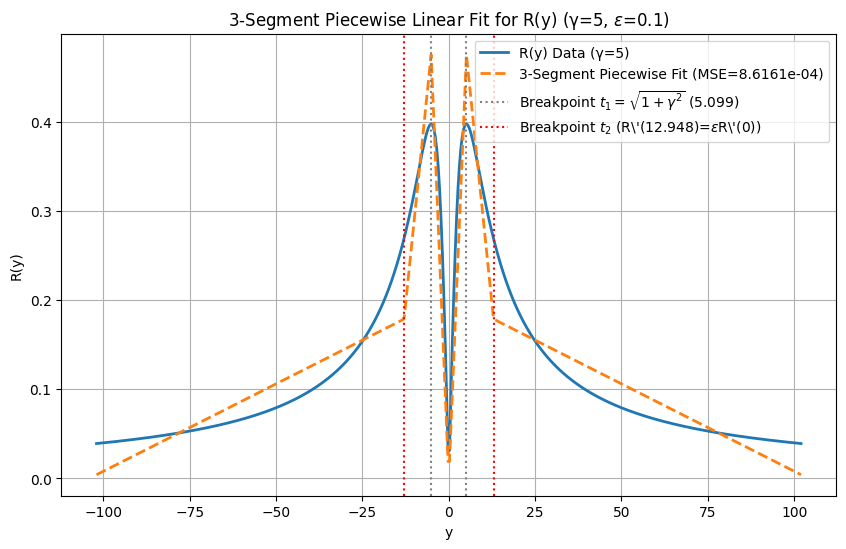


Gamma = 5
  Epsilon = 0.1
  First fixed breakpoint t1 = 5.0990
  Second breakpoint t2 (R'(t2)={epsilon}R'(0)) = 12.9477
  Segment 1 slope (0 to t1) = 0.0932
  Segment 2 slope (t1 to t2) = -0.0378
  Segment 3 slope (t2 onwards) = -0.0020
  Minimum MSE = 8.6161e-04


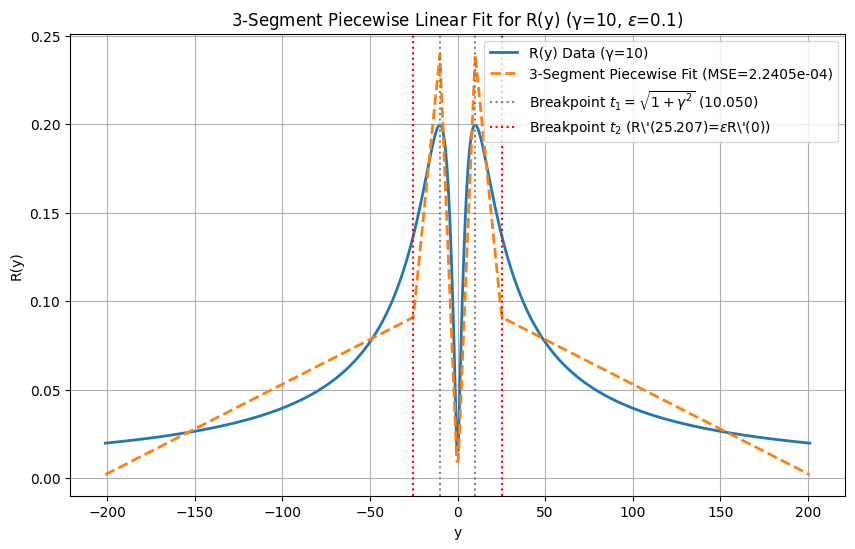


Gamma = 10
  Epsilon = 0.1
  First fixed breakpoint t1 = 10.0499
  Second breakpoint t2 (R'(t2)={epsilon}R'(0)) = 25.2072
  Segment 1 slope (0 to t1) = 0.0238
  Segment 2 slope (t1 to t2) = -0.0098
  Segment 3 slope (t2 onwards) = -0.0005
  Minimum MSE = 2.2405e-04


In [ ]:
# =========================================================================
# Piecewise Linear Fit with Analytically Motivated Breakpoints
#
# PURPOSE:
#   Uses ANALYTICALLY defined breakpoints (not a grid search) to fit the
#   3-segment piecewise linear approximation to R(y):
#
#     t1 = sqrt(1 + gamma^2)  [peak location — exact, from dR/dy = 0]
#
#     t2 = y where R'(y) = -epsilon * R'(0+)
#          where R'(0+) = 4/(1+gamma^2)  and  epsilon = 0.1
#          i.e. the tail where the descent rate has fallen to 10% of its
#          initial value.  This is the same criterion as in cauchy_llr_approx.m.
#
# NOTE ON SIGN:
#   For y > t1, R'(y) < 0.  The equation solved is:
#     -R'(y) = epsilon * R'(0+)  =>  R'(y) = -0.1 * 4/(1+gamma^2)
#   scipy.fsolve finds this crossing numerically.
#
# COEFFICIENTS:
#   Once t1 and t2 are fixed, [c1, c2, c3] are found by linear least squares
#   on the hinge design matrix A = [y, max(0,y-t1), max(0,y-t2)].
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)|."""
    arg1 = gamma**2 + (y + 1)**2
    arg2 = gamma**2 + (y - 1)**2
    return np.abs(np.log(arg1) - np.log(arg2))

def R_prime(y, gamma):
    """Calculates L'(y) = d/dy [log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)]."""
    term1 = (2 * (y + 1)) / (gamma**2 + (y + 1)**2)
    term2 = (2 * (y - 1)) / (gamma**2 + (y - 1)**2)
    return term1 - term2

def fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1, bp2):
    """
    Performs a three-segment continuous piecewise linear fit for y_data_pos >= 0
    with fixed breakpoints bp1 and bp2.
    The model is R(y) = c1*y + c2*max(0, y-bp1) + c3*max(0, y-bp2).
    """
    # Construct the design matrix for the entire positive data range
    A_matrix = np.column_stack([
        y_data_pos,
        np.maximum(0, y_data_pos - bp1),
        np.maximum(0, y_data_pos - bp2)
    ])

    # Check if A_matrix can be inverted (e.g., if there are enough distinct points for fitting)
    if A_matrix.shape[0] < A_matrix.shape[1]:
        return None

    # Check for ill-conditioned matrix or insufficient rank
    if np.linalg.matrix_rank(A_matrix) < A_matrix.shape[1]:
        return None

    try:
        # Use lstsq to solve for coefficients (c1, c2, c3)
        coeffs, residuals, rank, s = np.linalg.lstsq(A_matrix, r_data_pos, rcond=None)
    except np.linalg.LinAlgError:
        return None

    yhat_pos = A_matrix @ coeffs
    mse = np.mean((r_data_pos - yhat_pos)**2)

    return {
        "coeffs": coeffs, # (c1, c2, c3)
        "bp1": bp1,
        "bp2": bp2,
        "mse": mse,
        "yhat_pos": yhat_pos
    }

# --- Main execution ---

# Define gamma values to plot
gamma_values = [0.1, 0.25, 0.5, 1, 2, 5, 10]

epsilon = 0.1 # Fixed epsilon value as requested

for gamma_val in gamma_values:
    # Generate y_values over a broad symmetric range for plotting and fitting
    y_range_factor = 20
    y_max_for_fitting = y_range_factor * np.sqrt(1 + gamma_val**2)
    y_full = np.linspace(-y_max_for_fitting, y_max_for_fitting, 500)
    r_full_data = R_function(y_full, gamma_val)

    # Extract positive y_values for fitting (R(y) is symmetric)
    y_data_pos = y_full[y_full >= 0]
    r_data_pos = r_full_data[y_full >= 0]

    # --- Determine the first breakpoint t1 ---
    t1 = np.sqrt(1 + gamma_val**2)

    # --- Determine the second breakpoint t2 numerically ---
    # R_prime(0) for L(y) is 4 / (gamma^2 + 1)
    L_prime_at_0 = 4 / (gamma_val**2 + 1)
    target_R_prime_for_t2 = epsilon * L_prime_at_0

    # We are looking for t2 > t1. In this region, R(y) = -L(y), so R'(y) = -L'(y).
    # Objective function for fsolve: -L'(y) - target_R_prime_for_t2 = 0
    def objective_t2(y):
        # Ensure y is positive, as R_prime is defined for y > 0. For fsolve, push negative values away.
        if y <= t1:
             return 1e10 # A large positive value to push the root to positive y > t1
        return -R_prime(y, gamma_val) - target_R_prime_for_t2

    # Search range for t2 (must be greater than t1)
    t2_search_start = t1 + 1e-3 # Must be strictly greater than t1
    t2_search_end = y_max_for_fitting # Ensure t2 is within the data plotting range

    # Adjust search end if it's too close or before start
    if t2_search_end <= t2_search_start:
        t2_search_end = t2_search_start + 5 # Provide a reasonable range

    y_check_range_for_t2 = np.linspace(t2_search_start, t2_search_end, 100)
    # Check the actual function values of -L'(y) in the search range
    neg_L_prime_values_check_for_t2 = -R_prime(y_check_range_for_t2, gamma_val)

    t2 = None
    # Check if the target_R_prime_for_t2 is bracketed within the search range
    if np.any(neg_L_prime_values_check_for_t2 >= target_R_prime_for_t2) and np.any(neg_L_prime_values_check_for_t2 <= target_R_prime_for_t2):
        initial_guess_idx = np.argmin(np.abs(neg_L_prime_values_check_for_t2 - target_R_prime_for_t2))
        initial_guess_t2 = y_check_range_for_t2[initial_guess_idx]

        try:
            t2_found = fsolve(objective_t2, initial_guess_t2, maxfev=1000)[0]
            # Validate t2: must be positive, greater than t1, and within a reasonable upper bound
            if t2_found > t1 and t2_found < y_max_for_fitting * 1.5:
                t2 = t2_found
            else:
                print(f"Warning: fsolve found t2={t2_found:.4f} for gamma={gamma_val}, but it's not valid (t2 <= t1 or too large).")
        except Exception as e:
            print(f"Warning: fsolve failed for gamma={gamma_val} to find t2. Error: {e}")
    else:
        print(f"Warning: Target R_prime_for_t2={target_R_prime_for_t2:.4e} not bracketed in search range for gamma={gamma_val}.")

    if t2 is None:
        print(f"Skipping plot for gamma={gamma_val} as t2 could not be determined or validated.")
        continue

    # Ensure breakpoints are ordered for the fitting function (bp1 < bp2)
    bp1, bp2 = (t1, t2) if t1 < t2 else (t2, t1) # In this problem, t1 should always be < t2

    fit_results = fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1, bp2)

    if fit_results:
        c1, c2, c3 = fit_results["coeffs"]
        mse = fit_results["mse"]

        # Construct the full piecewise linear fit for plotting (symmetric)
        abs_y_full = np.abs(y_full)
        y_fit_full = c1 * abs_y_full + c2 * np.maximum(0, abs_y_full - bp1) + c3 * np.maximum(0, abs_y_full - bp2)

        # Clip negative values if any, as reliability cannot be negative
        y_fit_full = np.maximum(0, y_fit_full)

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.plot(y_full, r_full_data, label=f'R(y) Data (γ={gamma_val})', linewidth=2)
        plt.plot(y_full, y_fit_full, '--', label=f'3-Segment Piecewise Fit (MSE={mse:.4e})', linewidth=2)

        plt.axvline(bp1, color='gray', linestyle=':', label=rf'Breakpoint $t_1 = \sqrt{{1+\gamma^2}}$ ({bp1:.3f})')
        plt.axvline(bp2, color='red', linestyle=':', label=rf'Breakpoint $t_2$ (R\'({bp2:.3f})={epsilon}R\'({0:.0f}))')
        plt.axvline(-bp1, color='gray', linestyle=':') # Symmetric breakpoint
        plt.axvline(-bp2, color='red', linestyle=':') # Symmetric breakpoint

        plt.xlabel('y')
        plt.ylabel('R(y)')
        plt.title(f'3-Segment Piecewise Linear Fit for R(y) (γ={gamma_val}, $\epsilon$={epsilon})')
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"\nGamma = {gamma_val:.3g}")
        print(f"  Epsilon = {epsilon}")
        print(f"  First fixed breakpoint t1 = {bp1:.4f}")
        print(f"  Second breakpoint t2 (R'(t2)={{epsilon}}R'(0)) = {bp2:.4f}")
        print(f"  Segment 1 slope (0 to t1) = {c1:.4f}")
        print(f"  Segment 2 slope (t1 to t2) = {(c1 + c2):.4f}")
        print(f"  Segment 3 slope (t2 onwards) = {(c1 + c2 + c3):.4f}")
        print(f"  Minimum MSE = {mse:.4e}")
    else:
        print(f"\nCould not find a valid fit for Gamma = {gamma_val}. Check warnings above.")

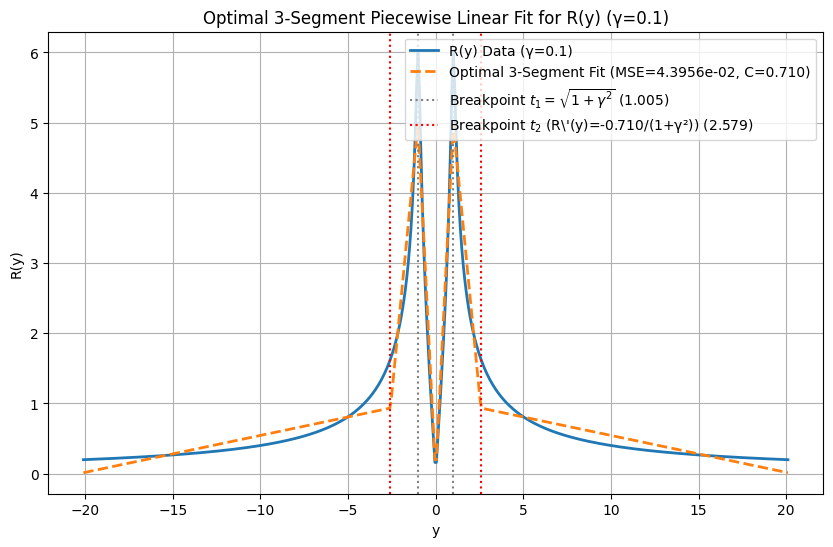


Gamma = 0.1
  Optimal C found = 0.7100
  First fixed breakpoint bp1 = 1.0050
  Optimal second breakpoint bp2 = 2.5793
  Effective slope for y in (0, bp1) = 4.9611
  Effective slope for y in (bp1, bp2) = -2.5731
  Effective slope for y in (bp2, ymax) = -0.0526
  Minimum MSE = 4.3956e-02


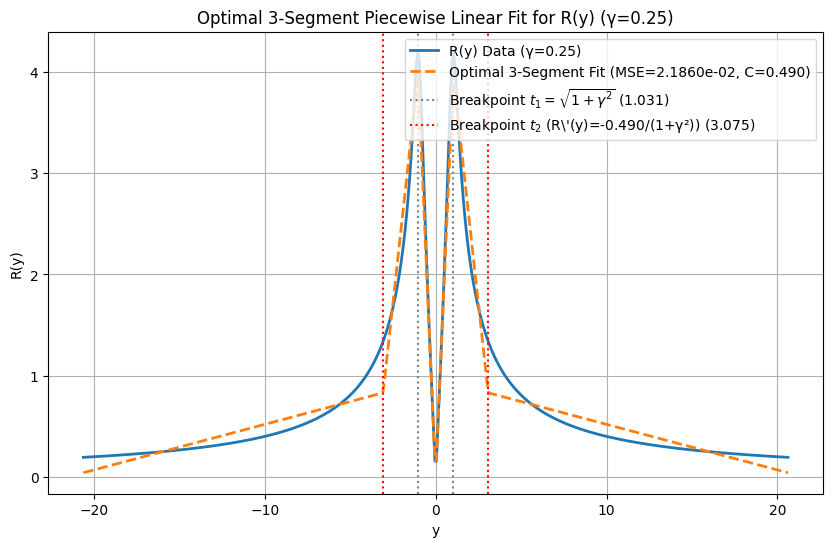


Gamma = 0.25
  Optimal C found = 0.4900
  First fixed breakpoint bp1 = 1.0308
  Optimal second breakpoint bp2 = 3.0748
  Effective slope for y in (0, bp1) = 3.8558
  Effective slope for y in (bp1, bp2) = -1.5376
  Effective slope for y in (bp2, ymax) = -0.0450
  Minimum MSE = 2.1860e-02


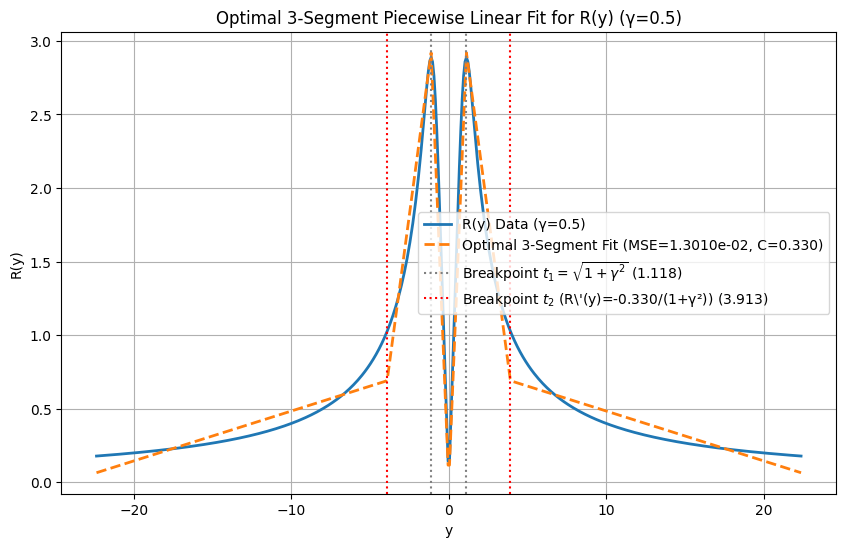


Gamma = 0.5
  Optimal C found = 0.3300
  First fixed breakpoint bp1 = 1.1180
  Optimal second breakpoint bp2 = 3.9131
  Effective slope for y in (0, bp1) = 2.6128
  Effective slope for y in (bp1, bp2) = -0.7980
  Effective slope for y in (bp2, ymax) = -0.0339
  Minimum MSE = 1.3010e-02


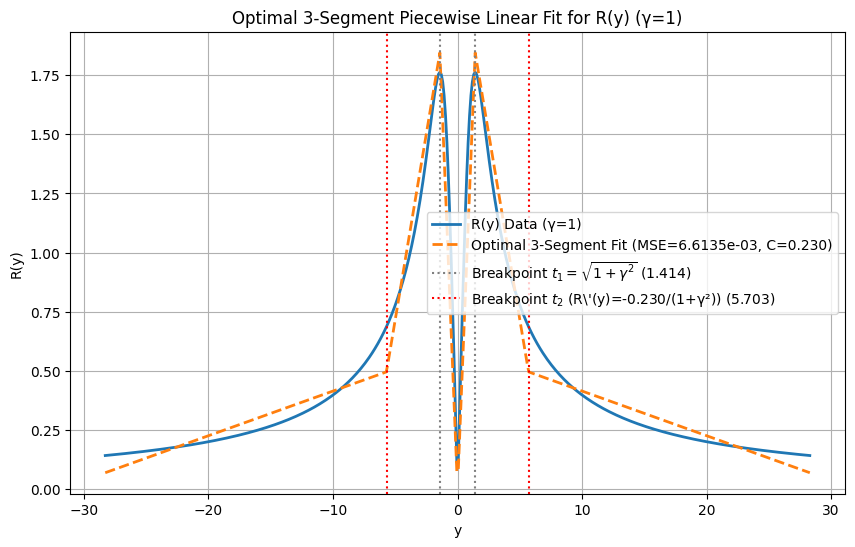


Gamma = 1
  Optimal C found = 0.2300
  First fixed breakpoint bp1 = 1.4142
  Optimal second breakpoint bp2 = 5.7027
  Effective slope for y in (0, bp1) = 1.3053
  Effective slope for y in (bp1, bp2) = -0.3150
  Effective slope for y in (bp2, ymax) = -0.0189
  Minimum MSE = 6.6135e-03


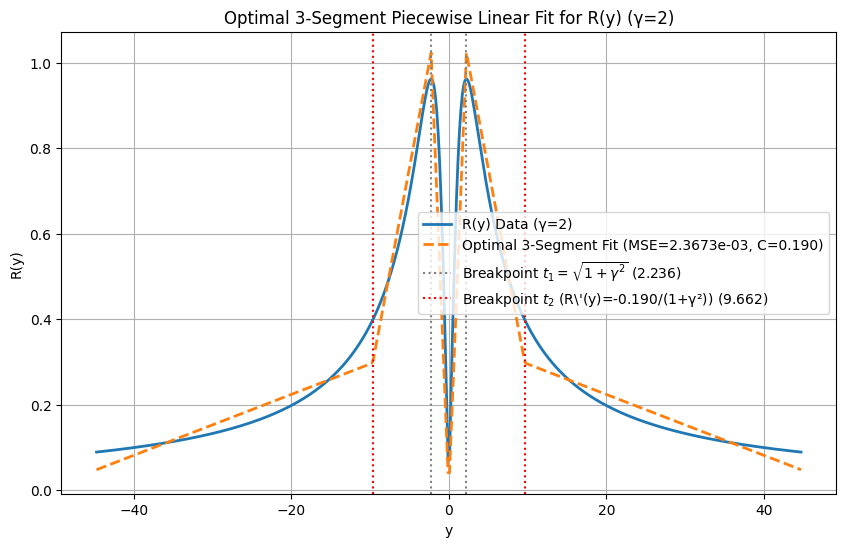


Gamma = 2
  Optimal C found = 0.1900
  First fixed breakpoint bp1 = 2.2361
  Optimal second breakpoint bp2 = 9.6622
  Effective slope for y in (0, bp1) = 0.4578
  Effective slope for y in (bp1, bp2) = -0.0978
  Effective slope for y in (bp2, ymax) = -0.0071
  Minimum MSE = 2.3673e-03


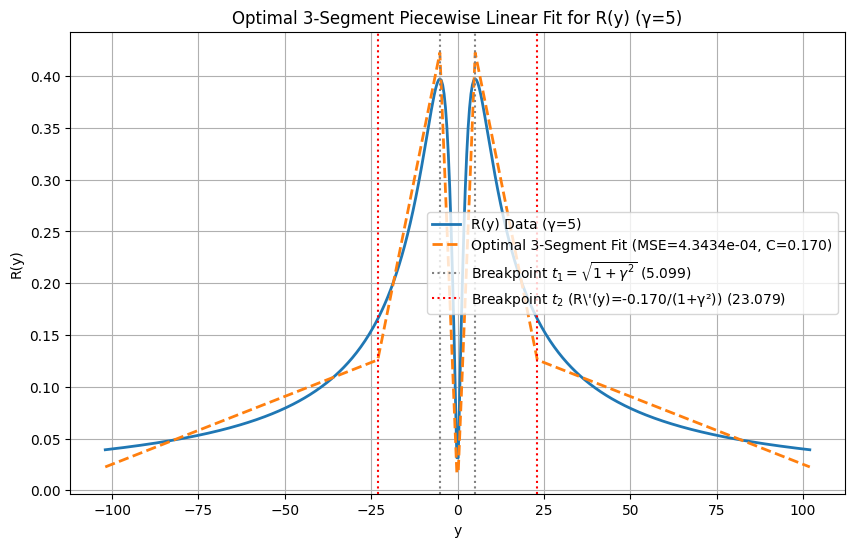


Gamma = 5
  Optimal C found = 0.1700
  First fixed breakpoint bp1 = 5.0990
  Optimal second breakpoint bp2 = 23.0788
  Effective slope for y in (0, bp1) = 0.0829
  Effective slope for y in (bp1, bp2) = -0.0165
  Effective slope for y in (bp2, ymax) = -0.0013
  Minimum MSE = 4.3434e-04


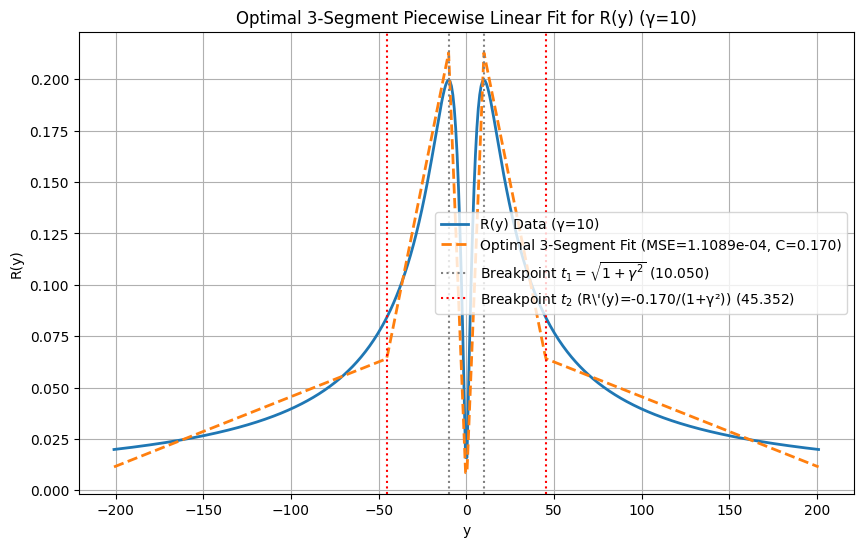


Gamma = 10
  Optimal C found = 0.1700
  First fixed breakpoint bp1 = 10.0499
  Optimal second breakpoint bp2 = 45.3521
  Effective slope for y in (0, bp1) = 0.0212
  Effective slope for y in (bp1, bp2) = -0.0042
  Effective slope for y in (bp2, ymax) = -0.0003
  Minimum MSE = 1.1089e-04


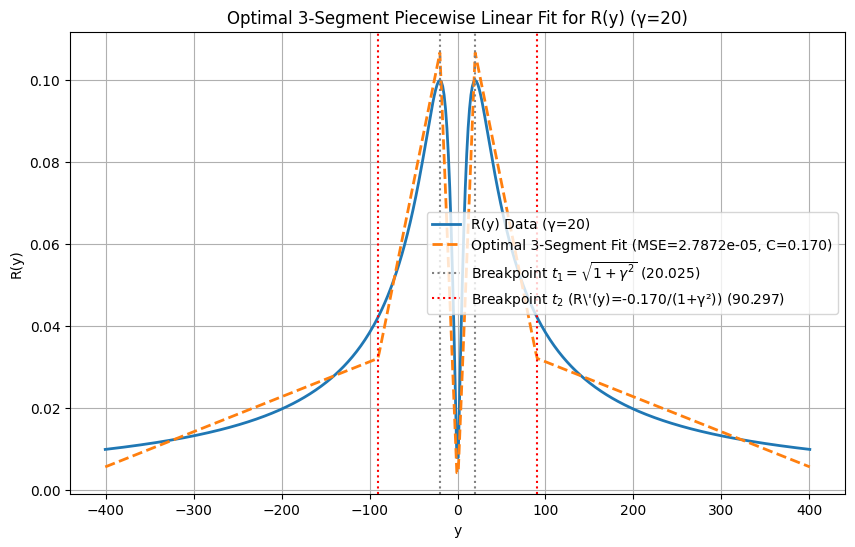


Gamma = 20
  Optimal C found = 0.1700
  First fixed breakpoint bp1 = 20.0250
  Optimal second breakpoint bp2 = 90.2969
  Effective slope for y in (0, bp1) = 0.0053
  Effective slope for y in (bp1, bp2) = -0.0011
  Effective slope for y in (bp2, ymax) = -0.0001
  Minimum MSE = 2.7872e-05


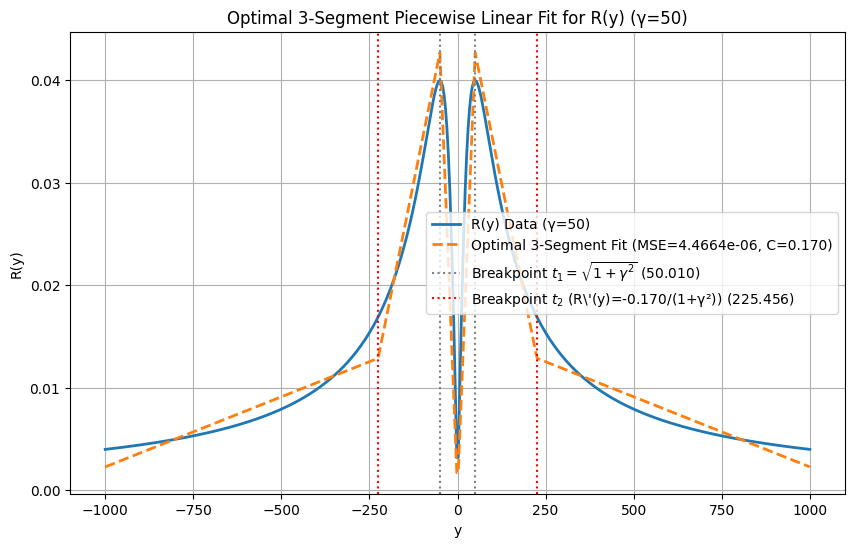


Gamma = 50
  Optimal C found = 0.1700
  First fixed breakpoint bp1 = 50.0100
  Optimal second breakpoint bp2 = 225.4564
  Effective slope for y in (0, bp1) = 0.0009
  Effective slope for y in (bp1, bp2) = -0.0002
  Effective slope for y in (bp2, ymax) = -0.0000
  Minimum MSE = 4.4664e-06


In [ ]:
# =========================================================================
# Optimal C Search: Best Slope Threshold for the Second Breakpoint
#
# PURPOSE:
#   Generalises the epsilon=0.1 threshold to an optimised value C.
#   The second breakpoint t2 is defined as the y where:
#     R'(y) = -C / (1 + gamma^2)
#   The constant C is swept over 50 values in [0.01, 0.99] and the C
#   minimising the least-squares MSE of the 3-segment fit is selected.
#
# RELATIONSHIP TO cauchy_llr_approx.m:
#   The MATLAB implementation uses C = epsilon * 4/(1+gamma^2) * (1+gamma^2)/4
#   = epsilon = 0.1 (fixed).  This Python cell checks whether that fixed
#   value is near-optimal or whether a gamma-dependent C would improve the fit.
#
# OUTPUTS:
#   Per gamma: optimal C, breakpoints bp1 and bp2, effective slopes,
#   and minimum MSE.  Also produces a plot of optimal C vs gamma.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)|."""
    arg1 = gamma**2 + (y + 1)**2
    arg2 = gamma**2 + (y - 1)**2
    return np.abs(np.log(arg1) - np.log(arg2))

def R_prime(y, gamma):
    """Calculates R'(y) for y > 0."""
    # For y > 0, R(y) = log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)
    term1 = (2 * (y + 1)) / (gamma**2 + (y + 1)**2)
    term2 = (2 * (y - 1)) / (gamma**2 + (y - 1)**2)
    return term1 - term2

def fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1, bp2):
    """
    Performs a three-segment continuous piecewise linear fit for y_data_pos >= 0
    with fixed breakpoints bp1 and bp2.
    The model is: R(y) = c1*y + c2*max(0, y-bp1) + c3*max(0, y-bp2).
    This formulation ensures continuity and allows for fitting parameters (c1, c2, c3)
    regardless of the order of bp1 and bp2.
    """
    # Construct the design matrix for the entire positive data range
    A_matrix = np.column_stack([
        y_data_pos,
        np.maximum(0, y_data_pos - bp1),
        np.maximum(0, y_data_pos - bp2)
    ])

    # Check if A_matrix can be inverted (e.g., if there are enough distinct points for fitting)
    if A_matrix.shape[0] < A_matrix.shape[1]:
        #print("Warning: Not enough data points for a 3-segment fit. Skipping.")
        return None

    try:
        coeffs, residuals, rank, s = np.linalg.lstsq(A_matrix, r_data_pos, rcond=None)
        c1, c2, c3 = coeffs
    except np.linalg.LinAlgError:
        #print("Warning: Linear least squares failed. Skipping.")
        return None

    yhat_pos = A_matrix @ coeffs
    mse = np.mean((r_data_pos - yhat_pos)**2)

    return {
        "coeffs": coeffs, # (c1, c2, c3)
        "bp1": bp1,
        "bp2": bp2,
        "mse": mse,
        "yhat_pos": yhat_pos
    }

# --- Main execution ---
# Define gamma values to plot
gamma_values = [0.1, 0.25, 0.5, 1, 2, 5, 10, 20, 50]
# Define C values to test for optimization (0 < C < 1)
C_test_values = np.linspace(0.01, 0.99, 50) # Test 50 values between 0.01 and 0.99

for gamma_val in gamma_values:
    # Generate y_values over a broad symmetric range
    y_full = np.linspace(-20 * np.sqrt(1 + gamma_val**2), 20 * np.sqrt(1 + gamma_val**2), 500)
    r_full_data = R_function(y_full, gamma_val)

    # Extract positive y_values for fitting
    y_data_pos = y_full[y_full >= 0]
    r_data_pos = r_full_data[y_full >= 0]

    # Define the first fixed breakpoint
    bp1_fixed = np.sqrt(1 + gamma_val**2)

    min_mse = np.inf
    best_C = None
    best_fit_results = None

    for C in C_test_values:
        target_slope_bp2 = -C / (1 + gamma_val**2)

        # Function to find the root of R_prime(y) - target_slope = 0
        def objective_bp2(y):
            return R_prime(y, gamma_val) - target_slope_bp2

        # Sample a range after bp1_fixed for checking R_prime values
        y_check_range = np.linspace(bp1_fixed + 0.001, 20 * bp1_fixed, 100)
        rp_values_check = R_prime(y_check_range, gamma_val)

        current_bp2_fixed = bp1_fixed + 0.001 # Default fallback, ensures bp2 > bp1

        # Check if target is bracketed
        if np.any(rp_values_check <= target_slope_bp2) and np.any(rp_values_check >= target_slope_bp2):
            try:
                initial_guess_idx = np.argmin(np.abs(rp_values_check - target_slope_bp2))
                initial_guess_bp2 = y_check_range[initial_guess_idx]

                bp2_found = fsolve(objective_bp2, initial_guess_bp2)[0]
                if bp2_found > bp1_fixed and bp2_found > 0:
                    current_bp2_fixed = bp2_found
                # else: fsolve found a bad root, stick to default or previous current_bp2_fixed
            except Exception as e:
                # fsolve failed, stick to current_bp2_fixed (bp1_fixed + epsilon)
                pass
        # else: target not bracketed, current_bp2_fixed (bp1_fixed + epsilon) remains

        fit_results = fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1_fixed, current_bp2_fixed)

        if fit_results and fit_results["mse"] < min_mse:
            min_mse = fit_results["mse"]
            best_C = C
            best_fit_results = fit_results

    if best_fit_results: # If a valid fit was found for this gamma_val
        c1, c2, c3 = best_fit_results["coeffs"]
        bp1 = best_fit_results["bp1"]
        bp2 = best_fit_results["bp2"]
        mse = best_fit_results["mse"]

        y_fit_full = c1 * np.abs(y_full) + c2 * np.maximum(0, np.abs(y_full) - bp1) + c3 * np.maximum(0, np.abs(y_full) - bp2)

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.plot(y_full, r_full_data, label=f'R(y) Data (γ={gamma_val})', linewidth=2)
        plt.plot(y_full, y_fit_full, '--', label=f'Optimal 3-Segment Fit (MSE={mse:.4e}, C={best_C:.3f})', linewidth=2)

        plt.axvline(bp1, color='gray', linestyle=':', label=rf'Breakpoint $t_1 = \sqrt{{1+\gamma^2}}$ ({bp1:.3f})')
        # Using best_C to label the dynamic breakpoint
        plt.axvline(bp2, color='red', linestyle=':', label=rf'Breakpoint $t_2$ (R\'(y)=-{best_C:.3f}/(1+γ²)) ({bp2:.3f})')
        plt.axvline(-bp1, color='gray', linestyle=':') # Symmetric breakpoint
        plt.axvline(-bp2, color='red', linestyle=':') # Symmetric breakpoint

        plt.xlabel('y')
        plt.ylabel('R(y)')
        plt.title(f'Optimal 3-Segment Piecewise Linear Fit for R(y) (γ={gamma_val})')
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"\nGamma = {gamma_val:.3g}")
        print(f"  Optimal C found = {best_C:.4f}")
        print(f"  First fixed breakpoint bp1 = {bp1:.4f}")
        print(f"  Optimal second breakpoint bp2 = {bp2:.4f}")

        print(f"  Effective slope for y in (0, bp1) = {c1:.4f}")
        print(f"  Effective slope for y in (bp1, bp2) = {c1 + c2:.4f}")
        print(f"  Effective slope for y in (bp2, ymax) = {c1 + c2 + c3:.4f}")

        print(f"  Minimum MSE = {mse:.4e}")
    else:
        print(f"\nCould not find a valid optimal fit for Gamma = {gamma_val}. ")


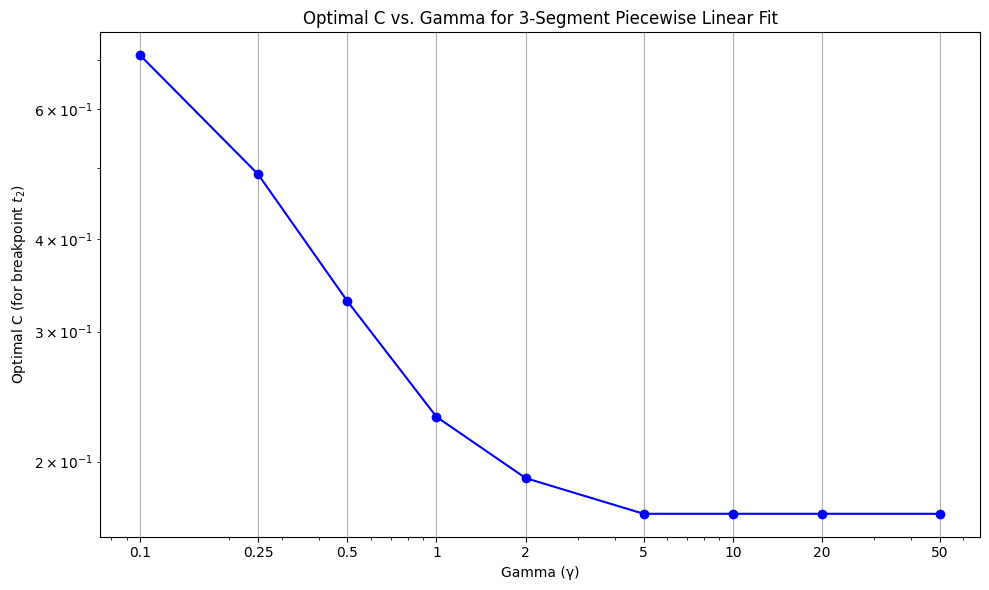

In [ ]:
# =========================================================================
# Collect Optimal C per Gamma and Plot C vs gamma
#
# PURPOSE:
#   Runs the optimal-C sweep from the previous cell across all gamma values
#   and plots the optimal C as a function of gamma on log-log axes.
#   If the optimal C is approximately constant across gamma, then the
#   epsilon=0.1 fixed threshold in cauchy_llr_approx.m is justified.
#   If C varies significantly with gamma, a gamma-dependent threshold would
#   give a better fit.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)|."""
    arg1 = gamma**2 + (y + 1)**2
    arg2 = gamma**2 + (y - 1)**2
    return np.abs(np.log(arg1) - np.log(arg2))

def R_prime(y, gamma):
    """Calculates R'(y) for y > 0."""
    # For y > 0, R(y) = log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)
    term1 = (2 * (y + 1)) / (gamma**2 + (y + 1)**2)
    term2 = (2 * (y - 1)) / (gamma**2 + (y - 1)**2)
    return term1 - term2

def fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1, bp2):
    """
    Performs a three-segment continuous piecewise linear fit for y_data_pos >= 0
    with fixed breakpoints bp1 and bp2.
    """
    A_matrix = np.column_stack([
        y_data_pos,
        np.maximum(0, y_data_pos - bp1),
        np.maximum(0, y_data_pos - bp2)
    ])

    if A_matrix.shape[0] < A_matrix.shape[1]:
        return None

    try:
        coeffs, residuals, rank, s = np.linalg.lstsq(A_matrix, r_data_pos, rcond=None)
    except np.linalg.LinAlgError:
        return None

    yhat_pos = A_matrix @ coeffs
    mse = np.mean((r_data_pos - yhat_pos)**2)

    return {
        "coeffs": coeffs,
        "bp1": bp1,
        "bp2": bp2,
        "mse": mse,
        "yhat_pos": yhat_pos
    }

# --- Collect data for plotting ---

gamma_values = [0.1, 0.25, 0.5, 1, 2, 5, 10, 20, 50]
C_test_values = np.linspace(0.01, 0.99, 50)

optimal_C_per_gamma = []

for gamma_val in gamma_values:
    y_full = np.linspace(-20 * np.sqrt(1 + gamma_val**2), 20 * np.sqrt(1 + gamma_val**2), 500)
    r_full_data = R_function(y_full, gamma_val)

    y_data_pos = y_full[y_full >= 0]
    r_data_pos = r_full_data[y_full >= 0]

    bp1_fixed = np.sqrt(1 + gamma_val**2)

    min_mse = np.inf
    best_C = None

    for C in C_test_values:
        target_slope_bp2 = -C / (1 + gamma_val**2)

        def objective_bp2(y):
            return R_prime(y, gamma_val) - target_slope_bp2

        y_check_range = np.linspace(bp1_fixed + 0.001, 20 * bp1_fixed, 100)
        rp_values_check = R_prime(y_check_range, gamma_val)

        current_bp2_fixed = bp1_fixed + 0.001

        if np.any(rp_values_check <= target_slope_bp2) and np.any(rp_values_check >= target_slope_bp2):
            try:
                initial_guess_idx = np.argmin(np.abs(rp_values_check - target_slope_bp2))
                initial_guess_bp2 = y_check_range[initial_guess_idx]
                bp2_found = fsolve(objective_bp2, initial_guess_bp2)[0]
                if bp2_found > bp1_fixed and bp2_found > 0:
                    current_bp2_fixed = bp2_found
            except Exception as e:
                pass

        fit_results = fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1_fixed, current_bp2_fixed)

        if fit_results and fit_results["mse"] < min_mse:
            min_mse = fit_results["mse"]
            best_C = C

    if best_C is not None:
        optimal_C_per_gamma.append((gamma_val, best_C))

# Separate gamma values and optimal C values for plotting
gammas_for_plot = [item[0] for item in optimal_C_per_gamma]
optimal_Cs_for_plot = [item[1] for item in optimal_C_per_gamma]

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(gammas_for_plot, optimal_Cs_for_plot, marker='o', linestyle='-', color='blue')
plt.xlabel('Gamma (γ)')
plt.ylabel('Optimal C (for breakpoint $t_2$)')
plt.title('Optimal C vs. Gamma for 3-Segment Piecewise Linear Fit')
plt.grid(True)
plt.xscale('log') # Gamma values span a wide range, log scale can be useful
plt.yscale('log')
plt.xticks(gammas_for_plot, labels=[str(g) for g in gammas_for_plot]) # Show original gamma ticks
plt.tight_layout()
plt.show()

##Comparison

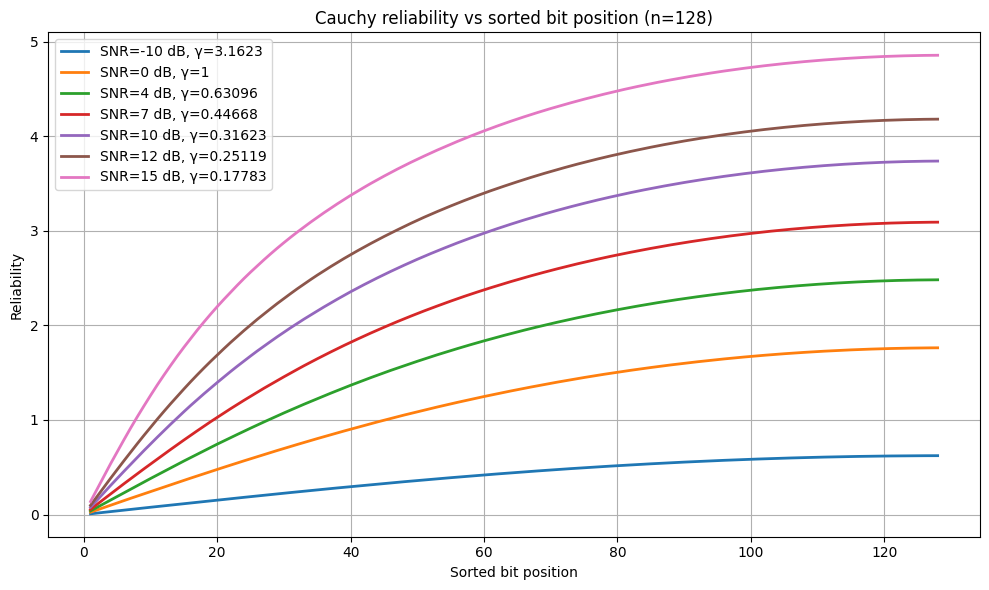

{-10: {'gamma': 3.1622776601683795,
  'x': array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
          14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
          27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
          40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
          53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
          66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
          79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
          92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
         105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
         118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128]),
  'Gamma_mean': array([0.00775853, 0.01554913, 0.0232688 , 0.03094857, 0.03865374,
         0.04636397, 0.05394567, 0.06162029, 0.06918238, 0.07683984,
         0.08440732, 0.0919951 , 0.09956696, 0.10721194, 0.11476675,
      

In [ ]:
# =========================================================================
# Cauchy Reliability Curves: Exact vs Piecewise Approximation (Overlay)
#
# PURPOSE:
#   Compares the empirical sorted-reliability profile E[|LLR|_(j)]
#   (computed from Monte Carlo) against the profile obtained by applying
#   the piecewise linear approximation R_approx(r) to received samples.
#
# HOW THE PIECEWISE APPROXIMATION IS APPLIED:
#   For each received sample r, R_approx(|r|) = c1*|r| + c2*max(0,|r|-bp1)
#   + c3*max(0,|r|-bp2) replaces the exact |LLR(r)|.  The resulting
#   approximated reliabilities are sorted and averaged to produce the
#   approximate reliability profile.
#
# INTERPRETATION:
#   If the two profiles (exact and approximate) nearly coincide, the
#   approximation preserves the rank ordering of bits and is suitable for
#   use in ORBGRAND without significant performance loss.
#
# DEPENDENCIES:
#   Requires optimal_C_per_gamma from the previous cell.  Cells must be
#   run in order.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def cauchy_reliability_curves(n=128, Nframes=20000, SNRdB_list=(-10, 0, 4, 7, 10, 12, 15), seed=0):
    rng = np.random.default_rng(seed)
    results = {}

    plt.figure(figsize=(10,6))
    for snrdb in SNRdB_list:
        gamma = 10 ** (-snrdb / 20)  # scale parameter

        # bits and BPSK mapping: 0->+1, 1->-1
        x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
        s = 1 - 2 * x_bits

        # Cauchy noise: gamma * tan(pi*(U-0.5))
        U = rng.random(size=(n, Nframes))
        z = gamma * np.tan(np.pi * (U - 0.5))
        r = s + z

        # Cauchy LLR
        LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
        Gamma = np.abs(LLR)

        # Sort per trial (each column), average across trials
        Gamma_sorted = np.sort(Gamma, axis=0)
        Gamma_mean = Gamma_sorted.mean(axis=1)

        # store
        results[snrdb] = {
            "gamma": gamma,
            "x": np.arange(1, n+1),
            "Gamma_mean": Gamma_mean
        }

        plt.plot(np.arange(1, n+1), Gamma_mean, linewidth=2,
                 label=f"SNR={snrdb} dB, γ={gamma:.5g}")

    plt.xlabel("Sorted bit position")
    plt.ylabel("Reliability")
    plt.title(f"Cauchy reliability vs sorted bit position (n={n})")
    plt.grid(True)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    return results

cauchy_reliability_curves()

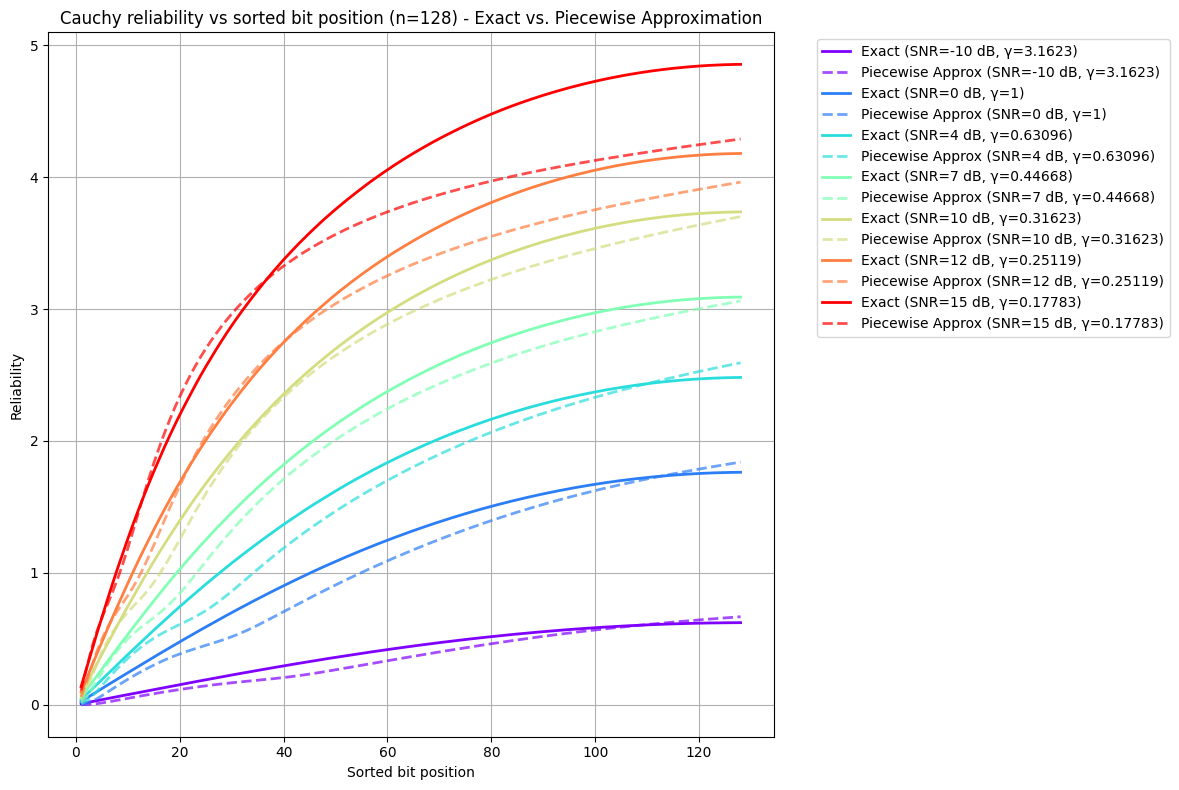

In [ ]:
# =========================================================================
# Per-SNR Comparison: Exact vs Piecewise Reliability Profile
#
# PURPOSE:
#   Same comparison as the overlay cell but produces one separate figure
#   per SNR value.  This makes it easier to judge per-SNR approximation
#   quality without curves from other SNR values cluttering the plot.
#
# NOTE: Helper functions (R_function, R_prime, etc.) are copied inline
#   for cell self-containment — they are identical to prior definitions.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.cm as cm

# --- Helper functions (copied for self-containment within this cell) ---
# The R_function, R_prime, and fixed_piecewise_linear_fit_3_segments are crucial
# for the piecewise approximation and were defined in earlier cells.

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)|."""
    arg1 = gamma**2 + (y + 1)**2
    arg2 = gamma**2 + (y - 1)**2
    return np.abs(np.log(arg1) - np.log(arg2))

def R_prime(y, gamma):
    """Calculates R'(y) for y > 0."""
    term1 = (2 * (y + 1)) / (gamma**2 + (y + 1)**2)
    term2 = (2 * (y - 1)) / (gamma**2 + (y - 1)**2)
    return term1 - term2

def fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1, bp2):
    """
    Performs a three-segment continuous piecewise linear fit for y_data_pos >= 0
    with fixed breakpoints bp1 and bp2.
    """
    A_matrix = np.column_stack([
        y_data_pos,
        np.maximum(0, y_data_pos - bp1),
        np.maximum(0, y_data_pos - bp2)
    ])

    if A_matrix.shape[0] < A_matrix.shape[1] or A_matrix.shape[0] == 0:
        return None

    try:
        if np.linalg.matrix_rank(A_matrix) < A_matrix.shape[1]:
            return None
        coeffs, residuals, rank, s = np.linalg.lstsq(A_matrix, r_data_pos, rcond=None)
    except np.linalg.LinAlgError:
        return None

    yhat_pos = A_matrix @ coeffs
    mse = np.mean((r_data_pos - yhat_pos)**2)

    return {
        "coeffs": coeffs,
        "bp1": bp1,
        "bp2": bp2,
        "mse": mse,
        "yhat_pos": yhat_pos
    }
# --- End of copied helper functions ---

# Access optimal_C_per_gamma from the kernel (assuming it was executed in cell fGmsFAykc6lU)
optimal_C_map = {}
try:
    if 'optimal_C_per_gamma' in globals() and isinstance(optimal_C_per_gamma, list):
        optimal_C_map = {item[0]: item[1] for item in optimal_C_per_gamma}
    else:
        print("Error: 'optimal_C_per_gamma' not found or in unexpected format. Cannot proceed with piecewise approximation.")
except NameError:
    print("Error: 'optimal_C_per_gamma' not defined in the current environment. Please run the cell that generates optimal C values (fGmsFAykc6lU).")

def get_piecewise_fit_params(gamma_val, C_value, y_range_factor=20):
    """
    Retrieves the piecewise linear fit parameters (coeffs, bp1, bp2) for a given gamma_val and C.
    The data range for fitting is consistent with how optimal C was found.
    """
    y_upper_bound = y_range_factor * np.sqrt(1 + gamma_val**2)
    y_full = np.linspace(-y_upper_bound, y_upper_bound, 500)
    r_full_data = R_function(y_full, gamma_val)

    y_data_pos = y_full[y_full >= 0]
    r_data_pos = r_full_data[y_full >= 0]

    bp1_fixed = np.sqrt(1 + gamma_val**2)

    target_slope_bp2 = -C_value / (1 + gamma_val**2)

    def objective_bp2(y):
        return R_prime(y, gamma_val) - target_slope_bp2

    y_check_range_start = bp1_fixed + 0.001
    y_check_range_end = y_upper_bound * 0.9

    if y_check_range_end <= y_check_range_start:
        y_check_range_end = y_check_range_start + 10

    y_check_range = np.linspace(y_check_range_start, y_check_range_end, 100)

    rp_values_check = R_prime(y_check_range, gamma_val)

    current_bp2_fixed = bp1_fixed + 0.001

    if np.any(rp_values_check <= target_slope_bp2) and np.any(rp_values_check >= target_slope_bp2):
        try:
            initial_guess_idx = np.argmin(np.abs(rp_values_check - target_slope_bp2))
            initial_guess_bp2 = y_check_range[initial_guess_idx]
            bp2_found = fsolve(objective_bp2, initial_guess_bp2, maxfev=1000)[0]
            if bp2_found > bp1_fixed + 1e-6 and bp2_found > 0 and bp2_found < y_upper_bound:
                current_bp2_fixed = bp2_found
        except Exception as e:
            pass

    fit_results = fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1_fixed, current_bp2_fixed)

    if fit_results:
        return {
            "coeffs": fit_results["coeffs"],
            "bp1": fit_results["bp1"],
            "bp2": fit_results["bp2"]
        }
    return None

def R_piecewise_approximation(y_values, fit_params):
    """
    Calculates the reliability using the piecewise linear approximation for given y values.
    Handles both positive and negative y values due to symmetry.
    """
    if fit_params is None:
        return np.zeros_like(y_values)

    coeffs = fit_params["coeffs"]
    bp1 = fit_params["bp1"]
    bp2 = fit_params["bp2"]

    c1, c2, c3 = coeffs

    abs_y = np.abs(y_values)

    # The piecewise function is directly applied using the coefficients:
    r_approx = c1 * abs_y + c2 * np.maximum(0, abs_y - bp1) + c3 * np.maximum(0, abs_y - bp2)

    # Clip negative values to ensure reliability is non-negative
    r_approx = np.maximum(0, r_approx)

    return r_approx

def cauchy_reliability_curves_comparison(n=128, Nframes=20000, SNRdB_list=(-10, 0, 4, 7, 10, 12, 15), seed=0):
    rng = np.random.default_rng(seed)

    if not optimal_C_map:
        print("Cannot proceed: optimal_C_map is empty or not initialized. Please ensure previous cells were run correctly.")
        return

    plt.figure(figsize=(12, 8))
    colors = cm.rainbow(np.linspace(0, 1, len(SNRdB_list)))

    for i, snrdb in enumerate(SNRdB_list):
        gamma = 10 ** (-snrdb / 20) # scale parameter
        color = colors[i]

        # Find the closest gamma in our pre-calculated optimal_C_map for breakpoint determination
        closest_gamma_for_C = min(optimal_C_map.keys(), key=lambda x: abs(x - gamma))
        optimal_C_for_this_gamma = optimal_C_map.get(closest_gamma_for_C)

        if optimal_C_for_this_gamma is None:
            print(f"Skipping gamma={gamma:.5g} (SNR={snrdb} dB) as no optimal C found in map.")
            continue

        # Get piecewise fit parameters for the current gamma and its optimal C
        fit_params = get_piecewise_fit_params(gamma, optimal_C_for_this_gamma)

        if fit_params is None:
            print(f"Could not get piecewise fit parameters for gamma={gamma:.5g}. Skipping this SNR.")
            continue

        # bits and BPSK mapping: 0->+1, 1->-1
        x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
        s = 1 - 2 * x_bits

        # Cauchy noise: gamma * tan(pi*(U-0.5))
        U = rng.random(size=(n, Nframes))
        z = gamma * np.tan(np.pi * (U - 0.5))
        r = s + z # Received signal

        # --- Exact Cauchy Reliability (magnitude of LLR) ---
        Gamma_exact = R_function(r, gamma)
        Gamma_sorted_exact = np.sort(Gamma_exact, axis=0)
        Gamma_mean_exact = Gamma_sorted_exact.mean(axis=1)

        # --- Piecewise Approximation of Reliability (magnitude of LLR) ---
        Gamma_piecewise = R_piecewise_approximation(r, fit_params)
        Gamma_sorted_piecewise = np.sort(Gamma_piecewise, axis=0)
        Gamma_mean_piecewise = Gamma_sorted_piecewise.mean(axis=1)

        # Plotting for comparison
        plt.plot(np.arange(1, n+1), Gamma_mean_exact, linewidth=2,
                 label=f"Exact (SNR={snrdb} dB, γ={gamma:.5g})", color=color)
        plt.plot(np.arange(1, n+1), Gamma_mean_piecewise, '--', linewidth=2,
                 label=f"Piecewise Approx (SNR={snrdb} dB, γ={gamma:.5g})", color=color, alpha=0.7)

    plt.xlabel("Sorted bit position")
    plt.ylabel("Reliability")
    plt.title(f"Cauchy reliability vs sorted bit position (n={n}) - Exact vs. Piecewise Approximation")
    plt.grid(True)
    plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

# Call the comparison function to generate the plots
cauchy_reliability_curves_comparison()

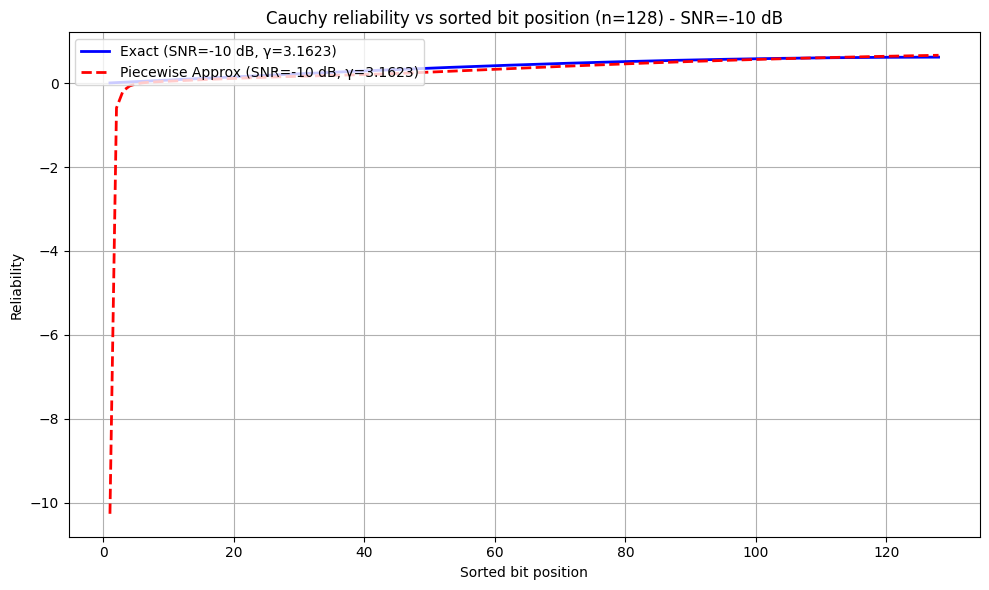

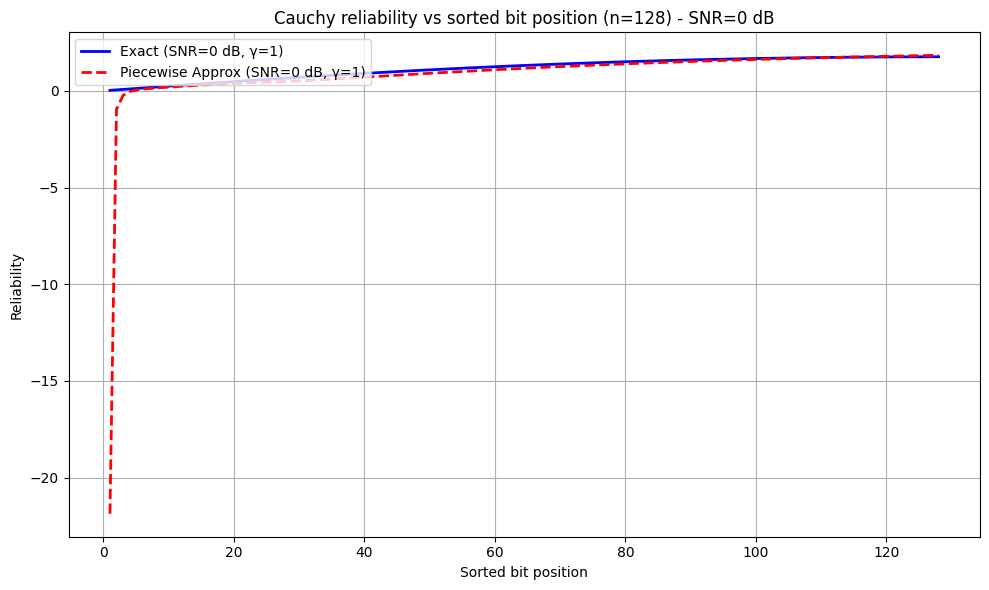

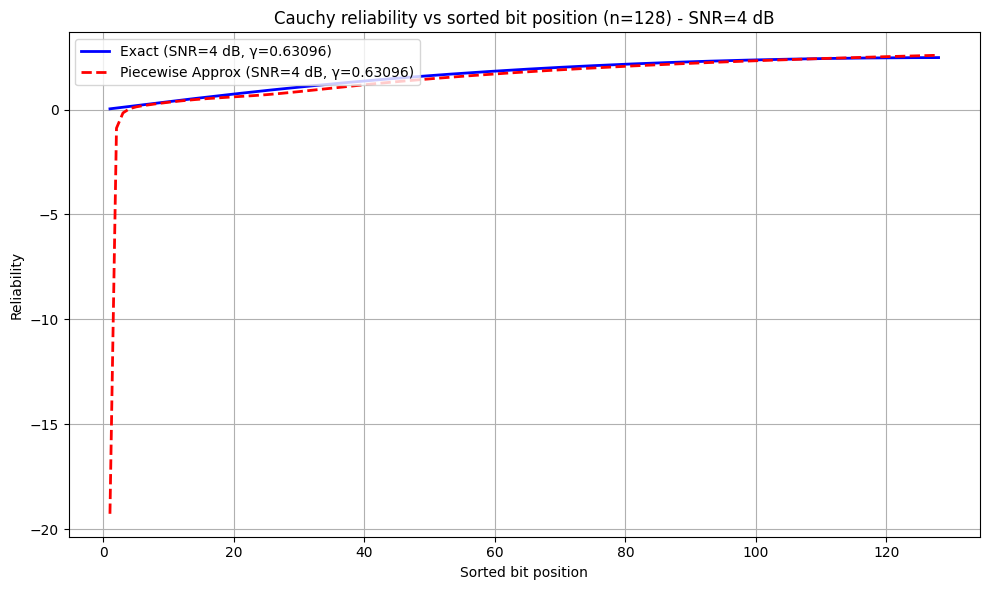

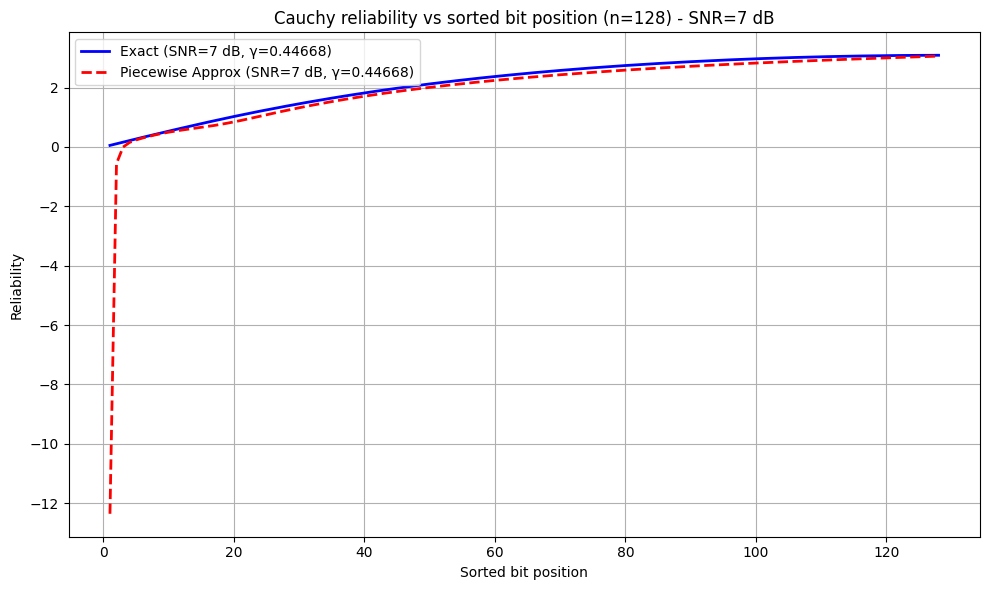

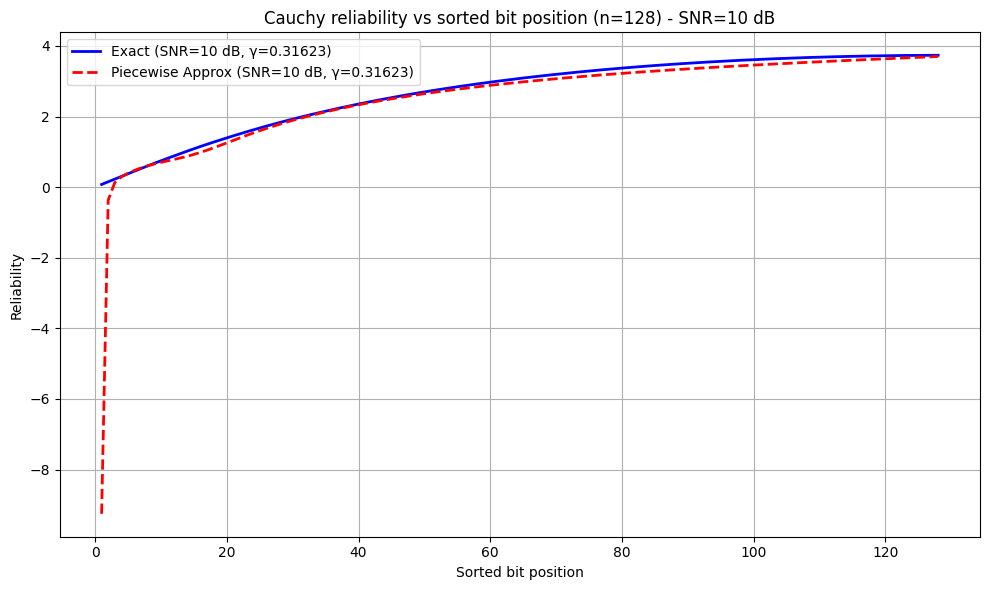

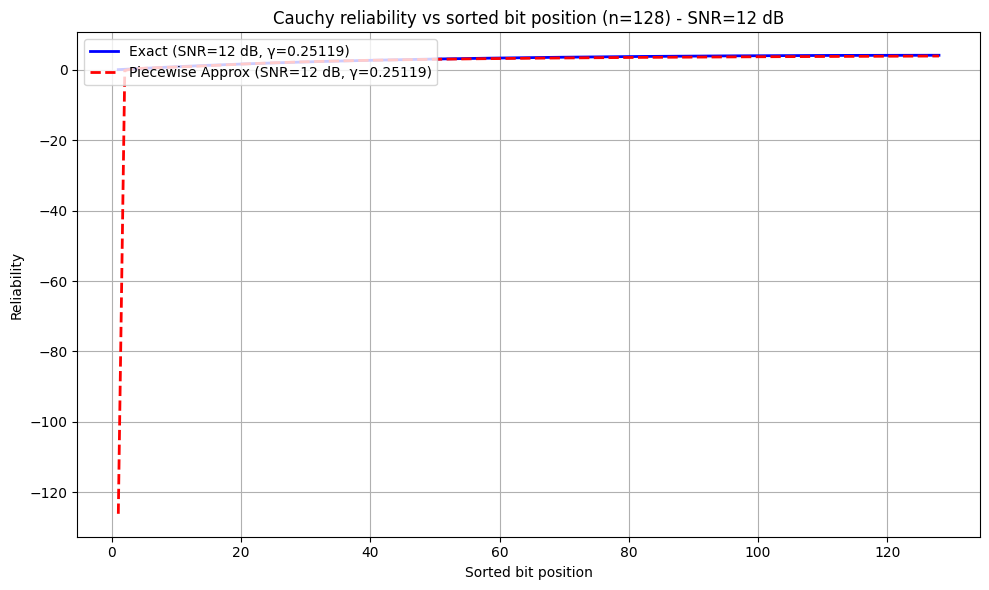

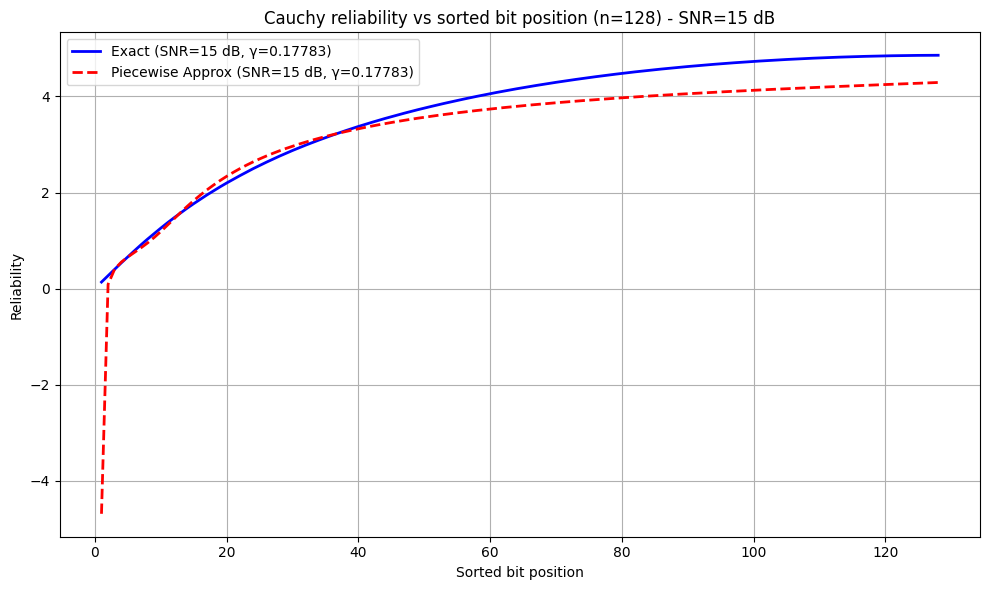

In [ ]:
# =========================================================================
# Per-SNR Comparison: Exact vs Piecewise Reliability Profile
#
# PURPOSE:
#   Same comparison as the overlay cell but produces one separate figure
#   per SNR value.  This makes it easier to judge per-SNR approximation
#   quality without curves from other SNR values cluttering the plot.
#
# NOTE: Helper functions (R_function, R_prime, etc.) are copied inline
#   for cell self-containment — they are identical to prior definitions.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- Helper functions (copied for self-containment within this cell) ---
# The R_function, R_prime, and fixed_piecewise_linear_fit_3_segments are crucial
# for the piecewise approximation and were defined in earlier cells.

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)|."""
    arg1 = gamma**2 + (y + 1)**2
    arg2 = gamma**2 + (y - 1)**2
    return np.abs(np.log(arg1) - np.log(arg2))

def R_prime(y, gamma):
    """Calculates R'(y) for y > 0."""
    term1 = (2 * (y + 1)) / (gamma**2 + (y + 1)**2)
    term2 = (2 * (y - 1)) / (gamma**2 + (y - 1)**2)
    return term1 - term2

def fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1, bp2):
    """
    Performs a three-segment continuous piecewise linear fit for y_data_pos >= 0
    with fixed breakpoints bp1 and bp2.
    """
    A_matrix = np.column_stack([
        y_data_pos,
        np.maximum(0, y_data_pos - bp1),
        np.maximum(0, y_data_pos - bp2)
    ])

    if A_matrix.shape[0] < A_matrix.shape[1] or A_matrix.shape[0] == 0:
        return None

    try:
        if np.linalg.matrix_rank(A_matrix) < A_matrix.shape[1]:
            return None
        coeffs, residuals, rank, s = np.linalg.lstsq(A_matrix, r_data_pos, rcond=None)
    except np.linalg.LinAlgError:
        return None

    yhat_pos = A_matrix @ coeffs
    mse = np.mean((r_data_pos - yhat_pos)**2)

    return {
        "coeffs": coeffs,
        "bp1": bp1,
        "bp2": bp2,
        "mse": mse,
        "yhat_pos": yhat_pos
    }
# --- End of copied helper functions ---

# Access optimal_C_per_gamma from the kernel (assuming it was executed in cell fGmsFAykc6lU)
optimal_C_map = {}
try:
    if 'optimal_C_per_gamma' in globals() and isinstance(optimal_C_per_gamma, list):
        optimal_C_map = {item[0]: item[1] for item in optimal_C_per_gamma}
    else:
        print("Error: 'optimal_C_per_gamma' not found or in unexpected format. Cannot proceed with piecewise approximation.")
except NameError:
    print("Error: 'optimal_C_per_gamma' not defined in the current environment. Please run the cell that generates optimal C values (fGmsFAykc6lU).")

def get_piecewise_fit_params(gamma_val, C_value, y_range_factor=20):
    """
    Retrieves the piecewise linear fit parameters (coeffs, bp1, bp2) for a given gamma_val and C.
    The data range for fitting is consistent with how optimal C was found.
    """
    y_upper_bound = y_range_factor * np.sqrt(1 + gamma_val**2)
    y_full = np.linspace(-y_upper_bound, y_upper_bound, 500)
    r_full_data = R_function(y_full, gamma_val)

    y_data_pos = y_full[y_full >= 0]
    r_data_pos = r_full_data[y_full >= 0]

    bp1_fixed = np.sqrt(1 + gamma_val**2)

    target_slope_bp2 = -C_value / (1 + gamma_val**2)

    def objective_bp2(y):
        return R_prime(y, gamma_val) - target_slope_bp2

    y_check_range_start = bp1_fixed + 0.001
    y_check_range_end = y_upper_bound * 0.9

    if y_check_range_end <= y_check_range_start:
        y_check_range_end = y_check_range_start + 10

    y_check_range = np.linspace(y_check_range_start, y_check_range_end, 100)

    rp_values_check = R_prime(y_check_range, gamma_val)

    current_bp2_fixed = bp1_fixed + 0.001

    if np.any(rp_values_check <= target_slope_bp2) and np.any(rp_values_check >= target_slope_bp2):
        try:
            initial_guess_idx = np.argmin(np.abs(rp_values_check - target_slope_bp2))
            initial_guess_bp2 = y_check_range[initial_guess_idx]
            bp2_found = fsolve(objective_bp2, initial_guess_bp2, maxfev=1000)[0]
            if bp2_found > bp1_fixed + 1e-6 and bp2_found > 0 and bp2_found < y_upper_bound:
                current_bp2_fixed = bp2_found
        except Exception as e:
            pass

    fit_results = fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1_fixed, current_bp2_fixed)

    if fit_results:
        return {
            "coeffs": fit_results["coeffs"],
            "bp1": fit_results["bp1"],
            "bp2": fit_results["bp2"]
        }
    return None

def R_piecewise_approximation(y_values, fit_params):
    """
    Calculates the reliability using the piecewise linear approximation for given y values.
    Handles both positive and negative y values due to symmetry.
    """
    if fit_params is None:
        return np.zeros_like(y_values)

    coeffs = fit_params["coeffs"]
    bp1 = fit_params["bp1"]
    bp2 = fit_params["bp2"]

    c1, c2, c3 = coeffs

    abs_y = np.abs(y_values)

    # The piecewise function is directly applied using the coefficients:
    r_approx = c1 * abs_y + c2 * np.maximum(0, abs_y - bp1) + c3 * np.maximum(0, abs_y - bp2)

    return r_approx

def cauchy_reliability_curves_comparison(n=128, Nframes=20000, SNRdB_list=(-10, 0, 4, 7, 10, 12, 15), seed=0):
    rng = np.random.default_rng(seed)

    if not optimal_C_map:
        print("Cannot proceed: optimal_C_map is empty or not initialized. Please ensure previous cells were run correctly.")
        return

    for snrdb in SNRdB_list:
        gamma = 10 ** (-snrdb / 20) # scale parameter

        # Find the closest gamma in our pre-calculated optimal_C_map for breakpoint determination
        closest_gamma_for_C = min(optimal_C_map.keys(), key=lambda x: abs(x - gamma))
        optimal_C_for_this_gamma = optimal_C_map.get(closest_gamma_for_C)

        if optimal_C_for_this_gamma is None:
            print(f"Skipping gamma={gamma:.5g} (SNR={snrdb} dB) as no optimal C found in map.")
            continue

        # Get piecewise fit parameters for the current gamma and its optimal C
        fit_params = get_piecewise_fit_params(gamma, optimal_C_for_this_gamma)

        if fit_params is None:
            print(f"Could not get piecewise fit parameters for gamma={gamma:.5g}. Skipping this SNR.")
            continue

        # bits and BPSK mapping: 0->+1, 1->-1
        x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
        s = 1 - 2 * x_bits

        # Cauchy noise: gamma * tan(pi*(U-0.5))
        U = rng.random(size=(n, Nframes))
        z = gamma * np.tan(np.pi * (U - 0.5))
        r = s + z # Received signal

        # --- Exact Cauchy Reliability (magnitude of LLR) ---
        # The R_function is defined to return `abs(LLR)` directly when given `r`.
        Gamma_exact = R_function(r, gamma)

        # Sort per trial (each column), average across trials for exact curve
        Gamma_sorted_exact = np.sort(Gamma_exact, axis=0)
        Gamma_mean_exact = Gamma_sorted_exact.mean(axis=1)

        # --- Piecewise Approximation of Reliability (magnitude of LLR) ---
        # Apply the piecewise approximation to the received signal 'r' to get approximated `abs(LLR)`.
        Gamma_piecewise = R_piecewise_approximation(r, fit_params)

        # Sort per trial (each column), average across trials for piecewise curve
        Gamma_sorted_piecewise = np.sort(Gamma_piecewise, axis=0)
        Gamma_mean_piecewise = Gamma_sorted_piecewise.mean(axis=1)

        # Plotting for comparison
        plt.figure(figsize=(10, 6))
        plt.plot(np.arange(1, n+1), Gamma_mean_exact, linewidth=2,
                 label=f"Exact (SNR={snrdb} dB, γ={gamma:.5g})", color='blue')
        plt.plot(np.arange(1, n+1), Gamma_mean_piecewise, '--', linewidth=2,
                 label=f"Piecewise Approx (SNR={snrdb} dB, γ={gamma:.5g})", color='red')

        plt.xlabel("Sorted bit position")
        plt.ylabel("Reliability")
        plt.title(f"Cauchy reliability vs sorted bit position (n={n}) - SNR={snrdb} dB")
        plt.grid(True)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

# Call the comparison function to generate the plots
cauchy_reliability_curves_comparison()

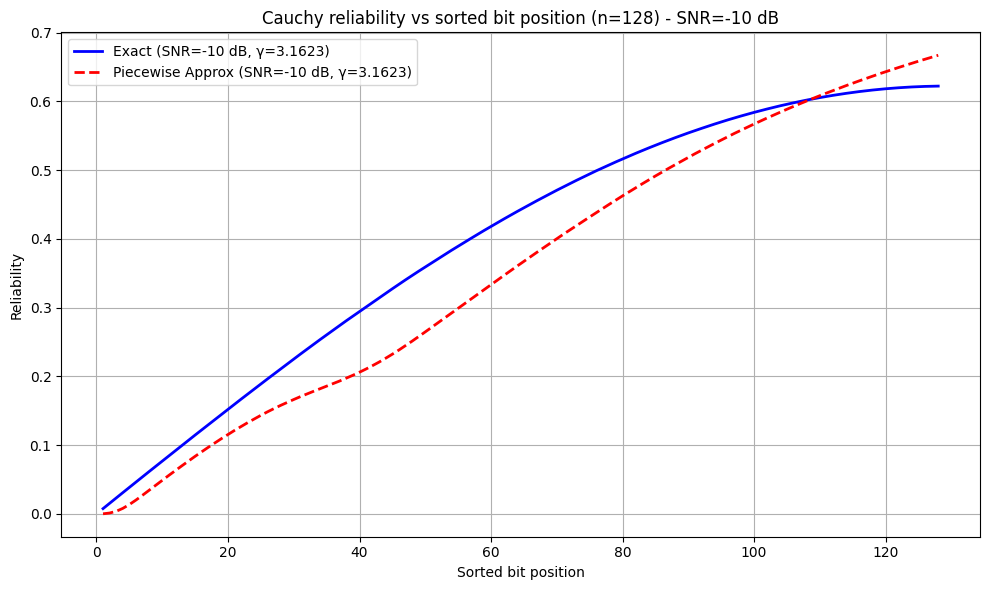

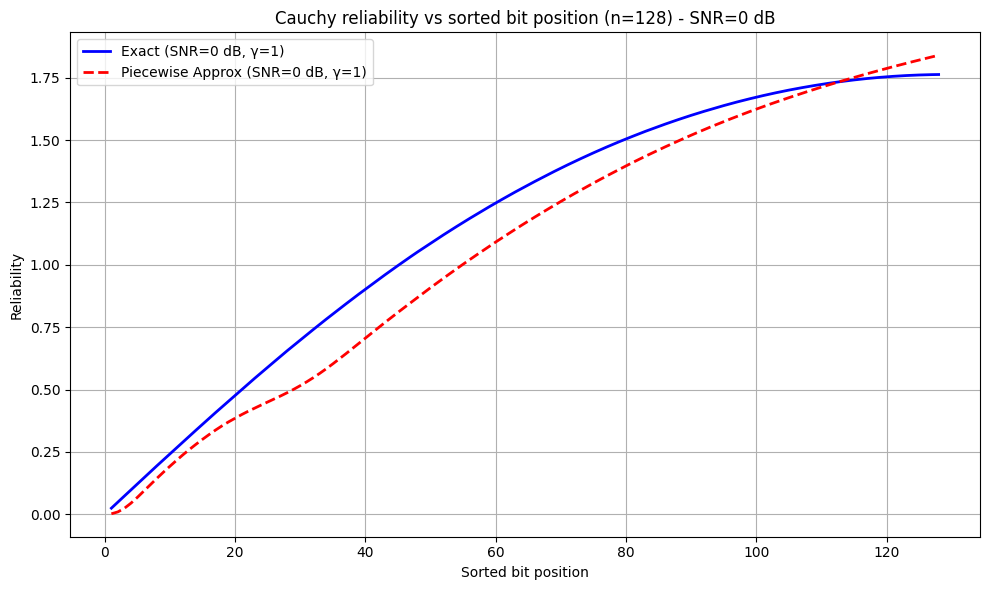

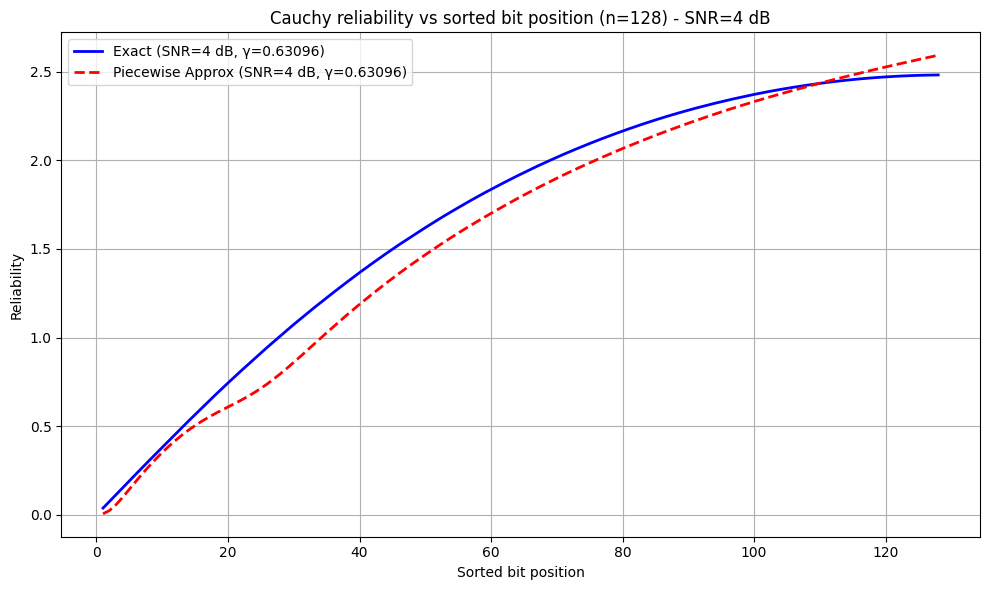

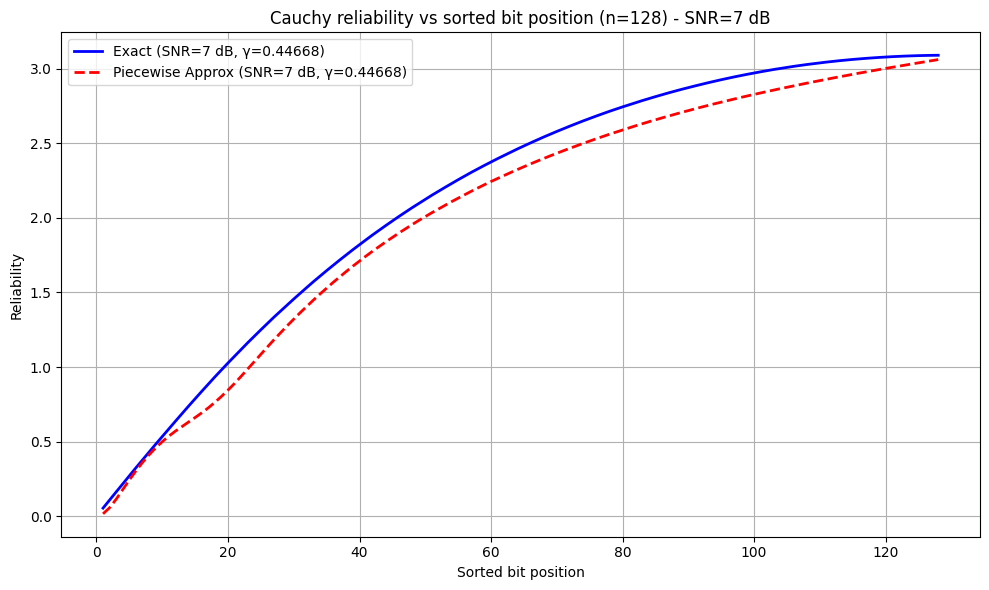

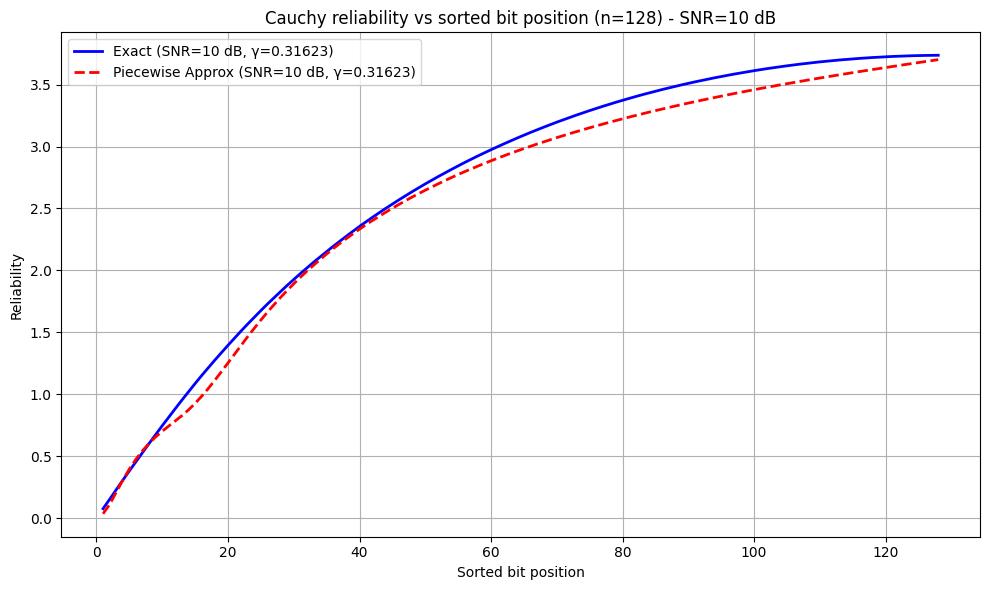

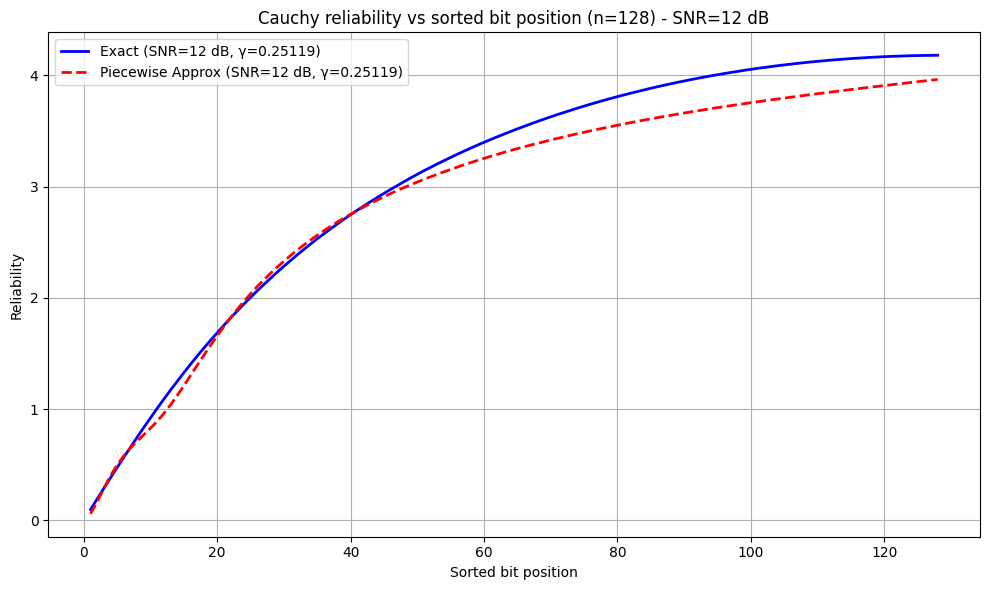

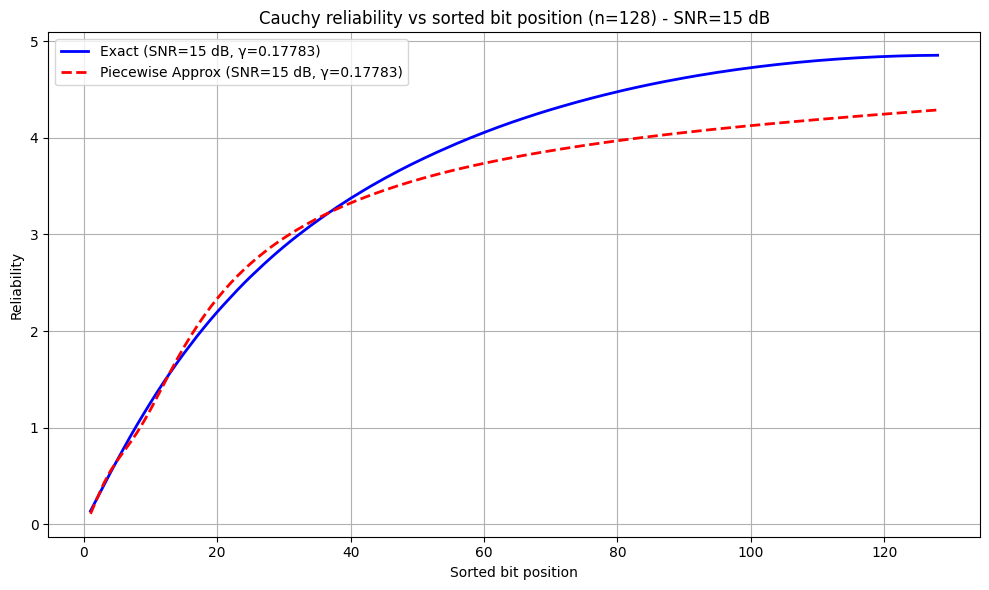

In [ ]:
# =========================================================================
# Per-SNR Comparison: Exact vs Piecewise Reliability Profile
#
# PURPOSE:
#   Same comparison as the overlay cell but produces one separate figure
#   per SNR value.  This makes it easier to judge per-SNR approximation
#   quality without curves from other SNR values cluttering the plot.
#
# NOTE: Helper functions (R_function, R_prime, etc.) are copied inline
#   for cell self-containment — they are identical to prior definitions.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- Helper functions (copied for self-containment within this cell) ---
# These functions are essential for calculating exact and piecewise reliability.

def R_function(y, gamma):
    """Calculates R(y) = |log(gamma**2 + (y+1)**2) - log(gamma**2 + (y-1)**2)|."""
    arg1 = gamma**2 + (y + 1)**2
    arg2 = gamma**2 + (y - 1)**2
    return np.abs(np.log(arg1) - np.log(arg2))

def R_prime(y, gamma):
    """Calculates R'(y) for y > 0."""
    term1 = (2 * (y + 1)) / (gamma**2 + (y + 1)**2)
    term2 = (2 * (y - 1)) / (gamma**2 + (y - 1)**2)
    return term1 - term2

def fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1, bp2):
    """
    Performs a three-segment continuous piecewise linear fit for y_data_pos >= 0
    with fixed breakpoints bp1 and bp2.
    """
    A_matrix = np.column_stack([
        y_data_pos,
        np.maximum(0, y_data_pos - bp1),
        np.maximum(0, y_data_pos - bp2)
    ])

    if A_matrix.shape[0] < A_matrix.shape[1] or A_matrix.shape[0] == 0:
        return None

    try:
        if np.linalg.matrix_rank(A_matrix) < A_matrix.shape[1]:
            return None
        coeffs, residuals, rank, s = np.linalg.lstsq(A_matrix, r_data_pos, rcond=None)
    except np.linalg.LinAlgError:
        return None

    yhat_pos = A_matrix @ coeffs
    mse = np.mean((r_data_pos - yhat_pos)**2)

    return {
        "coeffs": coeffs,
        "bp1": bp1,
        "bp2": bp2,
        "mse": mse,
        "yhat_pos": yhat_pos
    }
# --- End of copied helper functions ---

# Access optimal_C_per_gamma from the kernel (assuming it was executed in cell fGmsFAykc6lU)
optimal_C_map = {}
try:
    if 'optimal_C_per_gamma' in globals() and isinstance(optimal_C_per_gamma, list):
        optimal_C_map = {item[0]: item[1] for item in optimal_C_per_gamma}
    else:
        print("Error: 'optimal_C_per_gamma' not found or in unexpected format. Cannot proceed with piecewise approximation.")
except NameError:
    print("Error: 'optimal_C_per_gamma' not defined in the current environment. Please run the cell that generates optimal C values (fGmsFAykc6lU).")

def get_piecewise_fit_params(gamma_val, C_value, y_range_factor=20):
    """
    Retrieves the piecewise linear fit parameters (coeffs, bp1, bp2) for a given gamma_val and C.
    The data range for fitting is consistent with how optimal C was found.
    """
    y_upper_bound = y_range_factor * np.sqrt(1 + gamma_val**2)
    y_full = np.linspace(-y_upper_bound, y_upper_bound, 500)
    r_full_data = R_function(y_full, gamma_val)

    y_data_pos = y_full[y_full >= 0]
    r_data_pos = r_full_data[y_full >= 0]

    bp1_fixed = np.sqrt(1 + gamma_val**2)

    target_slope_bp2 = -C_value / (1 + gamma_val**2)

    def objective_bp2(y):
        return R_prime(y, gamma_val) - target_slope_bp2

    y_check_range_start = bp1_fixed + 0.001
    y_check_range_end = y_upper_bound * 0.9

    if y_check_range_end <= y_check_range_start:
        y_check_range_end = y_check_range_start + 10

    y_check_range = np.linspace(y_check_range_start, y_check_range_end, 100)

    rp_values_check = R_prime(y_check_range, gamma_val)

    current_bp2_fixed = bp1_fixed + 0.001

    if np.any(rp_values_check <= target_slope_bp2) and np.any(rp_values_check >= target_slope_bp2):
        try:
            initial_guess_idx = np.argmin(np.abs(rp_values_check - target_slope_bp2))
            initial_guess_bp2 = y_check_range[initial_guess_idx]
            bp2_found = fsolve(objective_bp2, initial_guess_bp2, maxfev=1000)[0]
            if bp2_found > bp1_fixed + 1e-6 and bp2_found > 0 and bp2_found < y_upper_bound:
                current_bp2_fixed = bp2_found
        except Exception as e:
            pass

    fit_results = fixed_piecewise_linear_fit_3_segments(y_data_pos, r_data_pos, bp1_fixed, current_bp2_fixed)

    if fit_results:
        return {
            "coeffs": fit_results["coeffs"],
            "bp1": fit_results["bp1"],
            "bp2": fit_results["bp2"]
        }
    return None

def R_piecewise_approximation(y_values, fit_params):
    """
    Calculates the reliability using the piecewise linear approximation for given y values.
    Handles both positive and negative y values due to symmetry.
    """
    if fit_params is None:
        return np.zeros_like(y_values)

    coeffs = fit_params["coeffs"]
    bp1 = fit_params["bp1"]
    bp2 = fit_params["bp2"]

    c1, c2, c3 = coeffs

    abs_y = np.abs(y_values)

    # The piecewise function is directly applied using the coefficients:
    r_approx = c1 * abs_y + c2 * np.maximum(0, abs_y - bp1) + c3 * np.maximum(0, abs_y - bp2)

    # Clip negative values to ensure reliability is non-negative
    r_approx = np.maximum(0, r_approx)

    return r_approx

def cauchy_reliability_curves_comparison(n=128, Nframes=20000, SNRdB_list=(-10, 0, 4, 7, 10, 12, 15), seed=0):
    rng = np.random.default_rng(seed)

    if not optimal_C_map:
        print("Cannot proceed: optimal_C_map is empty or not initialized. Please ensure previous cells were run correctly.")
        return

    for snrdb in SNRdB_list:
        gamma = 10 ** (-snrdb / 20) # scale parameter

        # Find the closest gamma in our pre-calculated optimal_C_map for breakpoint determination
        closest_gamma_for_C = min(optimal_C_map.keys(), key=lambda x: abs(x - gamma))
        optimal_C_for_this_gamma = optimal_C_map.get(closest_gamma_for_C)

        if optimal_C_for_this_gamma is None:
            print(f"Skipping gamma={gamma:.5g} (SNR={snrdb} dB) as no optimal C found in map.")
            continue

        # Get piecewise fit parameters for the current gamma and its optimal C
        fit_params = get_piecewise_fit_params(gamma, optimal_C_for_this_gamma)

        if fit_params is None:
            print(f"Could not get piecewise fit parameters for gamma={gamma:.5g}. Skipping this SNR.")
            continue

        # bits and BPSK mapping: 0->+1, 1->-1
        x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
        s = 1 - 2 * x_bits

        # Cauchy noise: gamma * tan(pi*(U-0.5))
        U = rng.random(size=(n, Nframes))
        z = gamma * np.tan(np.pi * (U - 0.5))
        r = s + z # Received signal

        # --- Exact Cauchy Reliability (magnitude of LLR) ---
        # The R_function is defined to return `abs(LLR)` directly when given `r`.
        Gamma_exact = R_function(r, gamma)

        # Sort per trial (each column), average across trials for exact curve
        Gamma_sorted_exact = np.sort(Gamma_exact, axis=0)
        Gamma_mean_exact = Gamma_sorted_exact.mean(axis=1)

        # --- Piecewise Approximation of Reliability (magnitude of LLR) ---
        # Apply the piecewise approximation to the received signal 'r' to get approximated `abs(LLR)`.
        Gamma_piecewise = R_piecewise_approximation(r, fit_params)

        # Sort per trial (each column), average across trials for piecewise curve
        Gamma_sorted_piecewise = np.sort(Gamma_piecewise, axis=0)
        Gamma_mean_piecewise = Gamma_sorted_piecewise.mean(axis=1)

        # Plotting for comparison
        plt.figure(figsize=(10, 6))
        plt.plot(np.arange(1, n+1), Gamma_mean_exact, linewidth=2,
                 label=f"Exact (SNR={snrdb} dB, γ={gamma:.5g})", color='blue')
        plt.plot(np.arange(1, n+1), Gamma_mean_piecewise, '--', linewidth=2,
                 label=f"Piecewise Approx (SNR={snrdb} dB, γ={gamma:.5g})", color='red')

        plt.xlabel("Sorted bit position")
        plt.ylabel("Reliability")
        plt.title(f"Cauchy reliability vs sorted bit position (n={n}) - SNR={snrdb} dB")
        plt.grid(True)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

# Call the comparison function to generate the plots
cauchy_reliability_curves_comparison()

#LaPlace LLR

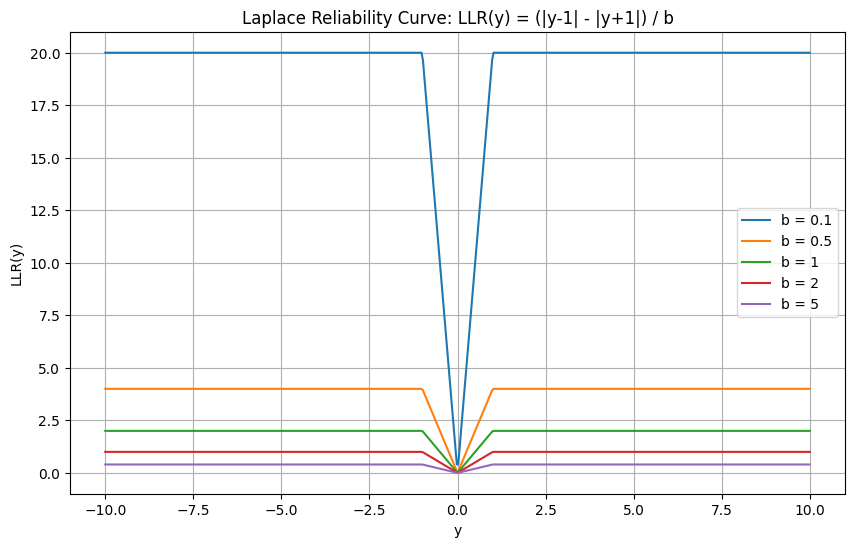

In [ ]:
# =========================================================================
# Laplacian LLR Reliability Curve
#
# PURPOSE:
#   Plots |LLR(y)| for the Laplace (double-exponential) noise model as a
#   function of received signal y, for comparison with the Cauchy curve.
#
# LAPLACIAN LLR FOR BPSK:
#   Under Laplacian noise with scale b, the LLR is piecewise linear:
#     LLR(y) = (|y-1| - |y+1|) / b
#   This is piece-linear with a kink at y=0 and saturation for |y|>1:
#     |y| > 1:  |LLR| = 2/b  (constant — strongly decided region)
#     |y| < 1:  |LLR| = 2*|y|/b  (linearly rising)
#
# KEY CONTRAST WITH CAUCHY:
#   The Laplacian LLR saturates to a constant 2/b for |y| > 1, meaning
#   large received values are maximally reliable.  By contrast, the Cauchy
#   LLR decreases for large |y| — large values are unreliable under
#   Cauchy noise because they may be outliers.  This fundamental difference
#   motivates using noise-matched LLRs in ORBGRAND.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def laplace_llr_function(y, b):
    """Calculates LLR(y) = (|y-1| - |y+1|) / b for Laplace distribution."""
    return np.abs((np.abs(y - 1) - np.abs(y + 1)) / b)

# Define different 'b' values to plot
b_values = [0.1, 0.5, 1, 2, 5]

# Define a range for y values. The LLR function changes behavior around -1 and 1.
y_values = np.linspace(-10, 10, 500)

plt.figure(figsize=(10, 6))

for b_val in b_values:
    # Calculate LLR(y) values for the current 'b'
    llr_values = laplace_llr_function(y_values, b_val)
    plt.plot(y_values, llr_values, label=f'b = {b_val}')

plt.xlabel('y')
plt.ylabel('LLR(y)')
plt.title('Laplace Reliability Curve: LLR(y) = (|y-1| - |y+1|) / b')
plt.grid(True)
plt.legend()
plt.show()